## HIPERPARAMETROS

In [1]:
# -*- coding: utf-8 -*-
"""
HPO — TinyMLP (TF/Keras) + Proxy de tamanho (n_params) + Top-K conversão TFLite

- Objetivo do HPO: minimizar RMSE (val), respeitando budget de parâmetros (proxy de tamanho).
- Pós-HPO: pega Top-K (melhores RMSE dentro do budget) e converte para TFLite:
    (1) float32 (baseline)
    (2) int8 PTQ (para Arduino)
  medindo bytes do arquivo .tflite.
- Gera relatórios CSV com: RMSE, MAE, Tamanho_Modelo(bytes), N_Parametros.

Compatível com a ideia: baseline quant-friendly, depois quantização, poda e KD.
"""

import os
import json
import time
import random
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

import optuna
from optuna.pruners import MedianPruner

import tensorflow as tf

# =========================
# CONFIG
# =========================
CSV_PATH = "/home/clariele/Desktop/mestrado/Qualificacao/Códigos Mestrado/dev_consciencia/bd_EstacaoVargemFria_e_Pesca.csv"
STATION_NAME = "Estação Pesca - UFRPE"
TIME_COL = "Data estação"

CTX = 7

MAX_EPOCHS = 100
PATIENCE = 15
VAL_TAIL_FRAC = 0.10
SEED = 42

# Proxy de “tamanho” durante HPO (conservador para Arduino)
MAX_PARAMS_BUDGET = 12000

N_TRIALS = 80
TOP_K = 12

OUT_DIR = "hpo_tinymlp_tflite_out"
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# UTIL
# =========================
def set_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def load_dataframe():
    df = pd.read_csv(CSV_PATH, on_bad_lines="skip")
    df = df[df["Nome"].astype(str).str.strip() == STATION_NAME].copy()
    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
    df = df.dropna(subset=[TIME_COL])

    cols = ["Temperatura", "Umidade", "Velocidade Vento", "Rajada Vento", "Precipitação dia"]
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.sort_values(TIME_COL)
    df = df.infer_objects(copy=False).interpolate().dropna().reset_index(drop=True)
    return df

def build_sequences(df):
    cols_X = ["Temperatura", "Umidade", "Velocidade Vento", "Rajada Vento", "Precipitação dia"]
    arr = df[cols_X].values.astype(np.float32)
    y_all = df["Precipitação dia"].values.astype(np.float32)

    X_list, y_list = [], []
    for t in range(CTX, len(df)):
        # Mantém (CTX, F) para ficar compatível com o pipeline,
        # mas o MLP vai achatar internamente depois.
        X_list.append(arr[t-CTX:t, :])
        y_list.append(y_all[t])

    X = np.stack(X_list).astype(np.float32)      # (N, CTX, F)
    y = np.array(y_list).astype(np.float32)      # (N,)
    return X, y

def split_tail(X, y, val_tail_frac=0.10):
    n = len(X)
    val_tail = int(n * val_tail_frac)
    Xtr, Xval = X[:-val_tail], X[-val_tail:]
    ytr, yval = y[:-val_tail], y[-val_tail:]
    return Xtr, ytr, Xval, yval

def scale_X_train_val(Xtr, Xval):
    """
    Normaliza com StandardScaler aplicado no vetor achatado.
    Depois faz reshape de volta para (CTX, F) apenas para manter compatibilidade
    com o restante do pipeline. O Flatten do modelo cuida do resto.

    No Arduino: você exporta mean/std e aplica antes da inferência.
    """
    scaler = StandardScaler()
    Xtr2 = scaler.fit_transform(Xtr.reshape(len(Xtr), -1)).reshape(Xtr.shape)
    Xval2 = scaler.transform(Xval.reshape(len(Xval), -1)).reshape(Xval.shape)
    return Xtr2.astype(np.float32), Xval2.astype(np.float32), scaler

def rmse_mae(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
    mae = float(np.mean(np.abs(y_pred - y_true)))
    return rmse, mae

# =========================
# MODELO (quant-friendly)
# =========================
def build_tinymlp(
    input_shape,
    units1: int,
    units2: int,
    n_hidden: int,
    l2_weight: float
):
    """
    Baseline quant-friendly:
    Flatten -> Dense -> ReLU -> [Dense -> ReLU] opcional -> Dense(1)

    Sem BatchNorm, sem Dropout, sem ativações exóticas:
    isso facilita quantização e deployment em MCU.
    """
    reg = tf.keras.regularizers.l2(l2_weight) if l2_weight > 0 else None

    inp = tf.keras.Input(shape=input_shape, name="x")
    x = tf.keras.layers.Flatten(name="flatten")(inp)

    x = tf.keras.layers.Dense(
        units1,
        use_bias=True,
        kernel_regularizer=reg,
        name="dense1"
    )(x)
    x = tf.keras.layers.ReLU(name="relu1")(x)

    if n_hidden == 2:
        x = tf.keras.layers.Dense(
            units2,
            use_bias=True,
            kernel_regularizer=reg,
            name="dense2"
        )(x)
        x = tf.keras.layers.ReLU(name="relu2")(x)

    out = tf.keras.layers.Dense(1, name="y")(x)

    model = tf.keras.Model(inp, out, name="TinyMLP")
    return model

def compile_model(model, lr: float, weight_decay: float):
    # TF 2.18 tem AdamW; se não tiver, cai para Adam
    try:
        opt = tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=weight_decay)
    except Exception:
        opt = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=opt,
        loss="mse",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model

def train_and_eval_once(
    Xtr, ytr, Xval, yval,
    units1: int, units2: int, n_hidden: int,
    batch_size: int, lr: float, weight_decay: float, l2_weight: float,
    seed: int
):
    set_seeds(seed)

    model = build_tinymlp(
        input_shape=Xtr.shape[1:],
        units1=units1,
        units2=units2,
        n_hidden=n_hidden,
        l2_weight=l2_weight
    )

    n_params = int(model.count_params())
    model = compile_model(model, lr=lr, weight_decay=weight_decay)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=0,
        ),
    ]

    model.fit(
        Xtr, ytr,
        validation_data=(Xval, yval),
        epochs=MAX_EPOCHS,
        batch_size=batch_size,
        shuffle=False,  # time series: manter ordem
        verbose=0,
        callbacks=callbacks,
    )

    preds = model.predict(Xval, batch_size=batch_size, verbose=0).reshape(-1)
    rmse, mae = rmse_mae(yval, preds)
    return model, rmse, mae, n_params

# =========================
# PREP (uma vez)
# =========================
_df = load_dataframe()
_X, _y = build_sequences(_df)
_Xtr, _ytr, _Xval, _yval = split_tail(_X, _y, VAL_TAIL_FRAC)
_Xtr_s, _Xval_s, _scaler = scale_X_train_val(_Xtr, _Xval)

# Salva scaler (mean/std) para uso futuro no Arduino/Raspberry
scaler_info = {
    "mean": _scaler.mean_.tolist(),
    "scale": _scaler.scale_.tolist(),
    "var": _scaler.var_.tolist(),
    "n_features_in": int(getattr(_scaler, "n_features_in_", _Xtr_s.reshape(len(_Xtr_s), -1).shape[1])),
    "ctx": CTX,
    "n_input_features_total": int(_Xtr_s.reshape(len(_Xtr_s), -1).shape[1]),
}
with open(os.path.join(OUT_DIR, "scaler_standard.json"), "w") as f:
    json.dump(scaler_info, f, indent=2)

# =========================
# HPO (Optuna)
# =========================
def objective(trial: optuna.Trial):
    seed = SEED + trial.number

    # Search space enxuto e compatível com MCU
    n_hidden = trial.suggest_categorical("n_hidden", [1, 2])
    units1 = trial.suggest_categorical("units1", [8, 16, 24, 32, 48, 64])

    if n_hidden == 1:
        units2 = 0
    else:
        units2 = trial.suggest_categorical("units2", [4, 8, 16, 24, 32])

    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-7, 1e-4, log=True)

    use_l2 = trial.suggest_categorical("use_l2", [0, 1])
    if use_l2 == 0:
        l2_weight = 0.0
    else:
        l2_weight = trial.suggest_float("l2_weight", 1e-8, 1e-4, log=True)

    model, rmse, mae, n_params = train_and_eval_once(
        _Xtr_s, _ytr, _Xval_s, _yval,
        units1=units1,
        units2=units2,
        n_hidden=n_hidden,
        batch_size=batch_size,
        lr=lr,
        weight_decay=weight_decay,
        l2_weight=l2_weight,
        seed=seed,
    )

    # log attrs sempre
    trial.set_user_attr("rmse", rmse)
    trial.set_user_attr("mae", mae)
    trial.set_user_attr("n_params", n_params)

    # filtro por budget
    if n_params > MAX_PARAMS_BUDGET:
        raise optuna.TrialPruned(f"Excedeu budget params: {n_params} > {MAX_PARAMS_BUDGET}")

    return rmse

def run_hpo():
    study = optuna.create_study(
        direction="minimize",
        pruner=MedianPruner(n_startup_trials=10),
    )
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    with open(os.path.join(OUT_DIR, "optuna_best_params.json"), "w") as f:
        json.dump(
            {"best_rmse": float(study.best_value), "best_params": study.best_params},
            f,
            indent=2,
        )

    rows = []
    for t in study.trials:
        if t.state.name not in ("COMPLETE", "PRUNED"):
            continue
        row = {
            "trial_number": t.number,
            "state": t.state.name,
            "value_rmse_objective": t.value if t.value is not None else np.nan,
        }
        row.update(t.params)
        row["rmse"] = t.user_attrs.get("rmse", np.nan)
        row["mae"] = t.user_attrs.get("mae", np.nan)
        row["n_params"] = t.user_attrs.get("n_params", np.nan)
        rows.append(row)

    df_trials = pd.DataFrame(rows)

    # Ordenação estável: COMPLETE antes, depois PRUNED; rmse crescente
    state_rank = {"COMPLETE": 0, "PRUNED": 1}
    df_trials["state_rank"] = df_trials["state"].map(state_rank).fillna(9).astype(int)
    df_trials = df_trials.sort_values(["state_rank", "rmse"], ascending=[True, True]).drop(columns=["state_rank"])

    trials_csv = os.path.join(OUT_DIR, "hpo_trials_proxy.csv")
    df_trials.to_csv(trials_csv, index=False)
    print(f"[OK] Trials (proxy) salvos em: {trials_csv}")

    return study, df_trials

# =========================
# TFLite: conversão + tamanho
# =========================
def convert_to_tflite_float(model: tf.keras.Model, out_path: str) -> int:
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()
    with open(out_path, "wb") as f:
        f.write(tflite_model)
    return os.path.getsize(out_path)

def convert_to_tflite_int8_ptq(model: tf.keras.Model, out_path: str, rep_data: np.ndarray) -> int:
    """
    PTQ int8.
    A avaliação do RMSE aqui continua sendo do modelo float re-treinado;
    depois você pode avaliar o próprio .tflite quantizado separadamente.
    """
    def representative_dataset():
        for i in range(len(rep_data)):
            x = rep_data[i:i+1]
            yield [x]

    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    tflite_model = converter.convert()
    with open(out_path, "wb") as f:
        f.write(tflite_model)
    return os.path.getsize(out_path)

def postprocess_topk_to_tflite(df_trials: pd.DataFrame, top_k: int = TOP_K):
    # pega apenas trials completos e dentro do budget
    df_ok = df_trials[(df_trials["state"] == "COMPLETE") & (df_trials["n_params"] <= MAX_PARAMS_BUDGET)].copy()
    df_ok = df_ok.sort_values("rmse", ascending=True).head(top_k)

    if len(df_ok) == 0:
        print("[ERRO] Nenhum trial completo dentro do budget. Aumente MAX_PARAMS_BUDGET ou ajuste o search space.")
        return None

    # Representative data para PTQ
    rep_n = min(200, len(_Xtr_s))
    rep_data = _Xtr_s[:rep_n].astype(np.float32)

    report_rows = []

    for _, row in df_ok.iterrows():
        trial_num = int(row["trial_number"])
        n_hidden = int(row["n_hidden"])
        units1 = int(row["units1"])
        units2 = int(row.get("units2", 0)) if n_hidden == 2 else 0
        batch_size = int(row["batch_size"])
        lr = float(row["lr"])
        weight_decay = float(row["weight_decay"])

        use_l2 = int(row.get("use_l2", 0))
        if use_l2 == 0:
            l2_weight = 0.0
        else:
            l2_weight = float(row["l2_weight"])

        # Re-treina para gerar artefato consistente
        model, rmse, mae, n_params = train_and_eval_once(
            _Xtr_s, _ytr, _Xval_s, _yval,
            units1=units1,
            units2=units2,
            n_hidden=n_hidden,
            batch_size=batch_size,
            lr=lr,
            weight_decay=weight_decay,
            l2_weight=l2_weight,
            seed=SEED + trial_num,
        )

        # Float
        float_path = os.path.join(OUT_DIR, f"trial{trial_num:03d}_float32.tflite")
        float_bytes = convert_to_tflite_float(model, float_path)

        report_rows.append({
            "trial_number": trial_num,
            "variant": "baseline_float32",
            "RMSE": rmse,
            "MAE": mae,
            "Tamanho_Modelo_bytes": float_bytes,
            "N_Parametros": n_params,
            "n_hidden": n_hidden,
            "units1": units1,
            "units2": units2,
            "batch_size": batch_size,
            "lr": lr,
            "weight_decay": weight_decay,
            "use_l2": use_l2,
            "l2_weight": l2_weight,
            "tflite_path": float_path,
        })

        # Int8 PTQ
        int8_path = os.path.join(OUT_DIR, f"trial{trial_num:03d}_int8_ptq.tflite")
        int8_bytes = convert_to_tflite_int8_ptq(model, int8_path, rep_data=rep_data)

        report_rows.append({
            "trial_number": trial_num,
            "variant": "quant_int8_ptq",
            "RMSE": rmse,
            "MAE": mae,
            "Tamanho_Modelo_bytes": int8_bytes,
            "N_Parametros": n_params,
            "n_hidden": n_hidden,
            "units1": units1,
            "units2": units2,
            "batch_size": batch_size,
            "lr": lr,
            "weight_decay": weight_decay,
            "use_l2": use_l2,
            "l2_weight": l2_weight,
            "tflite_path": int8_path,
        })

    df_report = pd.DataFrame(report_rows)
    out_csv = os.path.join(OUT_DIR, "topk_tflite_report.csv")
    df_report.to_csv(out_csv, index=False)
    print(f"[OK] Report Top-K (TFLite) salvo em: {out_csv}")

    # Melhor candidato: prioriza tamanho -> RMSE (usando int8, alvo do Arduino)
    df_int8 = df_report[df_report["variant"] == "quant_int8_ptq"].copy()
    df_int8 = df_int8.sort_values(["Tamanho_Modelo_bytes", "RMSE"], ascending=[True, True]).reset_index(drop=True)

    best = df_int8.iloc[0].to_dict()
    with open(os.path.join(OUT_DIR, "best_candidate_int8.json"), "w") as f:
        json.dump(best, f, indent=2)

    print("[OK] Melhor candidato (prioriza tamanho -> RMSE) salvo em best_candidate_int8.json")
    return df_report

# =========================
# MAIN
# =========================
if __name__ == "__main__":
    t0 = time.time()
    study, df_trials = run_hpo()
    _ = postprocess_topk_to_tflite(df_trials, top_k=TOP_K)
    print(f"Tempo total: {time.time() - t0:.1f}s")

/home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/venv_ble/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-09 20:12:35.070147: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-09 20:12:35.105197: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-09 20:12:35.458625: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-09 20:12:35.461585: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use avai

[I 2026-03-09 20:12:58,391] Trial 0 finished with value: 0.7442052364349365 and parameters: {'n_hidden': 2, 'units1': 48, 'units2': 32, 'batch_size': 64, 'lr': 0.002379927317495386, 'weight_decay': 9.895360987148848e-06, 'use_l2': 0}. Best is trial 0 with value: 0.7442052364349365.


Best trial: 0. Best value: 0.744205:   2%|▎         | 2/80 [03:19<2:27:39, 113.58s/it]

[I 2026-03-09 20:15:57,546] Trial 1 finished with value: 0.7461713552474976 and parameters: {'n_hidden': 1, 'units1': 64, 'batch_size': 16, 'lr': 0.00020141941270943804, 'weight_decay': 4.056923431726634e-06, 'use_l2': 0}. Best is trial 0 with value: 0.7442052364349365.


Best trial: 2. Best value: 0.725222:   4%|▍         | 3/80 [09:43<5:04:33, 237.32s/it]

...

INFO:tensorflow:Assets written to: /tmp/tmpcj7c_wjh/assets
2026-03-10 06:41:58.137594: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2026-03-10 06:41:58.137623: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-10 06:41:58.137817: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /tmp/tmpcj7c_wjh
2026-03-10 06:41:58.138689: I tensorflow/cc/saved_model/reader.cc:91] Reading meta graph with tags { serve }
2026-03-10 06:41:58.138706: I tensorflow/cc/saved_model/reader.cc:132] Reading SavedModel debug info (if present) from: /tmp/tmpcj7c_wjh
2026-03-10 06:41:58.141151: I tensorflow/cc/saved_model/loader.cc:231] Restoring SavedModel bundle.
2026-03-10 06:41:58.174501: I tensorflow/cc/saved_model/loader.cc:215] Running initialization op on SavedModel bundle at path: /tmp/tmpcj7c_wjh
2026-03-10 06:41:58.184483: I tensorflow/cc/saved_model/loader.cc:314] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmprr2u8z8j/assets


INFO:tensorflow:Assets written to: /tmp/tmprr2u8z8j/assets
/home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/venv_ble/lib/python3.8/site-packages/tensorflow/lite/python/convert.py:887: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


[OK] Report Top-K (TFLite) salvo em: hpo_tinymlp_tflite_out/topk_tflite_report.csv
[OK] Melhor candidato (prioriza tamanho -> RMSE) salvo em best_candidate_int8.json
Tempo total: 37760.4s


2026-03-10 06:41:58.745756: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2026-03-10 06:41:58.745783: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-10 06:41:58.745980: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /tmp/tmprr2u8z8j
2026-03-10 06:41:58.746820: I tensorflow/cc/saved_model/reader.cc:91] Reading meta graph with tags { serve }
2026-03-10 06:41:58.746834: I tensorflow/cc/saved_model/reader.cc:132] Reading SavedModel debug info (if present) from: /tmp/tmprr2u8z8j
2026-03-10 06:41:58.749188: I tensorflow/cc/saved_model/loader.cc:231] Restoring SavedModel bundle.
2026-03-10 06:41:58.782791: I tensorflow/cc/saved_model/loader.cc:215] Running initialization op on SavedModel bundle at path: /tmp/tmprr2u8z8j
2026-03-10 06:41:58.793232: I tensorflow/cc/saved_model/loader.cc:314] SavedModel load for tags { serve }; Status: success: OK. Took 47251 m

## MLP PURO

In [2]:
# -*- coding: utf-8 -*-
"""
Treina TinyMLP puro (float32) e exporta:
- tinymlp_puro_float32.tflite  (para Raspberry Pi 4 via TFLite)
- model.h                      (para Arduino via TFLite Micro)
- scaler_standard.json         (mean/std do StandardScaler para normalização no Arduino)
- metrics.json                 (RMSE/MAE + metadados)
- train_log.csv                (histórico do treino)

Saída em:
  /home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP
"""

import os
import json
import random
import numpy as np
import pandas as pd

import tensorflow as tf
from sklearn.preprocessing import StandardScaler

# =========================
# PATHS (fixos)
# =========================
BASE_DIR = "/home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP"
os.makedirs(BASE_DIR, exist_ok=True)

CSV_PATH = "/home/clariele/Desktop/mestrado/Qualificacao/Códigos Mestrado/dev_consciencia/bd_EstacaoVargemFria_e_Pesca.csv"
STATION_NAME = "Estação Pesca - UFRPE"
TIME_COL = "Data estação"

# =========================
# Config do modelo/dados
# =========================
CTX = 7
VAL_TAIL_FRAC = 0.10
SEED = 42

# =========================
# Hiperparâmetros (vindos do HPO)
# TinyMLP "puro" (float32)
# =========================
HP = {
    "n_hidden": 1,
    "units1": 8,
    "units2": 0,
    "batch_size": 64,
    "lr": 0.0010059362345698397,
    "weight_decay": 3.5187674937025947e-05,
    "use_l2": 0,
    "l2_weight": 0.0,
    "max_epochs": 100,
    "patience": 15,
}

# =========================
# Utils
# =========================
def set_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def load_dataframe():
    df = pd.read_csv(CSV_PATH, on_bad_lines="skip")
    df = df[df["Nome"].astype(str).str.strip() == STATION_NAME].copy()

    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
    df = df.dropna(subset=[TIME_COL])

    cols = ["Temperatura", "Umidade", "Velocidade Vento", "Rajada Vento", "Precipitação dia"]
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.sort_values(TIME_COL)
    df = df.infer_objects(copy=False).interpolate().dropna().reset_index(drop=True)
    return df

def build_sequences(df):
    cols_X = ["Temperatura", "Umidade", "Velocidade Vento", "Rajada Vento", "Precipitação dia"]
    arr = df[cols_X].values.astype(np.float32)
    y_all = df["Precipitação dia"].values.astype(np.float32)

    X_list, y_list = [], []
    for t in range(CTX, len(df)):
        # Mantém (CTX, F) no pipeline.
        # O MLP faz o Flatten internamente.
        X_list.append(arr[t-CTX:t, :])
        y_list.append(y_all[t])

    X = np.stack(X_list).astype(np.float32)   # (N, CTX, F)
    y = np.array(y_list).astype(np.float32)   # (N,)
    return X, y

def split_tail(X, y, val_tail_frac=0.10):
    n = len(X)
    val_tail = int(n * val_tail_frac)
    Xtr, Xval = X[:-val_tail], X[-val_tail:]
    ytr, yval = y[:-val_tail], y[-val_tail:]
    return Xtr, ytr, Xval, yval

def scale_X_train_val(Xtr, Xval):
    scaler = StandardScaler()
    Xtr2 = scaler.fit_transform(Xtr.reshape(len(Xtr), -1)).reshape(Xtr.shape)
    Xval2 = scaler.transform(Xval.reshape(len(Xval), -1)).reshape(Xval.shape)
    return Xtr2.astype(np.float32), Xval2.astype(np.float32), scaler

def rmse_mae(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
    mae = float(np.mean(np.abs(y_pred - y_true)))
    return rmse, mae

# =========================
# Modelo (quant-friendly)
# =========================
def build_tinymlp(input_shape, n_hidden: int, units1: int, units2: int, l2_weight: float):
    reg = tf.keras.regularizers.l2(l2_weight) if l2_weight > 0 else None

    inp = tf.keras.Input(shape=input_shape, name="x")
    x = tf.keras.layers.Flatten(name="flatten")(inp)

    x = tf.keras.layers.Dense(
        units1,
        use_bias=True,
        kernel_regularizer=reg,
        name="dense1"
    )(x)
    x = tf.keras.layers.ReLU(name="relu1")(x)

    if n_hidden == 2:
        x = tf.keras.layers.Dense(
            units2,
            use_bias=True,
            kernel_regularizer=reg,
            name="dense2"
        )(x)
        x = tf.keras.layers.ReLU(name="relu2")(x)

    out = tf.keras.layers.Dense(1, name="y")(x)

    return tf.keras.Model(inp, out, name="TinyMLP_Puro")

def compile_model(model, lr: float, weight_decay: float):
    try:
        opt = tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=weight_decay)
    except Exception:
        opt = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=opt,
        loss="mse",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model

# =========================
# Export: TFLite float32
# =========================
def export_tflite_float32(model: tf.keras.Model, out_path: str) -> int:
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()
    with open(out_path, "wb") as f:
        f.write(tflite_model)
    return os.path.getsize(out_path)

# =========================
# Export: model.h (C array)
# =========================
def bytes_to_c_array(data: bytes, var_name: str = "g_model") -> str:
    hex_bytes = [f"0x{b:02x}" for b in data]
    lines = []
    lines.append("#pragma once")
    lines.append("#include <cstdint>")
    lines.append("")
    lines.append(f"// Model data: {len(data)} bytes")
    lines.append(f"alignas(16) const unsigned char {var_name}[] = {{")
    for i in range(0, len(hex_bytes), 12):
        chunk = ", ".join(hex_bytes[i:i+12])
        lines.append(f"  {chunk},")
    lines.append("};")
    lines.append(f"const unsigned int {var_name}_len = {len(data)};")
    lines.append("")
    return "\n".join(lines)

def export_model_h_from_tflite(tflite_path: str, out_h_path: str, var_name: str = "g_model"):
    with open(tflite_path, "rb") as f:
        data = f.read()
    header = bytes_to_c_array(data, var_name=var_name)
    with open(out_h_path, "w", encoding="utf-8") as f:
        f.write(header)

# =========================
# MAIN
# =========================
def main():
    set_seeds(SEED)

    # 1) Carrega dados
    df = load_dataframe()
    X, y = build_sequences(df)
    Xtr, ytr, Xval, yval = split_tail(X, y, VAL_TAIL_FRAC)
    Xtr_s, Xval_s, scaler = scale_X_train_val(Xtr, Xval)

    # 2) Salva scaler para Arduino
    scaler_info = {
        "mean": scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist(),
        "var": scaler.var_.tolist(),
        "ctx": CTX,
        "n_features_flat": int(Xtr_s.reshape(len(Xtr_s), -1).shape[1]),
        "note": "StandardScaler aplicado em X.flatten() no treino; no Arduino, aplicar mesma normalização antes da inferência.",
    }
    scaler_path = os.path.join(BASE_DIR, "scaler_standard.json")
    with open(scaler_path, "w") as f:
        json.dump(scaler_info, f, indent=2)

    # 3) Modelo
    model = build_tinymlp(
        input_shape=Xtr_s.shape[1:],
        n_hidden=int(HP["n_hidden"]),
        units1=int(HP["units1"]),
        units2=int(HP["units2"]),
        l2_weight=float(HP["l2_weight"]),
    )
    model = compile_model(model, lr=HP["lr"], weight_decay=HP["weight_decay"])

    # 4) Treino + early stopping
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=int(HP["patience"]),
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.CSVLogger(os.path.join(BASE_DIR, "train_log.csv"), append=False),
    ]

    history = model.fit(
        Xtr_s, ytr,
        validation_data=(Xval_s, yval),
        epochs=int(HP["max_epochs"]),
        batch_size=int(HP["batch_size"]),
        shuffle=False,
        verbose=1,
        callbacks=callbacks,
    )

    # 5) Avaliação
    preds = model.predict(Xval_s, batch_size=int(HP["batch_size"]), verbose=0).reshape(-1)
    rmse, mae = rmse_mae(yval, preds)

    # 6) Export TFLite float32
    tflite_path = os.path.join(BASE_DIR, "tinymlp_puro_float32.tflite")
    tflite_bytes = export_tflite_float32(model, tflite_path)

    # 7) Export model.h para Arduino
    model_h_path = os.path.join(BASE_DIR, "model.h")
    export_model_h_from_tflite(tflite_path, model_h_path, var_name="g_tinymlp_puro")

    # 8) Metadados e métricas
    metrics = {
        "variant": "tinymlp_puro_float32",
        "RMSE_val": rmse,
        "MAE_val": mae,
        "tflite_path": tflite_path,
        "tflite_bytes": int(tflite_bytes),
        "model_h_path": model_h_path,
        "n_params": int(model.count_params()),
        "hyperparams": HP,
        "input_shape": [None, CTX, int(Xtr_s.shape[-1])],
        "flattened_input_size": int(Xtr_s.reshape(len(Xtr_s), -1).shape[1]),
        "notes": [
            "Este TFLite é float32 (baseline). Roda na Raspberry via TFLite e no Arduino via TFLite Micro.",
            "O modelo MLP faz Flatten interno da entrada (CTX, features) para vetor 1D.",
            "Para Arduino: aplicar normalização usando scaler_standard.json antes de alimentar o modelo.",
        ],
    }
    with open(os.path.join(BASE_DIR, "metrics.json"), "w") as f:
        json.dump(metrics, f, indent=2)

    print("\n[OK] Treino finalizado.")
    print(f"[OK] RMSE_val = {rmse:.6f} | MAE_val = {mae:.6f}")
    print(f"[OK] TFLite (float32): {tflite_path} ({tflite_bytes} bytes)")
    print(f"[OK] Header (Arduino): {model_h_path}")
    print(f"[OK] Scaler: {scaler_path}")

if __name__ == "__main__":
    main()

Epoch 1/100
282/282 [==============================] - 1s 2ms/step - loss: 6.6723 - mae: 1.0478 - val_loss: 5.1688 - val_mae: 1.3331
Epoch 2/100
282/282 [==============================] - 1s 2ms/step - loss: 3.2625 - mae: 0.7239 - val_loss: 2.6931 - val_mae: 0.8646
Epoch 3/100
282/282 [==============================] - 1s 3ms/step - loss: 2.1009 - mae: 0.5849 - val_loss: 2.0981 - val_mae: 0.7468
Epoch 4/100
282/282 [==============================] - 0s 1ms/step - loss: 1.7885 - mae: 0.5198 - val_loss: 1.8667 - val_mae: 0.6955
Epoch 5/100
282/282 [==============================] - 0s 1ms/step - loss: 1.6509 - mae: 0.4773 - val_loss: 1.6894 - val_mae: 0.6443
Epoch 6/100
282/282 [==============================] - 1s 3ms/step - loss: 1.5402 - mae: 0.4423 - val_loss: 1.5351 - val_mae: 0.5987
Epoch 7/100
282/282 [==============================] - 1s 4ms/step - loss: 1.4395 - mae: 0.4124 - val_loss: 1.4006 - val_mae: 0.5594
Epoch 8/100
282/282 [==============================] - 0s 1ms/step - 

INFO:tensorflow:Assets written to: /tmp/tmp596siut1/assets



[OK] Treino finalizado.
[OK] RMSE_val = 0.701169 | MAE_val = 0.169787
[OK] TFLite (float32): /home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP/tinymlp_puro_float32.tflite (2972 bytes)
[OK] Header (Arduino): /home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP/model.h
[OK] Scaler: /home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP/scaler_standard.json


2026-03-10 08:27:16.437724: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2026-03-10 08:27:16.437743: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-10 08:27:16.437856: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /tmp/tmp596siut1
2026-03-10 08:27:16.438237: I tensorflow/cc/saved_model/reader.cc:91] Reading meta graph with tags { serve }
2026-03-10 08:27:16.438246: I tensorflow/cc/saved_model/reader.cc:132] Reading SavedModel debug info (if present) from: /tmp/tmp596siut1
2026-03-10 08:27:16.439484: I tensorflow/cc/saved_model/loader.cc:231] Restoring SavedModel bundle.
2026-03-10 08:27:16.457000: I tensorflow/cc/saved_model/loader.cc:215] Running initialization op on SavedModel bundle at path: /tmp/tmp596siut1
2026-03-10 08:27:16.463154: I tensorflow/cc/saved_model/loader.cc:314] SavedModel load for tags { serve }; Status: success: OK. Took 25298 m

## MLP QUANTIZAÇÃO

In [3]:
# -*- coding: utf-8 -*-
"""
Treina TinyMLP puro (float32) e exporta:
- tinymlp_puro_float32.tflite      (baseline)
- tinymlp_ptq_int8.tflite          (PTQ int8 para Arduino / TFLite Micro)
- model_puro.h                     (C array do baseline)
- model_ptq_int8.h                 (C array do PTQ int8)
- scaler_standard.json             (mean/std do StandardScaler para normalização no Arduino)
- quant_params_ptq_int8.json       (scale/zero_point do input/output int8 do TFLite)
- metrics.json                     (RMSE/MAE + metadados)
- train_log.csv                    (histórico do treino)

Saída em:
  /home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP_quant
"""

import os
import json
import random
import numpy as np
import pandas as pd

import tensorflow as tf
from sklearn.preprocessing import StandardScaler

# =========================
# PATHS
# =========================
BASE_DIR = "/home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP_quant"
os.makedirs(BASE_DIR, exist_ok=True)

CSV_PATH = "/home/clariele/Desktop/mestrado/Qualificacao/Códigos Mestrado/dev_consciencia/bd_EstacaoVargemFria_e_Pesca.csv"
STATION_NAME = "Estação Pesca - UFRPE"
TIME_COL = "Data estação"

# =========================
# CONFIG
# =========================
CTX = 7
VAL_TAIL_FRAC = 0.10
SEED = 42

# Quantização PTQ
REP_DATASET_SAMPLES = 300
REP_DATASET_BATCH = 1

# =========================
# Hiperparâmetros (do HPO)
# =========================
HP = {
    "n_hidden": 1,
    "units1": 8,
    "units2": 0,
    "batch_size": 64,
    "lr": 0.0010059362345698397,
    "weight_decay": 3.5187674937025947e-05,
    "use_l2": 0,
    "l2_weight": 0.0,
    "max_epochs": 100,
    "patience": 15,
}

# =========================
# Utils
# =========================
def set_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def load_dataframe():
    df = pd.read_csv(CSV_PATH, on_bad_lines="skip")
    df = df[df["Nome"].astype(str).str.strip() == STATION_NAME].copy()

    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
    df = df.dropna(subset=[TIME_COL])

    cols = ["Temperatura", "Umidade", "Velocidade Vento", "Rajada Vento", "Precipitação dia"]
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.sort_values(TIME_COL)
    df = df.infer_objects(copy=False).interpolate().dropna().reset_index(drop=True)
    return df

def build_sequences(df):
    cols_X = ["Temperatura", "Umidade", "Velocidade Vento", "Rajada Vento", "Precipitação dia"]
    arr = df[cols_X].values.astype(np.float32)
    y_all = df["Precipitação dia"].values.astype(np.float32)

    X_list, y_list = [], []
    for t in range(CTX, len(df)):
        # Mantém (CTX, F); o MLP achata internamente
        X_list.append(arr[t-CTX:t, :])
        y_list.append(y_all[t])

    X = np.stack(X_list).astype(np.float32)   # (N, CTX, F)
    y = np.array(y_list).astype(np.float32)   # (N,)
    return X, y

def split_tail(X, y, val_tail_frac=0.10):
    n = len(X)
    val_tail = int(n * val_tail_frac)
    Xtr, Xval = X[:-val_tail], X[-val_tail:]
    ytr, yval = y[:-val_tail], y[-val_tail:]
    return Xtr, ytr, Xval, yval

def scale_X_train_val(Xtr, Xval):
    scaler = StandardScaler()
    Xtr2 = scaler.fit_transform(Xtr.reshape(len(Xtr), -1)).reshape(Xtr.shape)
    Xval2 = scaler.transform(Xval.reshape(len(Xval), -1)).reshape(Xval.shape)
    return Xtr2.astype(np.float32), Xval2.astype(np.float32), scaler

def rmse_mae(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
    mae = float(np.mean(np.abs(y_pred - y_true)))
    return rmse, mae

# =========================
# Modelo (quant-friendly)
# =========================
def build_tinymlp(input_shape, n_hidden: int, units1: int, units2: int, l2_weight: float):
    reg = tf.keras.regularizers.l2(l2_weight) if l2_weight > 0 else None

    inp = tf.keras.Input(shape=input_shape, name="x")
    x = tf.keras.layers.Flatten(name="flatten")(inp)

    x = tf.keras.layers.Dense(
        units1,
        use_bias=True,
        kernel_regularizer=reg,
        name="dense1"
    )(x)
    x = tf.keras.layers.ReLU(name="relu1")(x)

    if n_hidden == 2:
        x = tf.keras.layers.Dense(
            units2,
            use_bias=True,
            kernel_regularizer=reg,
            name="dense2"
        )(x)
        x = tf.keras.layers.ReLU(name="relu2")(x)

    out = tf.keras.layers.Dense(1, name="y")(x)

    return tf.keras.Model(inp, out, name="TinyMLP_Puro")

def compile_model(model, lr: float, weight_decay: float):
    try:
        opt = tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=weight_decay)
    except Exception:
        opt = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=opt,
        loss="mse",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model

# =========================
# Export: TFLite float32
# =========================
def export_tflite_float32(model: tf.keras.Model, out_path: str) -> int:
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = []
    tflite_model = converter.convert()
    with open(out_path, "wb") as f:
        f.write(tflite_model)
    return os.path.getsize(out_path)

# =========================
# Export: TFLite PTQ int8
# =========================
def make_representative_dataset(X_samples: np.ndarray, batch_size: int = 1):
    X_samples = X_samples.astype(np.float32)

    def gen():
        for i in range(len(X_samples)):
            x = X_samples[i:i+1]  # (1, CTX, F)
            yield [x]
    return gen

def export_tflite_ptq_int8(model: tf.keras.Model, Xtr_s: np.ndarray, out_path: str,
                           n_samples: int = 300) -> int:
    n = len(Xtr_s)
    if n == 0:
        raise ValueError("Xtr_s vazio - não dá pra calibrar PTQ.")

    n_use = min(n_samples, n)
    idx = np.linspace(0, n - 1, num=n_use, dtype=int)
    X_rep = Xtr_s[idx].astype(np.float32)

    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = make_representative_dataset(X_rep, batch_size=REP_DATASET_BATCH)
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    tflite_model = converter.convert()

    with open(out_path, "wb") as f:
        f.write(tflite_model)

    return os.path.getsize(out_path)

# =========================
# Ler quant params
# =========================
def extract_io_quant_params(tflite_path: str) -> dict:
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    in_details = interpreter.get_input_details()[0]
    out_details = interpreter.get_output_details()[0]

    in_scale, in_zero = in_details.get("quantization", (None, None))
    out_scale, out_zero = out_details.get("quantization", (None, None))

    info = {
        "input": {
            "name": in_details.get("name"),
            "shape": [int(x) for x in in_details.get("shape")],
            "dtype": str(in_details.get("dtype")),
            "quantization": {
                "scale": float(in_scale) if in_scale is not None else None,
                "zero_point": int(in_zero) if in_zero is not None else None,
            },
        },
        "output": {
            "name": out_details.get("name"),
            "shape": [int(x) for x in out_details.get("shape")],
            "dtype": str(out_details.get("dtype")),
            "quantization": {
                "scale": float(out_scale) if out_scale is not None else None,
                "zero_point": int(out_zero) if out_zero is not None else None,
            },
        },
        "note": "Para o Arduino: depois de aplicar o StandardScaler, quantize usando scale/zero_point do INPUT. Para 'dequantizar' a saída: y_float = (y_int8 - zero_point)*scale.",
    }
    return info

# =========================
# Export: model.h
# =========================
def bytes_to_c_array(data: bytes, var_name: str = "g_model") -> str:
    hex_bytes = [f"0x{b:02x}" for b in data]
    lines = []
    lines.append("#pragma once")
    lines.append("#include <cstdint>")
    lines.append("")
    lines.append(f"// Model data: {len(data)} bytes")
    lines.append(f"alignas(16) const unsigned char {var_name}[] = {{")
    for i in range(0, len(hex_bytes), 12):
        chunk = ", ".join(hex_bytes[i:i+12])
        lines.append(f"  {chunk},")
    lines.append("};")
    lines.append(f"const unsigned int {var_name}_len = {len(data)};")
    lines.append("")
    return "\n".join(lines)

def export_model_h_from_tflite(tflite_path: str, out_h_path: str, var_name: str = "g_model"):
    with open(tflite_path, "rb") as f:
        data = f.read()
    header = bytes_to_c_array(data, var_name=var_name)
    with open(out_h_path, "w", encoding="utf-8") as f:
        f.write(header)

# =========================
# MAIN
# =========================
def main():
    set_seeds(SEED)

    # 1) Carrega dados
    df = load_dataframe()
    X, y = build_sequences(df)
    Xtr, ytr, Xval, yval = split_tail(X, y, VAL_TAIL_FRAC)
    Xtr_s, Xval_s, scaler = scale_X_train_val(Xtr, Xval)

    # 2) Salva scaler
    scaler_info = {
        "mean": scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist(),
        "var": scaler.var_.tolist(),
        "ctx": CTX,
        "n_features_flat": int(Xtr_s.reshape(len(Xtr_s), -1).shape[1]),
        "note": "StandardScaler aplicado em X.flatten() no treino; no Arduino, aplicar mesma normalização antes da inferência.",
    }
    scaler_path = os.path.join(BASE_DIR, "scaler_standard.json")
    with open(scaler_path, "w") as f:
        json.dump(scaler_info, f, indent=2)

    # 3) Modelo
    model = build_tinymlp(
        input_shape=Xtr_s.shape[1:],
        n_hidden=int(HP["n_hidden"]),
        units1=int(HP["units1"]),
        units2=int(HP["units2"]),
        l2_weight=float(HP["l2_weight"]),
    )
    model = compile_model(model, lr=HP["lr"], weight_decay=HP["weight_decay"])

    # 4) Treino
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=int(HP["patience"]),
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.CSVLogger(os.path.join(BASE_DIR, "train_log.csv"), append=False),
    ]

    model.fit(
        Xtr_s, ytr,
        validation_data=(Xval_s, yval),
        epochs=int(HP["max_epochs"]),
        batch_size=int(HP["batch_size"]),
        shuffle=False,
        verbose=1,
        callbacks=callbacks,
    )

    # 5) Avaliação float32 em Keras
    preds = model.predict(Xval_s, batch_size=int(HP["batch_size"]), verbose=0).reshape(-1)
    rmse, mae = rmse_mae(yval, preds)

    # -------------------------
    # 6) Export baseline float32
    # -------------------------
    tflite_float_path = os.path.join(BASE_DIR, "tinymlp_puro_float32.tflite")
    tflite_float_bytes = export_tflite_float32(model, tflite_float_path)

    model_h_float = os.path.join(BASE_DIR, "model_puro.h")
    export_model_h_from_tflite(tflite_float_path, model_h_float, var_name="g_tinymlp_puro")

    # -------------------------
    # 7) Export PTQ int8
    # -------------------------
    tflite_int8_path = os.path.join(BASE_DIR, "tinymlp_ptq_int8.tflite")
    tflite_int8_bytes = export_tflite_ptq_int8(
        model,
        Xtr_s=Xtr_s,
        out_path=tflite_int8_path,
        n_samples=REP_DATASET_SAMPLES,
    )

    model_h_int8 = os.path.join(BASE_DIR, "model_ptq_int8.h")
    export_model_h_from_tflite(tflite_int8_path, model_h_int8, var_name="g_tinymlp_ptq_int8")

    quant_params = extract_io_quant_params(tflite_int8_path)
    quant_params_path = os.path.join(BASE_DIR, "quant_params_ptq_int8.json")
    with open(quant_params_path, "w") as f:
        json.dump(quant_params, f, indent=2)

    # -------------------------
    # 8) Métricas
    # -------------------------
    metrics = {
        "variant_baseline": "tinymlp_puro_float32",
        "variant_ptq": "tinymlp_ptq_int8",
        "RMSE_val_float32_keras": rmse,
        "MAE_val_float32_keras": mae,
        "tflite_float32": {
            "path": tflite_float_path,
            "bytes": int(tflite_float_bytes),
            "model_h": model_h_float,
            "c_var": "g_tinymlp_puro",
        },
        "tflite_ptq_int8": {
            "path": tflite_int8_path,
            "bytes": int(tflite_int8_bytes),
            "model_h": model_h_int8,
            "c_var": "g_tinymlp_ptq_int8",
            "quant_params_path": quant_params_path,
        },
        "n_params": int(model.count_params()),
        "hyperparams": HP,
        "input_shape": [None, CTX, int(Xtr_s.shape[-1])],
        "flattened_input_size": int(Xtr_s.reshape(len(Xtr_s), -1).shape[1]),
        "notes": [
            "Baseline TFLite float32 e PTQ int8 exportados.",
            "Para Arduino (PTQ int8): depois do StandardScaler, quantize o input com scale/zero_point do INPUT (quant_params_ptq_int8.json).",
            "O modelo MLP recebe entrada com shape [1, CTX, F] e faz Flatten internamente.",
            "Se você alimentar float no Arduino usando int8 model, vai dar resultado errado.",
        ],
    }

    metrics_path = os.path.join(BASE_DIR, "metrics.json")
    with open(metrics_path, "w") as f:
        json.dump(metrics, f, indent=2)

    print("\n[OK] Treino finalizado.")
    print(f"[OK] RMSE_val (keras/float32) = {rmse:.6f} | MAE_val = {mae:.6f}")
    print(f"[OK] TFLite baseline float32: {tflite_float_path} ({tflite_float_bytes} bytes)")
    print(f"[OK] Header baseline (Arduino): {model_h_float}")
    print(f"[OK] TFLite PTQ int8: {tflite_int8_path} ({tflite_int8_bytes} bytes)")
    print(f"[OK] Header PTQ int8 (Arduino): {model_h_int8}")
    print(f"[OK] Quant params PTQ: {quant_params_path}")
    print(f"[OK] Scaler: {scaler_path}")
    print(f"[OK] Metrics: {metrics_path}")

if __name__ == "__main__":
    main()

Epoch 1/100
282/282 [==============================] - 2s 4ms/step - loss: 6.6723 - mae: 1.0478 - val_loss: 5.1688 - val_mae: 1.3331
Epoch 2/100
282/282 [==============================] - 1s 4ms/step - loss: 3.2625 - mae: 0.7239 - val_loss: 2.6931 - val_mae: 0.8646
Epoch 3/100
282/282 [==============================] - 1s 3ms/step - loss: 2.1009 - mae: 0.5849 - val_loss: 2.0981 - val_mae: 0.7468
Epoch 4/100
282/282 [==============================] - 1s 3ms/step - loss: 1.7885 - mae: 0.5198 - val_loss: 1.8667 - val_mae: 0.6955
Epoch 5/100
282/282 [==============================] - 1s 3ms/step - loss: 1.6509 - mae: 0.4773 - val_loss: 1.6894 - val_mae: 0.6443
Epoch 6/100
282/282 [==============================] - 1s 2ms/step - loss: 1.5402 - mae: 0.4423 - val_loss: 1.5351 - val_mae: 0.5987
Epoch 7/100
282/282 [==============================] - 1s 3ms/step - loss: 1.4395 - mae: 0.4124 - val_loss: 1.4006 - val_mae: 0.5594
Epoch 8/100
282/282 [==============================] - 1s 4ms/step - 

INFO:tensorflow:Assets written to: /tmp/tmpxl6awvlm/assets
2026-03-10 09:08:01.976330: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2026-03-10 09:08:01.976355: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-10 09:08:01.976961: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /tmp/tmpxl6awvlm
2026-03-10 09:08:01.977443: I tensorflow/cc/saved_model/reader.cc:91] Reading meta graph with tags { serve }
2026-03-10 09:08:01.977454: I tensorflow/cc/saved_model/reader.cc:132] Reading SavedModel debug info (if present) from: /tmp/tmpxl6awvlm
2026-03-10 09:08:01.979456: I tensorflow/cc/saved_model/loader.cc:231] Restoring SavedModel bundle.
2026-03-10 09:08:02.001352: I tensorflow/cc/saved_model/loader.cc:215] Running initialization op on SavedModel bundle at path: /tmp/tmpxl6awvlm
2026-03-10 09:08:02.007895: I tensorflow/cc/saved_model/loader.cc:314] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpi__f6i0a/assets


INFO:tensorflow:Assets written to: /tmp/tmpi__f6i0a/assets
/home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/venv_ble/lib/python3.8/site-packages/tensorflow/lite/python/convert.py:887: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-03-10 09:08:02.494027: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2026-03-10 09:08:02.494046: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-10 09:08:02.494159: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /tmp/tmpi__f6i0a
2026-03-10 09:08:02.494691: I tensorflow/cc/saved_model/reader.cc:91] Reading meta graph with tags { serve }
2026-03-10 09:08:02.494704: I tensorflow/cc/saved_model/reader.cc:132] Reading SavedModel debug info (if present) from: /tmp/tmpi__f6i0a
2026-03-10 09:08:02.496312: I tensorflow/cc/saved_model/loader.cc:231]


[OK] Treino finalizado.
[OK] RMSE_val (keras/float32) = 0.701169 | MAE_val = 0.169787
[OK] TFLite baseline float32: /home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP_quant/tinymlp_puro_float32.tflite (2972 bytes)
[OK] Header baseline (Arduino): /home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP_quant/model_puro.h
[OK] TFLite PTQ int8: /home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP_quant/tinymlp_ptq_int8.tflite (2392 bytes)
[OK] Header PTQ int8 (Arduino): /home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP_quant/model_ptq_int8.h
[OK] Quant params PTQ: /home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP_quant/quant_params_ptq_int8.json
[OK] Scaler: /home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP_quant/scaler_standard.json
[OK] Metrics: /home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_

## MLP KD

In [15]:
# -*- coding: utf-8 -*-
"""
Treina TinyMLP com Knowledge Distillation (KD) e exporta:
- tinymlp_teacher_float32.tflite   (teacher float32)
- tinymlp_kd_float32.tflite        (student treinado com KD, float32)
- tinymlp_kd_ptq_int8.tflite       (student KD quantizado PTQ int8)
- model_teacher.h                  (C array do teacher)
- model_kd.h                       (C array do student KD float32)
- model_kd_ptq_int8.h              (C array do student KD PTQ int8)
- scaler_standard.json             (mean/std do StandardScaler)
- quant_params_kd_ptq_int8.json    (scale/zero_point do input/output int8)
- metrics.json                     (RMSE/MAE + metadados)
- teacher_train_log.csv            (histórico do treino do teacher)
- student_kd_train_log.csv         (histórico do treino do student KD)

Saída em:
  /home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP_kd
"""

import os
import json
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

# =========================
# PATHS
# =========================
BASE_DIR = "/home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP_kd_2"
os.makedirs(BASE_DIR, exist_ok=True)

CSV_PATH = "/home/clariele/Desktop/mestrado/Qualificacao/Códigos Mestrado/dev_consciencia/bd_EstacaoVargemFria_e_Pesca.csv"
STATION_NAME = "Estação Pesca - UFRPE"
TIME_COL = "Data estação"

# =========================
# CONFIG GERAL
# =========================
CTX = 7
VAL_TAIL_FRAC = 0.10
SEED = 42

REP_DATASET_SAMPLES = 300
REP_DATASET_BATCH = 1

# =========================
# HP do teacher
# maior que o student
# =========================
HP_TEACHER = {
    "n_hidden": 1,
    "units1": 8,
    "units2": 0,
    "batch_size": 64,
    "lr": 0.0010059362345698397,
    "weight_decay": 3.5187674937025947e-05,
    "use_l2": 0,
    "l2_weight": 0.0,
    "max_epochs": 100,
    "patience": 15,
}

# =========================
# HP do student KD
# usa o MLP pequeno vencedor
# =========================
HP_STUDENT = {
    "n_hidden": 1,
    "units1": 4,
    "units2": 0,
    "batch_size": 64,
    "lr": 0.0010059362345698397,
    "weight_decay": 3.5187674937025947e-05,
    "use_l2": 0,
    "l2_weight": 0.0,
    "max_epochs": 100,
    "patience": 15,
}

# =========================
# HP da distilação
# =========================
KD_CONFIG = {
    "alpha": 0.7,
    "temperature": 3.0,
}

# =========================
# UTILS
# =========================
def set_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def load_dataframe():
    df = pd.read_csv(CSV_PATH, on_bad_lines="skip")
    df = df[df["Nome"].astype(str).str.strip() == STATION_NAME].copy()

    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
    df = df.dropna(subset=[TIME_COL])

    cols = ["Temperatura", "Umidade", "Velocidade Vento", "Rajada Vento", "Precipitação dia"]
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.sort_values(TIME_COL)
    df = df.infer_objects(copy=False).interpolate().dropna().reset_index(drop=True)
    return df

def build_sequences(df):
    cols_X = ["Temperatura", "Umidade", "Velocidade Vento", "Rajada Vento", "Precipitação dia"]
    arr = df[cols_X].values.astype(np.float32)
    y_all = df["Precipitação dia"].values.astype(np.float32)

    X_list, y_list = [], []
    for t in range(CTX, len(df)):
        X_list.append(arr[t-CTX:t, :])  # (CTX, F)
        y_list.append(y_all[t])

    X = np.stack(X_list).astype(np.float32)
    y = np.array(y_list).astype(np.float32)
    return X, y

def split_tail(X, y, val_tail_frac=0.10):
    n = len(X)
    val_tail = int(n * val_tail_frac)
    Xtr, Xval = X[:-val_tail], X[-val_tail:]
    ytr, yval = y[:-val_tail], y[-val_tail:]
    return Xtr, ytr, Xval, yval

def scale_X_train_val(Xtr, Xval):
    scaler = StandardScaler()
    Xtr2 = scaler.fit_transform(Xtr.reshape(len(Xtr), -1)).reshape(Xtr.shape)
    Xval2 = scaler.transform(Xval.reshape(len(Xval), -1)).reshape(Xval.shape)
    return Xtr2.astype(np.float32), Xval2.astype(np.float32), scaler

def rmse_mae(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
    mae = float(np.mean(np.abs(y_pred - y_true)))
    return rmse, mae

# =========================
# CALLBACK para CSV manual
# =========================
class SimpleCSVLogger(tf.keras.callbacks.Callback):
    def __init__(self, filepath):
        super().__init__()
        self.filepath = filepath
        self.header_written = False

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        row = {"epoch": epoch + 1}
        for k, v in logs.items():
            try:
                row[k] = float(v)
            except Exception:
                row[k] = v

        df_row = pd.DataFrame([row])

        if not self.header_written:
            df_row.to_csv(self.filepath, index=False, mode="w")
            self.header_written = True
        else:
            df_row.to_csv(self.filepath, index=False, mode="a", header=False)

# =========================
# MODELO
# =========================
def build_tinymlp(input_shape, n_hidden: int, units1: int, units2: int, l2_weight: float, name="TinyMLP"):
    reg = tf.keras.regularizers.l2(l2_weight) if l2_weight > 0 else None

    inp = tf.keras.Input(shape=input_shape, name="x")
    x = tf.keras.layers.Flatten(name="flatten")(inp)

    x = tf.keras.layers.Dense(
        units1,
        use_bias=True,
        kernel_regularizer=reg,
        name="dense1"
    )(x)
    x = tf.keras.layers.ReLU(name="relu1")(x)

    if n_hidden == 2:
        x = tf.keras.layers.Dense(
            units2,
            use_bias=True,
            kernel_regularizer=reg,
            name="dense2"
        )(x)
        x = tf.keras.layers.ReLU(name="relu2")(x)

    out = tf.keras.layers.Dense(1, name="y")(x)

    return tf.keras.Model(inp, out, name=name)

def compile_model(model, lr: float, weight_decay: float):
    try:
        opt = tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=weight_decay)
    except Exception:
        opt = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=opt,
        loss="mse",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model

# =========================
# DISTILLER PARA REGRESSÃO
# =========================
class RegressionDistiller(tf.keras.Model):
    def __init__(self, student, teacher, alpha=0.7, temperature=3.0):
        super().__init__()
        self.teacher = teacher
        self.student = student
        self.alpha = alpha
        self.temperature = temperature

        self.loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.student_loss_tracker = tf.keras.metrics.Mean(name="student_loss")
        self.distill_loss_tracker = tf.keras.metrics.Mean(name="distill_loss")
        self.mae_tracker = tf.keras.metrics.MeanAbsoluteError(name="mae")

    @property
    def metrics(self):
        return [
            self.loss_tracker,
            self.student_loss_tracker,
            self.distill_loss_tracker,
            self.mae_tracker,
        ]

    def compile(self, optimizer, student_loss_fn, distillation_loss_fn):
        super().compile()
        self.optimizer = optimizer
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn

    def train_step(self, data):
        x, y = data

        teacher_pred = tf.stop_gradient(self.teacher(x, training=False))

        with tf.GradientTape() as tape:
            student_pred = self.student(x, training=True)

            student_loss = self.student_loss_fn(y, student_pred)

            teacher_soft = teacher_pred / self.temperature
            student_soft = student_pred / self.temperature
            distill_loss = self.distillation_loss_fn(teacher_soft, student_soft)

            loss = self.alpha * student_loss + (1.0 - self.alpha) * distill_loss

        trainable_vars = self.student.trainable_variables
        grads = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(grads, trainable_vars))

        self.loss_tracker.update_state(loss)
        self.student_loss_tracker.update_state(student_loss)
        self.distill_loss_tracker.update_state(distill_loss)
        self.mae_tracker.update_state(y, student_pred)

        return {
            "loss": self.loss_tracker.result(),
            "student_loss": self.student_loss_tracker.result(),
            "distill_loss": self.distill_loss_tracker.result(),
            "mae": self.mae_tracker.result(),
        }

    def test_step(self, data):
        x, y = data
        student_pred = self.student(x, training=False)

        student_loss = self.student_loss_fn(y, student_pred)
        loss = student_loss

        self.loss_tracker.update_state(loss)
        self.student_loss_tracker.update_state(student_loss)
        self.distill_loss_tracker.update_state(0.0)
        self.mae_tracker.update_state(y, student_pred)

        return {
            "loss": self.loss_tracker.result(),
            "student_loss": self.student_loss_tracker.result(),
            "distill_loss": self.distill_loss_tracker.result(),
            "mae": self.mae_tracker.result(),
        }

# =========================
# EXPORT TFLITE
# =========================
def export_tflite_float32(model: tf.keras.Model, out_path: str) -> int:
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = []
    tflite_model = converter.convert()
    with open(out_path, "wb") as f:
        f.write(tflite_model)
    return os.path.getsize(out_path)

def make_representative_dataset(X_samples: np.ndarray, batch_size: int = 1):
    X_samples = X_samples.astype(np.float32)

    def gen():
        for i in range(len(X_samples)):
            x = X_samples[i:i+1]
            yield [x]
    return gen

def export_tflite_ptq_int8(model: tf.keras.Model, Xtr_s: np.ndarray, out_path: str,
                           n_samples: int = 300) -> int:
    n = len(Xtr_s)
    if n == 0:
        raise ValueError("Xtr_s vazio - não dá pra calibrar PTQ.")

    n_use = min(n_samples, n)
    idx = np.linspace(0, n - 1, num=n_use, dtype=int)
    X_rep = Xtr_s[idx].astype(np.float32)

    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = make_representative_dataset(X_rep, batch_size=REP_DATASET_BATCH)
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    tflite_model = converter.convert()

    with open(out_path, "wb") as f:
        f.write(tflite_model)

    return os.path.getsize(out_path)

def extract_io_quant_params(tflite_path: str) -> dict:
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    in_details = interpreter.get_input_details()[0]
    out_details = interpreter.get_output_details()[0]

    in_scale, in_zero = in_details.get("quantization", (None, None))
    out_scale, out_zero = out_details.get("quantization", (None, None))

    info = {
        "input": {
            "name": in_details.get("name"),
            "shape": [int(x) for x in in_details.get("shape")],
            "dtype": str(in_details.get("dtype")),
            "quantization": {
                "scale": float(in_scale) if in_scale is not None else None,
                "zero_point": int(in_zero) if in_zero is not None else None,
            },
        },
        "output": {
            "name": out_details.get("name"),
            "shape": [int(x) for x in out_details.get("shape")],
            "dtype": str(out_details.get("dtype")),
            "quantization": {
                "scale": float(out_scale) if out_scale is not None else None,
                "zero_point": int(out_zero) if out_zero is not None else None,
            },
        },
        "note": "Para o Arduino: depois de aplicar o StandardScaler, quantize usando scale/zero_point do INPUT. Para dequantizar a saída: y_float = (y_int8 - zero_point) * scale.",
    }
    return info

# =========================
# EXPORT HEADER .H
# =========================
def bytes_to_c_array(data: bytes, var_name: str = "g_model") -> str:
    hex_bytes = [f"0x{b:02x}" for b in data]
    lines = []
    lines.append("#pragma once")
    lines.append("#include <cstdint>")
    lines.append("")
    lines.append(f"// Model data: {len(data)} bytes")
    lines.append(f"alignas(16) const unsigned char {var_name}[] = {{")
    for i in range(0, len(hex_bytes), 12):
        chunk = ", ".join(hex_bytes[i:i+12])
        lines.append(f"  {chunk},")
    lines.append("};")
    lines.append(f"const unsigned int {var_name}_len = {len(data)};")
    lines.append("")
    return "\n".join(lines)

def export_model_h_from_tflite(tflite_path: str, out_h_path: str, var_name: str = "g_model"):
    with open(tflite_path, "rb") as f:
        data = f.read()
    header = bytes_to_c_array(data, var_name=var_name)
    with open(out_h_path, "w", encoding="utf-8") as f:
        f.write(header)

# =========================
# MAIN
# =========================
def main():
    set_seeds(SEED)

    # 1) Dados
    df = load_dataframe()
    X, y = build_sequences(df)
    Xtr, ytr, Xval, yval = split_tail(X, y, VAL_TAIL_FRAC)
    Xtr_s, Xval_s, scaler = scale_X_train_val(Xtr, Xval)

    # 2) Salva scaler
    scaler_info = {
        "mean": scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist(),
        "var": scaler.var_.tolist(),
        "ctx": CTX,
        "n_features_flat": int(Xtr_s.reshape(len(Xtr_s), -1).shape[1]),
        "note": "StandardScaler aplicado em X.flatten() no treino; no Arduino, aplicar mesma normalização antes da inferência.",
    }
    scaler_path = os.path.join(BASE_DIR, "scaler_standard.json")
    with open(scaler_path, "w") as f:
        json.dump(scaler_info, f, indent=2)

    input_shape = Xtr_s.shape[1:]

    # =========================
    # 3) Treina teacher
    # =========================
    teacher = build_tinymlp(
        input_shape=input_shape,
        n_hidden=HP_TEACHER["n_hidden"],
        units1=HP_TEACHER["units1"],
        units2=HP_TEACHER["units2"],
        l2_weight=HP_TEACHER["l2_weight"],
        name="TinyMLP_Teacher"
    )
    teacher = compile_model(
        teacher,
        lr=HP_TEACHER["lr"],
        weight_decay=HP_TEACHER["weight_decay"]
    )

    teacher_callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=int(HP_TEACHER["patience"]),
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.CSVLogger(
            os.path.join(BASE_DIR, "teacher_train_log.csv"),
            append=False
        ),
    ]

    teacher.fit(
        Xtr_s, ytr,
        validation_data=(Xval_s, yval),
        epochs=int(HP_TEACHER["max_epochs"]),
        batch_size=int(HP_TEACHER["batch_size"]),
        shuffle=False,
        verbose=1,
        callbacks=teacher_callbacks,
    )

    teacher_preds = teacher.predict(Xval_s, batch_size=int(HP_TEACHER["batch_size"]), verbose=0).reshape(-1)
    teacher_rmse, teacher_mae = rmse_mae(yval, teacher_preds)

    # =========================
    # 4) Treina student com KD
    # =========================
    student = build_tinymlp(
        input_shape=input_shape,
        n_hidden=HP_STUDENT["n_hidden"],
        units1=HP_STUDENT["units1"],
        units2=HP_STUDENT["units2"],
        l2_weight=HP_STUDENT["l2_weight"],
        name="TinyMLP_Student_KD"
    )

    try:
        student_opt = tf.keras.optimizers.AdamW(
            learning_rate=HP_STUDENT["lr"],
            weight_decay=HP_STUDENT["weight_decay"]
        )
    except Exception:
        student_opt = tf.keras.optimizers.Adam(
            learning_rate=HP_STUDENT["lr"]
        )

    distiller = RegressionDistiller(
        student=student,
        teacher=teacher,
        alpha=KD_CONFIG["alpha"],
        temperature=KD_CONFIG["temperature"],
    )

    distiller.compile(
        optimizer=student_opt,
        student_loss_fn=tf.keras.losses.MeanSquaredError(),
        distillation_loss_fn=tf.keras.losses.MeanSquaredError(),
    )

    kd_callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=int(HP_STUDENT["patience"]),
            restore_best_weights=True,
            verbose=1,
        ),
        SimpleCSVLogger(os.path.join(BASE_DIR, "student_kd_train_log.csv")),
    ]

    distiller.fit(
        Xtr_s, ytr,
        validation_data=(Xval_s, yval),
        epochs=int(HP_STUDENT["max_epochs"]),
        batch_size=int(HP_STUDENT["batch_size"]),
        shuffle=False,
        verbose=1,
        callbacks=kd_callbacks,
    )

    student_preds = student.predict(Xval_s, batch_size=int(HP_STUDENT["batch_size"]), verbose=0).reshape(-1)
    student_rmse, student_mae = rmse_mae(yval, student_preds)

    # =========================
    # 5) Export teacher float32
    # =========================
    teacher_tflite_path = os.path.join(BASE_DIR, "tinymlp_teacher_float32.tflite")
    teacher_tflite_bytes = export_tflite_float32(teacher, teacher_tflite_path)

    teacher_h_path = os.path.join(BASE_DIR, "model_teacher.h")
    export_model_h_from_tflite(teacher_tflite_path, teacher_h_path, var_name="g_tinymlp_teacher")

    # =========================
    # 6) Export student KD float32
    # =========================
    kd_tflite_path = os.path.join(BASE_DIR, "tinymlp_kd_float32.tflite")
    kd_tflite_bytes = export_tflite_float32(student, kd_tflite_path)

    kd_h_path = os.path.join(BASE_DIR, "model_kd.h")
    export_model_h_from_tflite(kd_tflite_path, kd_h_path, var_name="g_tinymlp_kd")

    # =========================
    # 7) Export student KD PTQ int8
    # =========================
    kd_int8_tflite_path = os.path.join(BASE_DIR, "tinymlp_kd_ptq_int8.tflite")
    kd_int8_tflite_bytes = export_tflite_ptq_int8(
        student,
        Xtr_s=Xtr_s,
        out_path=kd_int8_tflite_path,
        n_samples=REP_DATASET_SAMPLES,
    )

    kd_int8_h_path = os.path.join(BASE_DIR, "model_kd_ptq_int8.h")
    export_model_h_from_tflite(kd_int8_tflite_path, kd_int8_h_path, var_name="g_tinymlp_kd_ptq_int8")

    quant_params = extract_io_quant_params(kd_int8_tflite_path)
    quant_params_path = os.path.join(BASE_DIR, "quant_params_kd_ptq_int8.json")
    with open(quant_params_path, "w") as f:
        json.dump(quant_params, f, indent=2)

    # =========================
    # 8) Metrics
    # =========================
    metrics = {
        "variant_teacher": "tinymlp_teacher_float32",
        "variant_student_kd_float32": "tinymlp_kd_float32",
        "variant_student_kd_ptq_int8": "tinymlp_kd_ptq_int8",

        "teacher_metrics_val": {
            "RMSE": teacher_rmse,
            "MAE": teacher_mae,
            "n_params": int(teacher.count_params()),
        },

        "student_kd_metrics_val": {
            "RMSE": student_rmse,
            "MAE": student_mae,
            "n_params": int(student.count_params()),
        },

        "teacher_tflite_float32": {
            "path": teacher_tflite_path,
            "bytes": int(teacher_tflite_bytes),
            "model_h": teacher_h_path,
            "c_var": "g_tinymlp_teacher",
        },

        "student_kd_tflite_float32": {
            "path": kd_tflite_path,
            "bytes": int(kd_tflite_bytes),
            "model_h": kd_h_path,
            "c_var": "g_tinymlp_kd",
        },

        "student_kd_tflite_ptq_int8": {
            "path": kd_int8_tflite_path,
            "bytes": int(kd_int8_tflite_bytes),
            "model_h": kd_int8_h_path,
            "c_var": "g_tinymlp_kd_ptq_int8",
            "quant_params_path": quant_params_path,
        },

        "input_shape": [None, CTX, int(Xtr_s.shape[-1])],
        "flattened_input_size": int(Xtr_s.reshape(len(Xtr_s), -1).shape[1]),
        "teacher_hyperparams": HP_TEACHER,
        "student_hyperparams": HP_STUDENT,
        "kd_config": KD_CONFIG,

        "notes": [
            "O teacher foi treinado de forma supervisionada normal.",
            "O student foi treinado com Knowledge Distillation.",
            "O student tem menos neurônios que o teacher para reduzir custo computacional.",
            "O modelo recebe entrada [1, CTX, F] e faz Flatten internamente.",
            "Para Arduino com o modelo int8: aplicar StandardScaler e depois quantizar o input com scale/zero_point do INPUT.",
        ],
    }

    metrics_path = os.path.join(BASE_DIR, "metrics.json")
    with open(metrics_path, "w") as f:
        json.dump(metrics, f, indent=2)

    print("\n[OK] Treino finalizado.")
    print(f"[OK] Teacher -> RMSE_val = {teacher_rmse:.6f} | MAE_val = {teacher_mae:.6f}")
    print(f"[OK] Student KD -> RMSE_val = {student_rmse:.6f} | MAE_val = {student_mae:.6f}")
    print(f"[OK] Teacher float32: {teacher_tflite_path} ({teacher_tflite_bytes} bytes)")
    print(f"[OK] Student KD float32: {kd_tflite_path} ({kd_tflite_bytes} bytes)")
    print(f"[OK] Student KD PTQ int8: {kd_int8_tflite_path} ({kd_int8_tflite_bytes} bytes)")
    print(f"[OK] Quant params KD int8: {quant_params_path}")
    print(f"[OK] Metrics: {metrics_path}")
    print(f"[OK] Scaler: {scaler_path}")

if __name__ == "__main__":
    main()

2026-03-11 15:28:37.038802: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-11 15:28:37.052194: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-11 15:28:37.418527: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-11 15:28:37.421876: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-11 15:28:38.938680: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not fin

Epoch 1/100
282/282 [==============================] - 2s 5ms/step - loss: 6.6723 - mae: 1.0478 - val_loss: 5.1688 - val_mae: 1.3331
Epoch 2/100
282/282 [==============================] - 1s 4ms/step - loss: 3.2625 - mae: 0.7239 - val_loss: 2.6931 - val_mae: 0.8646
Epoch 3/100
282/282 [==============================] - 1s 5ms/step - loss: 2.1009 - mae: 0.5849 - val_loss: 2.0981 - val_mae: 0.7468
Epoch 4/100
282/282 [==============================] - 2s 6ms/step - loss: 1.7885 - mae: 0.5198 - val_loss: 1.8667 - val_mae: 0.6955
Epoch 5/100
282/282 [==============================] - 2s 6ms/step - loss: 1.6509 - mae: 0.4773 - val_loss: 1.6894 - val_mae: 0.6443
Epoch 6/100
282/282 [==============================] - 2s 6ms/step - loss: 1.5402 - mae: 0.4423 - val_loss: 1.5351 - val_mae: 0.5987
Epoch 7/100
282/282 [==============================] - 1s 5ms/step - loss: 1.4395 - mae: 0.4124 - val_loss: 1.4006 - val_mae: 0.5594
Epoch 8/100
282/282 [==============================] - 1s 4ms/step - 

INFO:tensorflow:Assets written to: /tmp/tmpr8yduf8l/assets
2026-03-11 15:33:29.779361: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2026-03-11 15:33:29.779392: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-11 15:33:29.779725: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /tmp/tmpr8yduf8l
2026-03-11 15:33:29.780470: I tensorflow/cc/saved_model/reader.cc:91] Reading meta graph with tags { serve }
2026-03-11 15:33:29.780484: I tensorflow/cc/saved_model/reader.cc:132] Reading SavedModel debug info (if present) from: /tmp/tmpr8yduf8l
2026-03-11 15:33:29.782258: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:375] MLIR V1 optimization pass is not enabled
2026-03-11 15:33:29.782997: I tensorflow/cc/saved_model/loader.cc:231] Restoring SavedModel bundle.
2026-03-11 15:33:29.820993: I tensorflow/cc/saved_model/loader.cc:215] Running initializatio

INFO:tensorflow:Assets written to: /tmp/tmpal3koqog/assets


INFO:tensorflow:Assets written to: /tmp/tmpal3koqog/assets
2026-03-11 15:33:30.309012: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2026-03-11 15:33:30.309046: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-11 15:33:30.309241: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /tmp/tmpal3koqog
2026-03-11 15:33:30.309830: I tensorflow/cc/saved_model/reader.cc:91] Reading meta graph with tags { serve }
2026-03-11 15:33:30.309843: I tensorflow/cc/saved_model/reader.cc:132] Reading SavedModel debug info (if present) from: /tmp/tmpal3koqog
2026-03-11 15:33:30.311266: I tensorflow/cc/saved_model/loader.cc:231] Restoring SavedModel bundle.
2026-03-11 15:33:30.326979: I tensorflow/cc/saved_model/loader.cc:215] Running initialization op on SavedModel bundle at path: /tmp/tmpal3koqog
2026-03-11 15:33:30.334285: I tensorflow/cc/saved_model/loader.cc:314] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpq3eqmk_h/assets


INFO:tensorflow:Assets written to: /tmp/tmpq3eqmk_h/assets
/home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/venv_ble/lib/python3.8/site-packages/tensorflow/lite/python/convert.py:887: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-03-11 15:33:30.838008: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2026-03-11 15:33:30.838039: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-11 15:33:30.838250: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /tmp/tmpq3eqmk_h
2026-03-11 15:33:30.839033: I tensorflow/cc/saved_model/reader.cc:91] Reading meta graph with tags { serve }
2026-03-11 15:33:30.839048: I tensorflow/cc/saved_model/reader.cc:132] Reading SavedModel debug info (if present) from: /tmp/tmpq3eqmk_h
2026-03-11 15:33:30.840739: I tensorflow/cc/saved_model/loader.cc:231]


[OK] Treino finalizado.
[OK] Teacher -> RMSE_val = 0.701169 | MAE_val = 0.169787
[OK] Student KD -> RMSE_val = 0.703661 | MAE_val = 0.182271
[OK] Teacher float32: /home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP_kd_2/tinymlp_teacher_float32.tflite (3000 bytes)
[OK] Student KD float32: /home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP_kd_2/tinymlp_kd_float32.tflite (2436 bytes)
[OK] Student KD PTQ int8: /home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP_kd_2/tinymlp_kd_ptq_int8.tflite (2272 bytes)
[OK] Quant params KD int8: /home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP_kd_2/quant_params_kd_ptq_int8.json
[OK] Metrics: /home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP_kd_2/metrics.json
[OK] Scaler: /home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP_kd_2/scaler_standard.json


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## MLP PODA

In [2]:
# -*- coding: utf-8 -*-
"""
Treina TinyMLP com poda (pruning) e exporta:
- tinymlp_puro_float32.tflite       (baseline)
- tinymlp_poda_float32.tflite       (modelo podado, float32, wrappers removidos)
- tinymlp_poda_ptq_int8.tflite      (modelo podado + PTQ int8)
- model_puro.h                      (C array do baseline)
- model_poda.h                      (C array do modelo podado float32)
- model_poda_ptq_int8.h             (C array do modelo podado PTQ int8)
- scaler_standard.json              (mean/std do StandardScaler para normalização no Arduino)
- quant_params_poda_ptq_int8.json   (scale/zero_point do input/output int8 do TFLite)
- metrics.json                      (RMSE/MAE + metadados)
- train_log.csv                     (histórico do treino baseline)
- pruned_train_log.csv              (histórico do treino podado)

Saída em:
  /home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP_pruning
"""

import os
import json
import math
import random
import numpy as np
import pandas as pd

import tensorflow as tf
from sklearn.preprocessing import StandardScaler

# IMPORTANTE:
# pip install tensorflow-model-optimization
import tensorflow_model_optimization as tfmot

# =========================
# PATHS
# =========================
BASE_DIR = "/home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP_pruning"
os.makedirs(BASE_DIR, exist_ok=True)

CSV_PATH = "/home/clariele/Desktop/mestrado/Qualificacao/Códigos Mestrado/dev_consciencia/bd_EstacaoVargemFria_e_Pesca.csv"
STATION_NAME = "Estação Pesca - UFRPE"
TIME_COL = "Data estação"

# =========================
# CONFIG
# =========================
CTX = 7
VAL_TAIL_FRAC = 0.10
SEED = 42

# Quantização PTQ
REP_DATASET_SAMPLES = 300
REP_DATASET_BATCH = 1

# =========================
# Hiperparâmetros (do HPO)
# =========================
HP = {
    "n_hidden": 1,
    "units1": 8,
    "units2": 0,
    "batch_size": 64,
    "lr": 0.0010059362345698397,
    "weight_decay": 3.5187674937025947e-05,
    "use_l2": 0,
    "l2_weight": 0.0,
    "max_epochs": 100,
    "patience": 15,
}

# =========================
# CONFIG DA PODA
# =========================
PRUNE_CFG = {
    "initial_sparsity": 0.50,
    "final_sparsity": 0.80,
    "begin_step": 0,
    "end_epoch_fraction": 0.80,   # termina a poda em 80% do treino
}

# =========================
# Utils
# =========================
def set_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def load_dataframe():
    df = pd.read_csv(CSV_PATH, on_bad_lines="skip")
    df = df[df["Nome"].astype(str).str.strip() == STATION_NAME].copy()

    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
    df = df.dropna(subset=[TIME_COL])

    cols = ["Temperatura", "Umidade", "Velocidade Vento", "Rajada Vento", "Precipitação dia"]
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.sort_values(TIME_COL)
    df = df.infer_objects(copy=False).interpolate().dropna().reset_index(drop=True)
    return df

def build_sequences(df):
    cols_X = ["Temperatura", "Umidade", "Velocidade Vento", "Rajada Vento", "Precipitação dia"]
    arr = df[cols_X].values.astype(np.float32)
    y_all = df["Precipitação dia"].values.astype(np.float32)

    X_list, y_list = [], []
    for t in range(CTX, len(df)):
        X_list.append(arr[t-CTX:t, :])   # (CTX, F)
        y_list.append(y_all[t])

    X = np.stack(X_list).astype(np.float32)   # (N, CTX, F)
    y = np.array(y_list).astype(np.float32)   # (N,)
    return X, y

def split_tail(X, y, val_tail_frac=0.10):
    n = len(X)
    val_tail = int(n * val_tail_frac)
    Xtr, Xval = X[:-val_tail], X[-val_tail:]
    ytr, yval = y[:-val_tail], y[-val_tail:]
    return Xtr, ytr, Xval, yval

def scale_X_train_val(Xtr, Xval):
    scaler = StandardScaler()
    Xtr2 = scaler.fit_transform(Xtr.reshape(len(Xtr), -1)).reshape(Xtr.shape)
    Xval2 = scaler.transform(Xval.reshape(len(Xval), -1)).reshape(Xval.shape)
    return Xtr2.astype(np.float32), Xval2.astype(np.float32), scaler

def rmse_mae(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
    mae = float(np.mean(np.abs(y_pred - y_true)))
    return rmse, mae

def count_nonzero_and_total_weights(model: tf.keras.Model):
    total = 0
    nonzero = 0
    for w in model.get_weights():
        arr = np.asarray(w)
        total += arr.size
        nonzero += np.count_nonzero(arr)
    return int(nonzero), int(total)

def compute_global_sparsity(model: tf.keras.Model) -> float:
    nonzero, total = count_nonzero_and_total_weights(model)
    if total == 0:
        return 0.0
    return float(1.0 - (nonzero / total))

# =========================
# Modelo (quant-friendly)
# =========================
def build_tinymlp(input_shape, n_hidden: int, units1: int, units2: int, l2_weight: float, name="TinyMLP"):
    reg = tf.keras.regularizers.l2(l2_weight) if l2_weight > 0 else None

    inp = tf.keras.Input(shape=input_shape, name="x")
    x = tf.keras.layers.Flatten(name="flatten")(inp)

    x = tf.keras.layers.Dense(
        units1,
        use_bias=True,
        kernel_regularizer=reg,
        name="dense1"
    )(x)
    x = tf.keras.layers.ReLU(name="relu1")(x)

    if n_hidden == 2:
        x = tf.keras.layers.Dense(
            units2,
            use_bias=True,
            kernel_regularizer=reg,
            name="dense2"
        )(x)
        x = tf.keras.layers.ReLU(name="relu2")(x)

    out = tf.keras.layers.Dense(1, name="y")(x)

    return tf.keras.Model(inp, out, name=name)

def compile_model(model, lr: float, weight_decay: float):
    try:
        opt = tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=weight_decay)
    except Exception:
        opt = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=opt,
        loss="mse",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model

# =========================
# Pruning
# =========================
def build_pruned_model(base_model: tf.keras.Model, train_size: int, batch_size: int, max_epochs: int):
    steps_per_epoch = int(math.ceil(train_size / batch_size))
    end_step = int(steps_per_epoch * max_epochs * PRUNE_CFG["end_epoch_fraction"])

    pruning_schedule = tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=PRUNE_CFG["initial_sparsity"],
        final_sparsity=PRUNE_CFG["final_sparsity"],
        begin_step=PRUNE_CFG["begin_step"],
        end_step=end_step,
    )

    pruned_model = tfmot.sparsity.keras.prune_low_magnitude(
        base_model,
        pruning_schedule=pruning_schedule
    )
    return pruned_model

# =========================
# Export: TFLite float32
# =========================
def export_tflite_float32(model: tf.keras.Model, out_path: str) -> int:
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = []
    tflite_model = converter.convert()
    with open(out_path, "wb") as f:
        f.write(tflite_model)
    return os.path.getsize(out_path)

# =========================
# Export: TFLite PTQ int8
# =========================
def make_representative_dataset(X_samples: np.ndarray, batch_size: int = 1):
    X_samples = X_samples.astype(np.float32)

    def gen():
        for i in range(len(X_samples)):
            x = X_samples[i:i+1]
            yield [x]
    return gen

def export_tflite_ptq_int8(model: tf.keras.Model, Xtr_s: np.ndarray, out_path: str,
                           n_samples: int = 300) -> int:
    n = len(Xtr_s)
    if n == 0:
        raise ValueError("Xtr_s vazio - não dá pra calibrar PTQ.")

    n_use = min(n_samples, n)
    idx = np.linspace(0, n - 1, num=n_use, dtype=int)
    X_rep = Xtr_s[idx].astype(np.float32)

    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = make_representative_dataset(X_rep, batch_size=REP_DATASET_BATCH)
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    tflite_model = converter.convert()

    with open(out_path, "wb") as f:
        f.write(tflite_model)

    return os.path.getsize(out_path)

# =========================
# Ler quant params
# =========================
def extract_io_quant_params(tflite_path: str) -> dict:
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    in_details = interpreter.get_input_details()[0]
    out_details = interpreter.get_output_details()[0]

    in_scale, in_zero = in_details.get("quantization", (None, None))
    out_scale, out_zero = out_details.get("quantization", (None, None))

    info = {
        "input": {
            "name": in_details.get("name"),
            "shape": [int(x) for x in in_details.get("shape")],
            "dtype": str(in_details.get("dtype")),
            "quantization": {
                "scale": float(in_scale) if in_scale is not None else None,
                "zero_point": int(in_zero) if in_zero is not None else None,
            },
        },
        "output": {
            "name": out_details.get("name"),
            "shape": [int(x) for x in out_details.get("shape")],
            "dtype": str(out_details.get("dtype")),
            "quantization": {
                "scale": float(out_scale) if out_scale is not None else None,
                "zero_point": int(out_zero) if out_zero is not None else None,
            },
        },
        "note": "Para o Arduino: depois de aplicar o StandardScaler, quantize usando scale/zero_point do INPUT. Para dequantizar a saída: y_float = (y_int8 - zero_point) * scale.",
    }
    return info

# =========================
# Export: model.h
# =========================
def bytes_to_c_array(data: bytes, var_name: str = "g_model") -> str:
    hex_bytes = [f"0x{b:02x}" for b in data]
    lines = []
    lines.append("#pragma once")
    lines.append("#include <cstdint>")
    lines.append("")
    lines.append(f"// Model data: {len(data)} bytes")
    lines.append(f"alignas(16) const unsigned char {var_name}[] = {{")
    for i in range(0, len(hex_bytes), 12):
        chunk = ", ".join(hex_bytes[i:i+12])
        lines.append(f"  {chunk},")
    lines.append("};")
    lines.append(f"const unsigned int {var_name}_len = {len(data)};")
    lines.append("")
    return "\n".join(lines)

def export_model_h_from_tflite(tflite_path: str, out_h_path: str, var_name: str = "g_model"):
    with open(tflite_path, "rb") as f:
        data = f.read()
    header = bytes_to_c_array(data, var_name=var_name)
    with open(out_h_path, "w", encoding="utf-8") as f:
        f.write(header)

# =========================
# MAIN
# =========================
def main():
    set_seeds(SEED)

    # 1) Carrega dados
    df = load_dataframe()
    X, y = build_sequences(df)
    Xtr, ytr, Xval, yval = split_tail(X, y, VAL_TAIL_FRAC)
    Xtr_s, Xval_s, scaler = scale_X_train_val(Xtr, Xval)

    # 2) Salva scaler
    scaler_info = {
        "mean": scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist(),
        "var": scaler.var_.tolist(),
        "ctx": CTX,
        "n_features_flat": int(Xtr_s.reshape(len(Xtr_s), -1).shape[1]),
        "note": "StandardScaler aplicado em X.flatten() no treino; no Arduino, aplicar mesma normalização antes da inferência.",
    }
    scaler_path = os.path.join(BASE_DIR, "scaler_standard.json")
    with open(scaler_path, "w") as f:
        json.dump(scaler_info, f, indent=2)

    # =========================
    # 3) Baseline
    # =========================
    base_model = build_tinymlp(
        input_shape=Xtr_s.shape[1:],
        n_hidden=int(HP["n_hidden"]),
        units1=int(HP["units1"]),
        units2=int(HP["units2"]),
        l2_weight=float(HP["l2_weight"]),
        name="TinyMLP_Baseline"
    )
    base_model = compile_model(base_model, lr=HP["lr"], weight_decay=HP["weight_decay"])

    base_callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=int(HP["patience"]),
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.CSVLogger(os.path.join(BASE_DIR, "train_log.csv"), append=False),
    ]

    base_model.fit(
        Xtr_s, ytr,
        validation_data=(Xval_s, yval),
        epochs=int(HP["max_epochs"]),
        batch_size=int(HP["batch_size"]),
        shuffle=False,
        verbose=1,
        callbacks=base_callbacks,
    )

    base_preds = base_model.predict(Xval_s, batch_size=int(HP["batch_size"]), verbose=0).reshape(-1)
    base_rmse, base_mae = rmse_mae(yval, base_preds)

    # Export baseline float32
    tflite_float_path = os.path.join(BASE_DIR, "tinymlp_puro_float32.tflite")
    tflite_float_bytes = export_tflite_float32(base_model, tflite_float_path)

    model_h_float = os.path.join(BASE_DIR, "model_puro.h")
    export_model_h_from_tflite(tflite_float_path, model_h_float, var_name="g_tinymlp_puro")

    # =========================
    # 4) Modelo podado
    # =========================
    pruned_base = build_tinymlp(
        input_shape=Xtr_s.shape[1:],
        n_hidden=int(HP["n_hidden"]),
        units1=int(HP["units1"]),
        units2=int(HP["units2"]),
        l2_weight=float(HP["l2_weight"]),
        name="TinyMLP_Pruning_Base"
    )

    pruned_model = build_pruned_model(
        base_model=pruned_base,
        train_size=len(Xtr_s),
        batch_size=int(HP["batch_size"]),
        max_epochs=int(HP["max_epochs"]),
    )
    pruned_model = compile_model(pruned_model, lr=HP["lr"], weight_decay=HP["weight_decay"])

    prune_callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=int(HP["patience"]),
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.CSVLogger(os.path.join(BASE_DIR, "pruned_train_log.csv"), append=False),
        tfmot.sparsity.keras.UpdatePruningStep(),
    ]

    pruned_model.fit(
        Xtr_s, ytr,
        validation_data=(Xval_s, yval),
        epochs=int(HP["max_epochs"]),
        batch_size=int(HP["batch_size"]),
        shuffle=False,
        verbose=1,
        callbacks=prune_callbacks,
    )

    # Remove wrappers de pruning para exportar
    pruned_stripped = tfmot.sparsity.keras.strip_pruning(pruned_model)

    pruned_preds = pruned_stripped.predict(Xval_s, batch_size=int(HP["batch_size"]), verbose=0).reshape(-1)
    pruned_rmse, pruned_mae = rmse_mae(yval, pruned_preds)

    pruned_sparsity = compute_global_sparsity(pruned_stripped)
    pruned_nonzero, pruned_total = count_nonzero_and_total_weights(pruned_stripped)

    # =========================
    # 5) Export modelo podado float32
    # =========================
    tflite_pruned_float_path = os.path.join(BASE_DIR, "tinymlp_poda_float32.tflite")
    tflite_pruned_float_bytes = export_tflite_float32(pruned_stripped, tflite_pruned_float_path)

    model_h_pruned = os.path.join(BASE_DIR, "model_poda.h")
    export_model_h_from_tflite(tflite_pruned_float_path, model_h_pruned, var_name="g_tinymlp_poda")

    # =========================
    # 6) Export modelo podado PTQ int8
    # =========================
    tflite_pruned_int8_path = os.path.join(BASE_DIR, "tinymlp_poda_ptq_int8.tflite")
    tflite_pruned_int8_bytes = export_tflite_ptq_int8(
        pruned_stripped,
        Xtr_s=Xtr_s,
        out_path=tflite_pruned_int8_path,
        n_samples=REP_DATASET_SAMPLES,
    )

    model_h_pruned_int8 = os.path.join(BASE_DIR, "model_poda_ptq_int8.h")
    export_model_h_from_tflite(
        tflite_pruned_int8_path,
        model_h_pruned_int8,
        var_name="g_tinymlp_poda_ptq_int8"
    )

    quant_params = extract_io_quant_params(tflite_pruned_int8_path)
    quant_params_path = os.path.join(BASE_DIR, "quant_params_poda_ptq_int8.json")
    with open(quant_params_path, "w") as f:
        json.dump(quant_params, f, indent=2)

    # =========================
    # 7) Métricas
    # =========================
    metrics = {
        "variant_baseline": "tinymlp_puro_float32",
        "variant_pruned_float32": "tinymlp_poda_float32",
        "variant_pruned_ptq_int8": "tinymlp_poda_ptq_int8",

        "baseline_metrics_val": {
            "RMSE": base_rmse,
            "MAE": base_mae,
            "n_params": int(base_model.count_params()),
        },

        "pruned_metrics_val": {
            "RMSE": pruned_rmse,
            "MAE": pruned_mae,
            "n_params": int(pruned_stripped.count_params()),
            "global_sparsity": pruned_sparsity,
            "nonzero_weights": pruned_nonzero,
            "total_weights": pruned_total,
        },

        "tflite_baseline_float32": {
            "path": tflite_float_path,
            "bytes": int(tflite_float_bytes),
            "model_h": model_h_float,
            "c_var": "g_tinymlp_puro",
        },

        "tflite_pruned_float32": {
            "path": tflite_pruned_float_path,
            "bytes": int(tflite_pruned_float_bytes),
            "model_h": model_h_pruned,
            "c_var": "g_tinymlp_poda",
        },

        "tflite_pruned_ptq_int8": {
            "path": tflite_pruned_int8_path,
            "bytes": int(tflite_pruned_int8_bytes),
            "model_h": model_h_pruned_int8,
            "c_var": "g_tinymlp_poda_ptq_int8",
            "quant_params_path": quant_params_path,
        },

        "hyperparams": HP,
        "pruning_config": PRUNE_CFG,
        "input_shape": [None, CTX, int(Xtr_s.shape[-1])],
        "flattened_input_size": int(Xtr_s.reshape(len(Xtr_s), -1).shape[1]),
        "notes": [
            "O baseline foi treinado normalmente.",
            "O modelo podado foi treinado com pruning gradual e exportado após strip_pruning.",
            "Em TFLite, a poda nem sempre reduz muito o tamanho do arquivo sozinha; o maior ganho costuma aparecer quando combinada com quantização.",
            "Para Arduino com o modelo int8: aplicar StandardScaler e depois quantizar o input com scale/zero_point do INPUT.",
        ],
    }

    metrics_path = os.path.join(BASE_DIR, "metrics.json")
    with open(metrics_path, "w") as f:
        json.dump(metrics, f, indent=2)

    print("\n[OK] Treino finalizado.")
    print(f"[OK] Baseline -> RMSE_val = {base_rmse:.6f} | MAE_val = {base_mae:.6f}")
    print(f"[OK] Podado   -> RMSE_val = {pruned_rmse:.6f} | MAE_val = {pruned_mae:.6f}")
    print(f"[OK] Sparsity global = {pruned_sparsity:.4f}")
    print(f"[OK] Baseline float32: {tflite_float_path} ({tflite_float_bytes} bytes)")
    print(f"[OK] Podado float32: {tflite_pruned_float_path} ({tflite_pruned_float_bytes} bytes)")
    print(f"[OK] Podado PTQ int8: {tflite_pruned_int8_path} ({tflite_pruned_int8_bytes} bytes)")
    print(f"[OK] Quant params poda int8: {quant_params_path}")
    print(f"[OK] Scaler: {scaler_path}")
    print(f"[OK] Metrics: {metrics_path}")

if __name__ == "__main__":
    main()


2026-03-10 17:19:35.943041: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-10 17:19:35.969012: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-10 17:19:36.186345: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-10 17:19:36.189438: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-10 17:19:37.337546: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not fin

Epoch 1/100
282/282 [==============================] - 1s 2ms/step - loss: 6.6723 - mae: 1.0478 - val_loss: 5.1688 - val_mae: 1.3331
Epoch 2/100
282/282 [==============================] - 0s 1ms/step - loss: 3.2625 - mae: 0.7239 - val_loss: 2.6931 - val_mae: 0.8646
Epoch 3/100
282/282 [==============================] - 0s 1ms/step - loss: 2.1009 - mae: 0.5849 - val_loss: 2.0981 - val_mae: 0.7468
Epoch 4/100
282/282 [==============================] - 1s 2ms/step - loss: 1.7885 - mae: 0.5198 - val_loss: 1.8667 - val_mae: 0.6955
Epoch 5/100
282/282 [==============================] - 0s 1ms/step - loss: 1.6509 - mae: 0.4773 - val_loss: 1.6894 - val_mae: 0.6443
Epoch 6/100
282/282 [==============================] - 0s 1ms/step - loss: 1.5402 - mae: 0.4423 - val_loss: 1.5351 - val_mae: 0.5987
Epoch 7/100
282/282 [==============================] - 0s 2ms/step - loss: 1.4395 - mae: 0.4124 - val_loss: 1.4006 - val_mae: 0.5594
Epoch 8/100
282/282 [==============================] - 0s 1ms/step - 

INFO:tensorflow:Assets written to: /tmp/tmp8_i_39vg/assets
2026-03-10 17:21:01.892060: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2026-03-10 17:21:01.892097: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-10 17:21:01.892378: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /tmp/tmp8_i_39vg
2026-03-10 17:21:01.892971: I tensorflow/cc/saved_model/reader.cc:91] Reading meta graph with tags { serve }
2026-03-10 17:21:01.892983: I tensorflow/cc/saved_model/reader.cc:132] Reading SavedModel debug info (if present) from: /tmp/tmp8_i_39vg
2026-03-10 17:21:01.894500: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:375] MLIR V1 optimization pass is not enabled
2026-03-10 17:21:01.894981: I tensorflow/cc/saved_model/loader.cc:231] Restoring SavedModel bundle.
2026-03-10 17:21:01.917796: I tensorflow/cc/saved_model/loader.cc:215] Running initializatio

Epoch 1/100
282/282 [==============================] - 1s 1ms/step - loss: 6.2590 - mae: 1.0791 - val_loss: 6.0951 - val_mae: 1.6109
Epoch 2/100
282/282 [==============================] - 0s 2ms/step - loss: 3.7278 - mae: 0.7783 - val_loss: 3.3148 - val_mae: 1.1997
Epoch 3/100
282/282 [==============================] - 0s 1ms/step - loss: 2.3686 - mae: 0.6276 - val_loss: 2.1436 - val_mae: 0.9153
Epoch 4/100
282/282 [==============================] - 0s 2ms/step - loss: 1.7605 - mae: 0.5200 - val_loss: 1.5702 - val_mae: 0.7216
Epoch 5/100
282/282 [==============================] - 0s 2ms/step - loss: 1.4602 - mae: 0.4299 - val_loss: 1.3363 - val_mae: 0.5953
Epoch 6/100
282/282 [==============================] - 1s 4ms/step - loss: 1.3408 - mae: 0.3664 - val_loss: 1.2505 - val_mae: 0.5204
Epoch 7/100
282/282 [==============================] - 1s 4ms/step - loss: 1.2911 - mae: 0.3203 - val_loss: 1.1982 - val_mae: 0.4715
Epoch 8/100
282/282 [==============================] - 1s 5ms/step - 

INFO:tensorflow:Assets written to: /tmp/tmpc0011rdx/assets
2026-03-10 17:22:19.427591: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2026-03-10 17:22:19.427629: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-10 17:22:19.427822: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /tmp/tmpc0011rdx
2026-03-10 17:22:19.428296: I tensorflow/cc/saved_model/reader.cc:91] Reading meta graph with tags { serve }
2026-03-10 17:22:19.428316: I tensorflow/cc/saved_model/reader.cc:132] Reading SavedModel debug info (if present) from: /tmp/tmpc0011rdx
2026-03-10 17:22:19.429646: I tensorflow/cc/saved_model/loader.cc:231] Restoring SavedModel bundle.
2026-03-10 17:22:19.446547: I tensorflow/cc/saved_model/loader.cc:215] Running initialization op on SavedModel bundle at path: /tmp/tmpc0011rdx
2026-03-10 17:22:19.454182: I tensorflow/cc/saved_model/loader.cc:314] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpxaupo9fo/assets


INFO:tensorflow:Assets written to: /tmp/tmpxaupo9fo/assets
/home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/venv_ble/lib/python3.8/site-packages/tensorflow/lite/python/convert.py:887: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-03-10 17:22:20.031687: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2026-03-10 17:22:20.031758: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-10 17:22:20.032104: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /tmp/tmpxaupo9fo
2026-03-10 17:22:20.033022: I tensorflow/cc/saved_model/reader.cc:91] Reading meta graph with tags { serve }
2026-03-10 17:22:20.033048: I tensorflow/cc/saved_model/reader.cc:132] Reading SavedModel debug info (if present) from: /tmp/tmpxaupo9fo
2026-03-10 17:22:20.034791: I tensorflow/cc/saved_model/loader.cc:231]


[OK] Treino finalizado.
[OK] Baseline -> RMSE_val = 0.701169 | MAE_val = 0.169787
[OK] Podado   -> RMSE_val = 0.700653 | MAE_val = 0.127570
[OK] Sparsity global = 0.7744
[OK] Baseline float32: /home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP_pruning/tinymlp_puro_float32.tflite (3008 bytes)
[OK] Podado float32: /home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP_pruning/tinymlp_poda_float32.tflite (3044 bytes)
[OK] Podado PTQ int8: /home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP_pruning/tinymlp_poda_ptq_int8.tflite (2464 bytes)
[OK] Quant params poda int8: /home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP_pruning/quant_params_poda_ptq_int8.json
[OK] Scaler: /home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/tinyMLP_pruning/scaler_standard.json
[OK] Metrics: /home/clariele/Desktop/mestrado/Qualificacao/arduino_BLE_testes/03_03_2026/

fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## GRÁFICOS ARDUINO


=== TABELA POR RODADA ===

               modelo  round  duracao_s  baseline_W  energia_J  energia_mWh  pot_media_excedente_W
           KD Student      1  10.382358    0.004000   0.000300     0.000083               0.000029
           KD Student      2  10.404076    0.004000   0.000240     0.000067               0.000023
           KD Student      3  10.414931    0.004000   0.000160     0.000044               0.000015
           KD Student      4  10.424148    0.004000   0.000200     0.000056               0.000019
           KD Student      5  10.305584    0.004000   0.000320     0.000089               0.000031
           KD Student      6  10.418913    0.004000   0.000200     0.000056               0.000019
           KD Student      7  10.421724    0.004000   0.000280     0.000078               0.000027
           KD Student      8  10.431861    0.004000   0.000280     0.000078               0.000027
           KD Student      9  10.404208    0.004000   0.000080     0.000022      

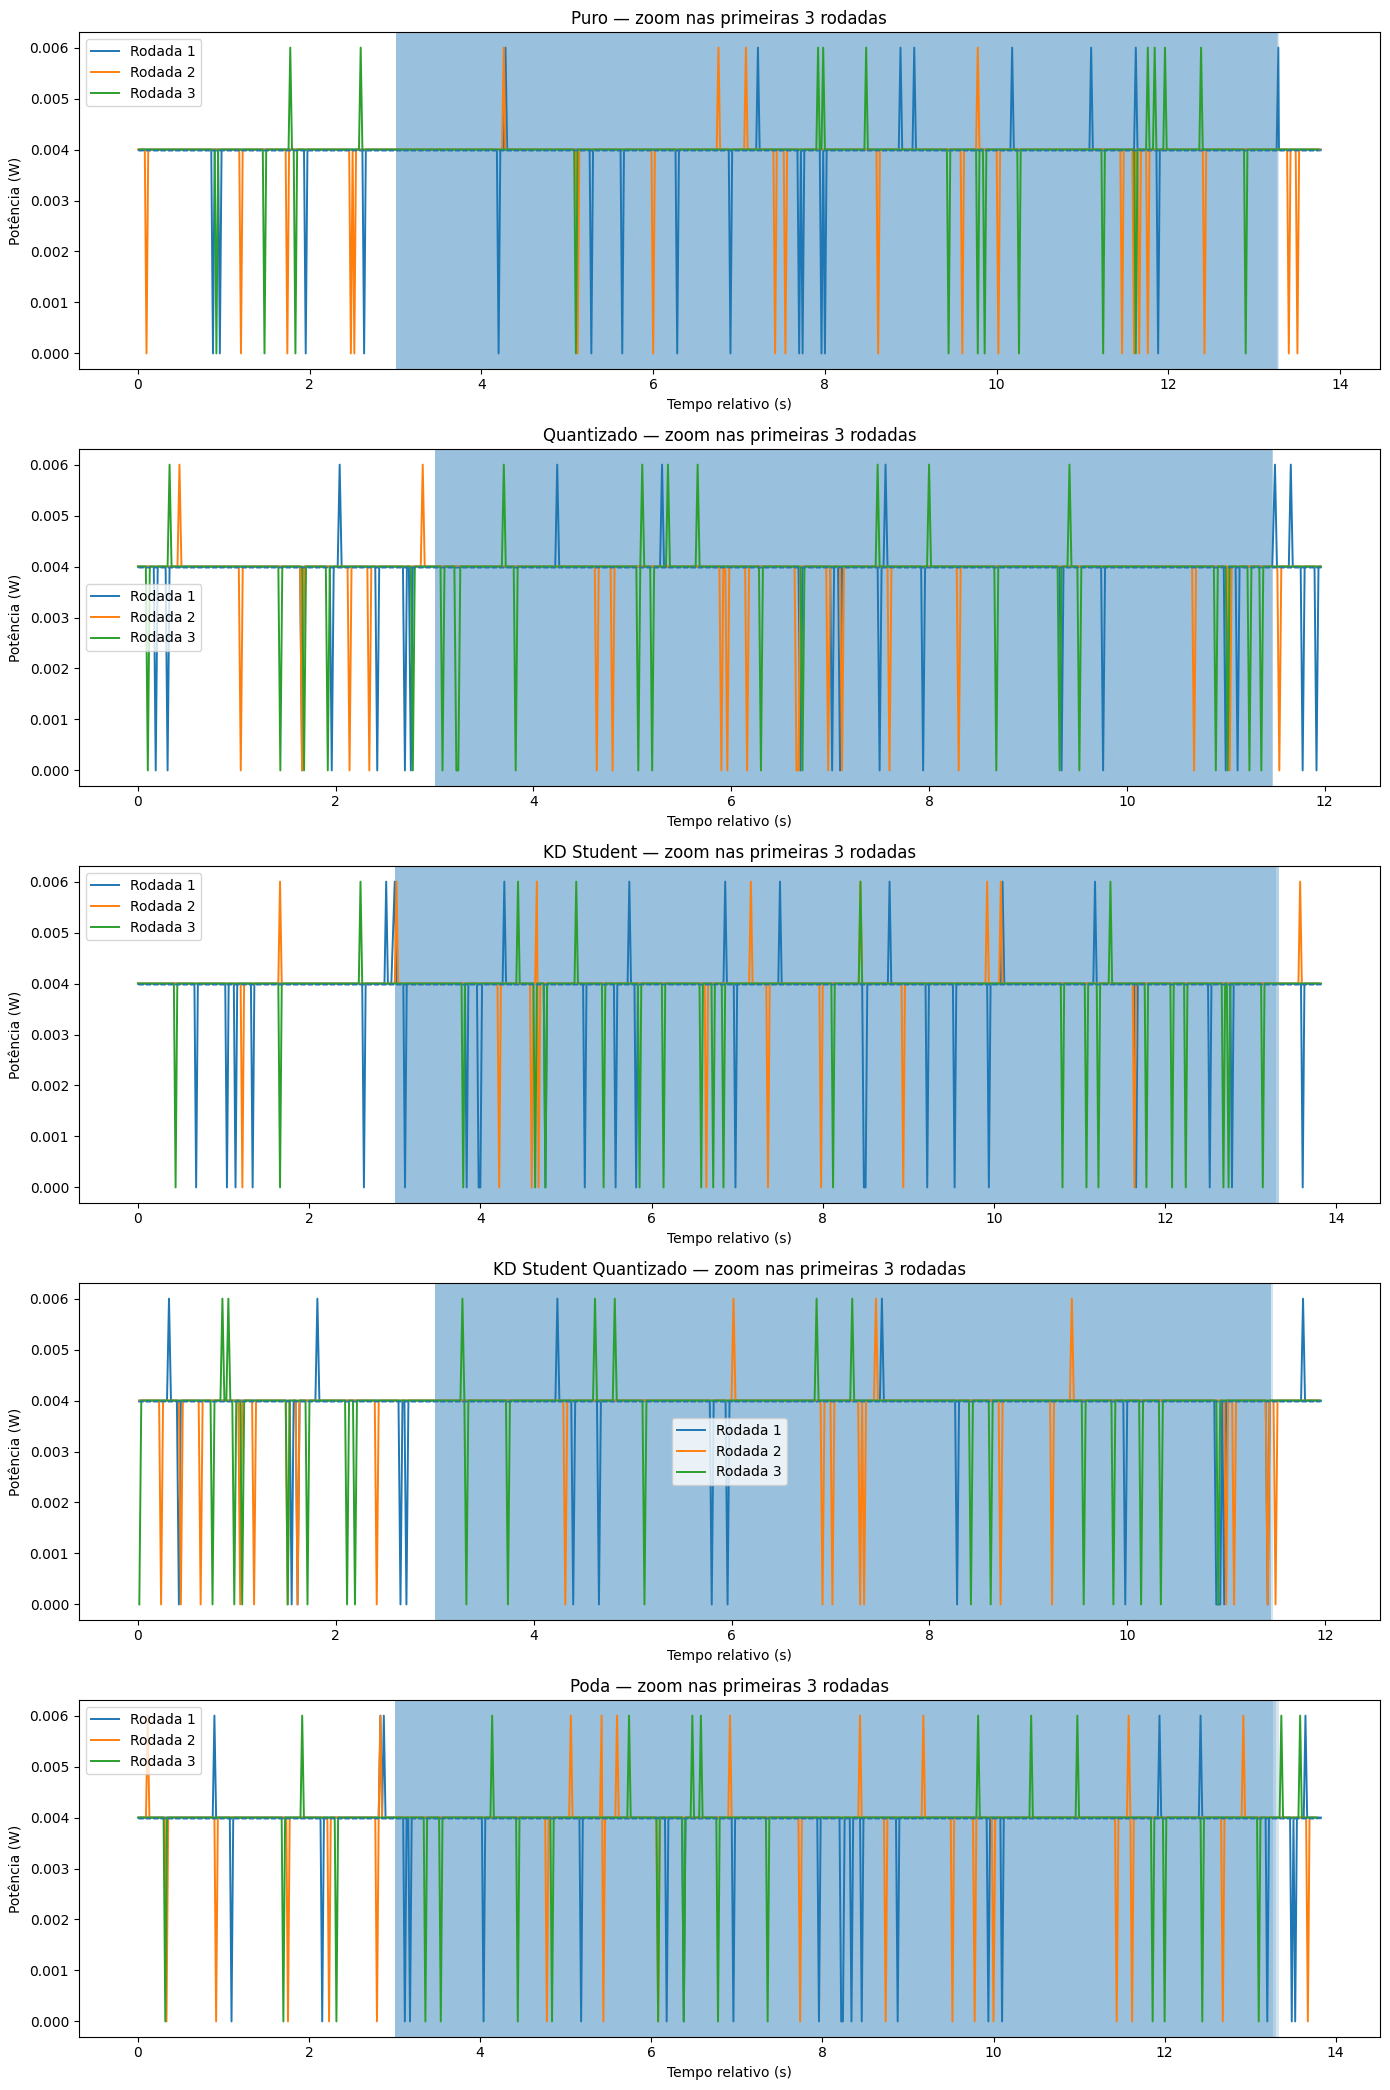


[OK] Tabela por rodada salva em: /home/clariele/Arduino/tinyMLP/EnergiaINA/resultados_energia/tabela_energia_por_rodada_tinyMLP.csv
[OK] Tabela resumo salva em: /home/clariele/Arduino/tinyMLP/EnergiaINA/resultados_energia/tabela_resumo_modelos_tinyMLP.csv
[OK] Gráfico salvo em: /home/clariele/Arduino/tinyMLP/EnergiaINA/resultados_energia/grafico_potencia_vs_tempo_tinyMLP_zoom.png


In [2]:
# -*- coding: utf-8 -*-
import os
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================
BASE_DIR = "/home/clariele/Arduino/tinyMLP/EnergiaINA/resultados_energia"

FILES = {
    "Puro": "tempo_inferencia_tinyMLP_puro.csv",
    "Quantizado": "tempo_inferencia_tinyMLP_quant.csv",
    "KD Student": "tempo_inferencia_tinyMLP_kd_student.csv",
    "KD Student Quantizado": "tempo_inferencia_tinyMLP_kd_student_quant.csv",
    "Poda": "tempo_inferencia_tinyMLP_poda.csv",
}

OUT_INTERVALS_CSV = os.path.join(BASE_DIR, "tabela_energia_por_rodada_tinyMLP.csv")
OUT_SUMMARY_CSV   = os.path.join(BASE_DIR, "tabela_resumo_modelos_tinyMLP.csv")
OUT_PLOT_PNG      = os.path.join(BASE_DIR, "grafico_potencia_vs_tempo_tinyMLP_zoom.png")

ROUND_POWER_FOR_PLOT = False
SAVE_OUTPUTS = True

# ===== CONFIG DO ZOOM =====
PRE_REST_WINDOW_S = 3.0     # segundos antes da inferência
POST_WINDOW_S = 0.5         # segundos depois da inferência
MAX_ROUNDS_TO_PLOT = 3      # quantas rodadas plotar por modelo


# =========================================================
# HELPERS
# =========================================================
def robust_mean_iqr(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if x.size == 0:
        return np.nan, 0, 0

    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr

    kept = x[(x >= lo) & (x <= hi)]

    if kept.size >= 3:
        return float(np.mean(kept)), int(x.size), int(kept.size)

    return float(np.median(x)), int(x.size), int(kept.size)


def contiguous_rest_before(start_idx, infer_vec):
    i1 = start_idx - 1
    if i1 < 0 or infer_vec[i1] != 0:
        return None

    i0 = i1
    while i0 - 1 >= 0 and infer_vec[i0 - 1] == 0:
        i0 -= 1

    return i0, i1


def parse_arduino_file(path):
    """
    Extrai:
      1) série temporal: tempo_s,power_W,inferindo,round,phase,bus_V,current_mA
      2) summaries: SUMMARY,round,phase,reps,total_us,avg_us
    """
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [ln.strip() for ln in f if ln.strip()]

    data_lines = []
    summary_rows = []

    expected_header = "tempo_s,power_W,inferindo,round,phase,bus_V,current_mA"
    header_found = False

    for ln in lines:
        ln_clean = ln.strip()

        if expected_header in ln_clean:
            data_lines = [expected_header]
            header_found = True
            continue

        if ln_clean.startswith("SUMMARY,"):
            parts = [p.strip() for p in ln_clean.split(",")]
            if len(parts) >= 6:
                summary_rows.append(parts[:6])
            continue

        if not header_found:
            continue

        parts = [p.strip() for p in ln_clean.split(",")]

        if len(parts) >= 7:
            try:
                float(parts[0])          # tempo_s
                float(parts[1])          # power_W
                int(float(parts[2]))     # inferindo
                data_lines.append(",".join(parts[:7]))
            except:
                pass

    if len(data_lines) <= 1:
        raise ValueError(f"Não foi possível extrair a série temporal de: {path}")

    df = pd.read_csv(io.StringIO("\n".join(data_lines)))
    df["tempo_s"] = pd.to_numeric(df["tempo_s"], errors="coerce")
    df["power_W"] = pd.to_numeric(df["power_W"], errors="coerce")
    df["inferindo"] = pd.to_numeric(df["inferindo"], errors="coerce").fillna(0).astype(int)
    df["round"] = pd.to_numeric(df["round"], errors="coerce")
    df["bus_V"] = pd.to_numeric(df["bus_V"], errors="coerce")
    df["current_mA"] = pd.to_numeric(df["current_mA"], errors="coerce")

    df = df.sort_values("tempo_s").reset_index(drop=True)
    df["power_W"] = df["power_W"].ffill().bfill()
    df = df.dropna(subset=["tempo_s", "power_W"]).reset_index(drop=True)

    if ROUND_POWER_FOR_PLOT:
        df["power_W_plot"] = df["power_W"].round(2)
    else:
        df["power_W_plot"] = df["power_W"]

    if summary_rows:
        df_summary = pd.DataFrame(
            summary_rows,
            columns=["tag", "round", "phase", "reps", "total_us", "avg_us"]
        )
        df_summary["round"] = pd.to_numeric(df_summary["round"], errors="coerce")
        df_summary["reps"] = pd.to_numeric(df_summary["reps"], errors="coerce")
        df_summary["total_us"] = pd.to_numeric(df_summary["total_us"], errors="coerce")
        df_summary["avg_us"] = pd.to_numeric(df_summary["avg_us"], errors="coerce")
        df_summary["duracao_s_summary"] = df_summary["total_us"] / 1e6
    else:
        df_summary = pd.DataFrame(columns=["round", "reps", "total_us", "avg_us", "duracao_s_summary"])

    return df, df_summary


def detect_intervals(df):
    t = df["tempo_s"].values
    infer = df["inferindo"].values

    infer_prev = np.r_[0, infer[:-1]]
    infer_next = np.r_[infer[1:], 0]

    starts_idx = np.where((infer == 1) & (infer_prev == 0))[0]
    ends_idx = np.where((infer == 1) & (infer_next == 0))[0]

    if len(starts_idx) > len(ends_idx) and len(df) > 0:
        ends_idx = np.r_[ends_idx, [len(df) - 1]]

    return list(zip(starts_idx, ends_idx))


def compute_energy_table(df, df_summary, model_name):
    t = df["tempo_s"].values
    p = df["power_W"].values
    infer = df["inferindo"].values
    intervals = detect_intervals(df)

    rows = []

    for k, (i0, i1) in enumerate(intervals, start=1):
        ts = t[i0:i1 + 1]
        ps = p[i0:i1 + 1]

        round_vals = df.loc[i0:i1, "round"].dropna().unique()
        round_id = int(round_vals[0]) if len(round_vals) > 0 else k

        rest_blk = contiguous_rest_before(i0, infer)

        if rest_blk is None:
            t_start = t[i0]
            mask = (t < t_start) & (t >= t_start - 60.0) & (infer == 0)
            rest_vals = p[mask]
            baseline, n_raw, n_kept = robust_mean_iqr(rest_vals)
            rest_t0 = float(t[i0]) - 60.0
            rest_t1 = float(t[i0])
        else:
            r0, r1 = rest_blk
            rest_vals = p[r0:r1 + 1]
            baseline, n_raw, n_kept = robust_mean_iqr(rest_vals)
            rest_t0 = float(t[r0])
            rest_t1 = float(t[r1])

        if np.isfinite(baseline):
            ps_excess = np.maximum(ps - baseline, 0.0)
        else:
            ps_excess = np.maximum(ps, 0.0)

        energy_J = float(np.trapz(ps_excess, ts))

        dur_summary = np.nan
        if not df_summary.empty:
            tmp = df_summary[df_summary["round"] == round_id]
            if not tmp.empty:
                dur_summary = float(tmp["duracao_s_summary"].iloc[0])

        dur_series = float(ts[-1] - ts[0]) if len(ts) > 1 else 0.0
        dur_s = dur_summary if np.isfinite(dur_summary) else dur_series

        pot_media_excedente_W = (energy_J / dur_s) if dur_s > 0 else np.nan

        rows.append({
            "modelo": model_name,
            "intervalo": k,
            "round": round_id,
            "inicio_s": float(ts[0]),
            "fim_s": float(ts[-1]),
            "duracao_s": dur_s,
            "duracao_s_plot": dur_series,
            "baseline_W": baseline,
            "energia_J": energy_J,
            "energia_mWh": energy_J / 3600.0 * 1000.0,
            "pot_media_excedente_W": pot_media_excedente_W,
            "amostras_repouso_raw": n_raw,
            "amostras_repouso_pos_iqr": n_kept,
            "repouso_inicio_s": rest_t0,
            "repouso_fim_s": rest_t1,
        })

    return pd.DataFrame(rows), intervals


# =========================================================
# PROCESSAR TODOS OS MODELOS
# =========================================================
all_energy_tables = []
plot_payload = []

for model_name, fname in FILES.items():
    path = os.path.join(BASE_DIR, fname)

    if not os.path.exists(path):
        print(f"[AVISO] Arquivo não encontrado: {path}")
        continue

    try:
        df_power, df_summary = parse_arduino_file(path)
        df_energy, intervals = compute_energy_table(df_power, df_summary, model_name)

        all_energy_tables.append(df_energy)
        plot_payload.append((model_name, df_power, df_energy, intervals))

    except ValueError as e:
        print(f"[AVISO] Pulando '{model_name}': {e}")
        continue

if not all_energy_tables:
    raise RuntimeError("Nenhum arquivo válido foi processado.")

df_all = pd.concat(all_energy_tables, ignore_index=True)

# =========================================================
# TABELA RESUMO
# =========================================================
df_resume = (
    df_all.groupby("modelo", as_index=False)
    .agg(
        n_rodadas=("round", "count"),
        duracao_media_s=("duracao_s", "mean"),
        baseline_medio_W=("baseline_W", "mean"),
        energia_media_J=("energia_J", "mean"),
        energia_media_mWh=("energia_mWh", "mean"),
        potencia_media_excedente_W=("pot_media_excedente_W", "mean"),
        energia_total_J=("energia_J", "sum"),
    )
    .sort_values("energia_media_J", ascending=False)
    .reset_index(drop=True)
)

# =========================================================
# PRINTS
# =========================================================
print("\n=== TABELA POR RODADA ===\n")
cols_round = [
    "modelo", "round", "duracao_s", "baseline_W", "energia_J",
    "energia_mWh", "pot_media_excedente_W"
]
with pd.option_context("display.max_rows", None, "display.float_format", lambda v: f"{v:.6f}"):
    print(df_all[cols_round].sort_values(["modelo", "round"]).to_string(index=False))

print("\n=== TABELA RESUMO (ORDENADA DO MAIOR CONSUMO MÉDIO PARA O MENOR) ===\n")
cols_resume = [
    "modelo", "n_rodadas", "duracao_media_s", "baseline_medio_W",
    "energia_media_J", "energia_media_mWh", "potencia_media_excedente_W", "energia_total_J"
]
with pd.option_context("display.max_rows", None, "display.float_format", lambda v: f"{v:.6f}"):
    print(df_resume[cols_resume].to_string(index=False))

# =========================================================
# PLOT — ZOOM NAS INFERÊNCIAS
# =========================================================
n_models = len(plot_payload)
fig, axes = plt.subplots(n_models, 1, figsize=(14, 4.2 * n_models), sharex=False)

if n_models == 1:
    axes = [axes]

for ax, (model_name, df_power, df_energy, intervals) in zip(axes, plot_payload):
    t_all = df_power["tempo_s"].values
    p_all = df_power["power_W_plot"].values

    plotted_any = False

    for idx, (i0, i1) in enumerate(intervals[:MAX_ROUNDS_TO_PLOT]):
        t0 = t_all[i0]
        t1 = t_all[i1]

        win_start = max(t_all[0], t0 - PRE_REST_WINDOW_S)
        win_end = min(t_all[-1], t1 + POST_WINDOW_S)

        mask = (t_all >= win_start) & (t_all <= win_end)
        t_win = t_all[mask] - win_start
        p_win = p_all[mask]

        ax.plot(
            t_win,
            p_win,
            linewidth=1.4,
            label=f"Rodada {idx+1}"
        )

        infer_start_rel = t0 - win_start
        infer_end_rel = t1 - win_start
        ax.axvspan(
            infer_start_rel,
            infer_end_rel,
            alpha=0.18
        )

        if idx < len(df_energy):
            b = df_energy.iloc[idx]["baseline_W"]
            if np.isfinite(b):
                ax.hlines(
                    b,
                    0,
                    t_win[-1],
                    linestyles="dashed",
                    linewidth=1.0
                )

        plotted_any = True

    ax.set_title(f"{model_name} — zoom nas primeiras {min(MAX_ROUNDS_TO_PLOT, len(intervals))} rodadas")
    ax.set_xlabel("Tempo relativo (s)")
    ax.set_ylabel("Potência (W)")

    if plotted_any:
        ax.legend(loc="best")

plt.tight_layout()
plt.show()

# =========================================================
# SALVAR
# =========================================================
if SAVE_OUTPUTS:
    df_all.sort_values(["modelo", "round"]).to_csv(OUT_INTERVALS_CSV, index=False)
    df_resume.to_csv(OUT_SUMMARY_CSV, index=False)
    fig.savefig(OUT_PLOT_PNG, dpi=200, bbox_inches="tight")

    print(f"\n[OK] Tabela por rodada salva em: {OUT_INTERVALS_CSV}")
    print(f"[OK] Tabela resumo salva em: {OUT_SUMMARY_CSV}")
    print(f"[OK] Gráfico salvo em: {OUT_PLOT_PNG}")


## GRÁFICO MLP PURO


TABELA COMPLETA - TODOS OS ROUNDS

 round  duracao_s  baseline_W  energia_J  energia_mWh
     1  10.365520    0.003899   0.001322     0.000367
     2  10.362220    0.003897   0.001191     0.000331
     3  10.343900    0.003886   0.001431     0.000398
     4  10.313789    0.003880   0.001318     0.000366
     5  10.350054    0.003898   0.001183     0.000329
     6  10.331837    0.003888   0.001146     0.000318
     7  10.339808    0.003895   0.001128     0.000313
     8  10.347564    0.003895   0.001239     0.000344
     9  10.313024    0.003901   0.001090     0.000303
    10  10.373130    0.003902   0.001108     0.000308

MÉDIAS GERAIS

Tempo médio de inferência (s): 10.344085
Energia média de inferência (J): 0.001216
Energia média de inferência (mWh): 0.000338


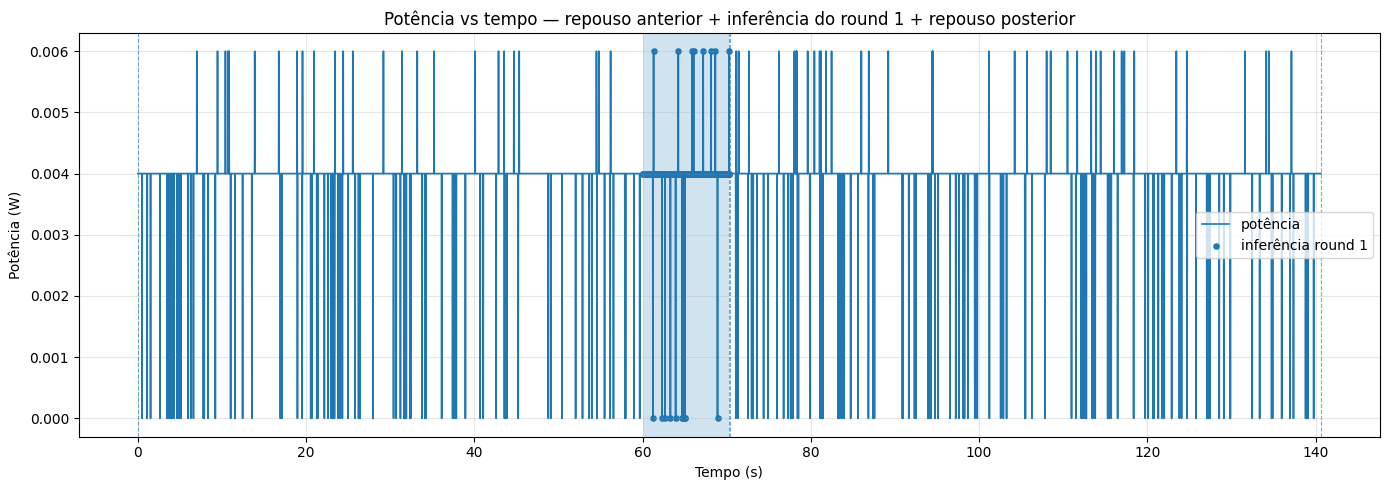

In [6]:
# -*- coding: utf-8 -*-
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILE_PATH = "/home/clariele/Arduino/tinyMLP/EnergiaINA/resultados_energia/tempo_inferencia_tinyMLP_puro.csv"

ROUND_TO_PLOT = 1   # <<< mude aqui: 1, 2, 3, ...


# =========================================================
# LER ARQUIVO
# =========================================================
with open(FILE_PATH, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

header_idx = None
for i, line in enumerate(lines):
    line_clean = line.strip().replace("\t", ",")
    if "tempo_s" in line_clean and "power_W" in line_clean:
        header_idx = i
        break

if header_idx is None:
    raise ValueError("Cabeçalho não encontrado.")

data_lines = ["tempo_s,power_W,inferindo,round,phase,bus_V,current_mA"]
summary_rows = []

for line in lines[header_idx + 1:]:
    line_clean = line.strip()

    if not line_clean:
        continue

    if line_clean.startswith("SUMMARY_HEADER"):
        continue

    if line_clean.startswith("SUMMARY"):
        line_clean = line_clean.replace("\t", ",")
        parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]
        if len(parts) >= 6 and parts[0] == "SUMMARY":
            summary_rows.append(parts[:6])
        continue

    line_clean = line_clean.replace("\t", ",")
    parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]

    if len(parts) >= 7:
        try:
            float(parts[0])      # tempo_s
            float(parts[1])      # power_W
            int(float(parts[2])) # inferindo
            data_lines.append(",".join(parts[:7]))
        except:
            pass

df = pd.read_csv(io.StringIO("\n".join(data_lines)))

for col in ["tempo_s", "power_W", "inferindo", "round", "bus_V", "current_mA"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["tempo_s", "power_W", "round"]).copy()
df["round"] = df["round"].astype(int)
df["inferindo"] = df["inferindo"].fillna(0).astype(int)
df = df.sort_values(["tempo_s"]).reset_index(drop=True)

# =========================================================
# SUMMARY
# =========================================================
if summary_rows:
    df_summary = pd.DataFrame(
        summary_rows,
        columns=["tag", "round", "phase", "reps", "total_us", "avg_us"]
    )
    for col in ["round", "reps", "total_us", "avg_us"]:
        df_summary[col] = pd.to_numeric(df_summary[col], errors="coerce")
    df_summary["duracao_s_summary"] = df_summary["total_us"] / 1e6
else:
    df_summary = pd.DataFrame(columns=["round", "phase", "reps", "total_us", "avg_us", "duracao_s_summary"])


# =========================================================
# DETECTAR INTERVALOS DE INFERÊNCIA GLOBAIS
# =========================================================
def detect_intervals(df_):
    infer = df_["inferindo"].values

    infer_prev = np.r_[0, infer[:-1]]
    infer_next = np.r_[infer[1:], 0]

    starts = np.where((infer == 1) & (infer_prev == 0))[0]
    ends   = np.where((infer == 1) & (infer_next == 0))[0]

    return list(zip(starts, ends))


intervals = detect_intervals(df)

# =========================================================
# TABELA COMPLETA DE TODOS OS ROUNDS
# =========================================================
rows = []

for idx, (i0, i1) in enumerate(intervals, start=1):
    df_seg = df.iloc[i0:i1+1].copy()

    round_vals = df_seg["round"].dropna().unique()
    round_id = int(round_vals[0]) if len(round_vals) > 0 else idx

    ts = df_seg["tempo_s"].values
    ps = df_seg["power_W"].values

    # baseline = média do repouso do mesmo round
    df_round = df[df["round"] == round_id].copy()
    rest_vals = df_round[df_round["inferindo"] == 0]["power_W"].values

    if len(rest_vals) == 0:
        baseline = np.nan
    else:
        baseline = np.mean(rest_vals)

    ps_excess = np.maximum(ps - baseline, 0) if np.isfinite(baseline) else ps
    energia_J = np.trapz(ps_excess, ts)

    # tempo da inferência: prioriza SUMMARY
    dur_summary = np.nan
    tmp = df_summary[df_summary["round"] == round_id]
    if not tmp.empty:
        dur_summary = tmp["duracao_s_summary"].iloc[0]

    dur_series = ts[-1] - ts[0] if len(ts) > 1 else 0.0
    duracao_s = dur_summary if np.isfinite(dur_summary) else dur_series

    rows.append({
        "round": round_id,
        "duracao_s": duracao_s,
        "baseline_W": baseline,
        "energia_J": energia_J,
        "energia_mWh": energia_J / 3600.0 * 1000.0
    })

df_results = pd.DataFrame(rows).sort_values("round").reset_index(drop=True)

print("\nTABELA COMPLETA - TODOS OS ROUNDS\n")
with pd.option_context("display.max_rows", None, "display.float_format", lambda x: f"{x:.6f}"):
    print(df_results.to_string(index=False))

print("\nMÉDIAS GERAIS\n")
print(f"Tempo médio de inferência (s): {df_results['duracao_s'].mean():.6f}")
print(f"Energia média de inferência (J): {df_results['energia_J'].mean():.6f}")
print(f"Energia média de inferência (mWh): {df_results['energia_mWh'].mean():.6f}")


# =========================================================
# GRÁFICO: REPOUSO ANTERIOR + INFERÊNCIA + REPOUSO POSTERIOR
# =========================================================
all_rounds = sorted(df["round"].dropna().unique())

if ROUND_TO_PLOT not in all_rounds:
    raise ValueError(f"Round {ROUND_TO_PLOT} não encontrado.")

prev_round = ROUND_TO_PLOT - 1 if (ROUND_TO_PLOT - 1) in all_rounds else None
next_round = ROUND_TO_PLOT + 1 if (ROUND_TO_PLOT + 1) in all_rounds else None

rounds_for_plot = []
if prev_round is not None:
    rounds_for_plot.append(prev_round)
rounds_for_plot.append(ROUND_TO_PLOT)
if next_round is not None:
    rounds_for_plot.append(next_round)

df_plot = df[df["round"].isin(rounds_for_plot)].copy().sort_values("tempo_s")

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_plot["tempo_s"], df_plot["power_W"], linewidth=1.2, label="potência")

# destacar somente a inferência do round escolhido
df_inf_target = df[(df["round"] == ROUND_TO_PLOT) & (df["inferindo"] == 1)].copy()

if not df_inf_target.empty:
    ax.scatter(
        df_inf_target["tempo_s"],
        df_inf_target["power_W"],
        s=14,
        label=f"inferência round {ROUND_TO_PLOT}"
    )

    t0 = df_inf_target["tempo_s"].min()
    t1 = df_inf_target["tempo_s"].max()
    ax.axvspan(t0, t1, alpha=0.20)

# linhas verticais para separar rounds
for r in rounds_for_plot:
    df_r = df[df["round"] == r]
    if not df_r.empty:
        ax.axvline(df_r["tempo_s"].min(), linestyle="--", linewidth=0.8, alpha=0.6)
        ax.axvline(df_r["tempo_s"].max(), linestyle="--", linewidth=0.8, alpha=0.6)

ax.set_title(
    f"Potência vs tempo — repouso anterior + inferência do round {ROUND_TO_PLOT} + repouso posterior"
)
ax.set_xlabel("Tempo (s)")
ax.set_ylabel("Potência (W)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## GRÁFICO MLP QUANT


TABELA COMPLETA - TODOS OS ROUNDS

 round  duracao_s  baseline_W  energia_J  energia_mWh
     1   8.544043    0.003893   0.001005     0.000279
     2   8.548119    0.003892   0.000888     0.000247
     3   8.548546    0.003880   0.001261     0.000350
     4   8.549903    0.003895   0.001063     0.000295
     5   8.549170    0.003901   0.000936     0.000260
     6   8.553136    0.003879   0.001103     0.000306
     7   8.546794    0.003899   0.000950     0.000264
     8   8.531238    0.003887   0.001168     0.000324
     9   8.565543    0.003877   0.001117     0.000310
    10   8.554450    0.003877   0.001255     0.000349

MÉDIAS GERAIS

Tempo médio de inferência (s): 8.549094
Energia média de inferência (J): 0.001075
Energia média de inferência (mWh): 0.000298


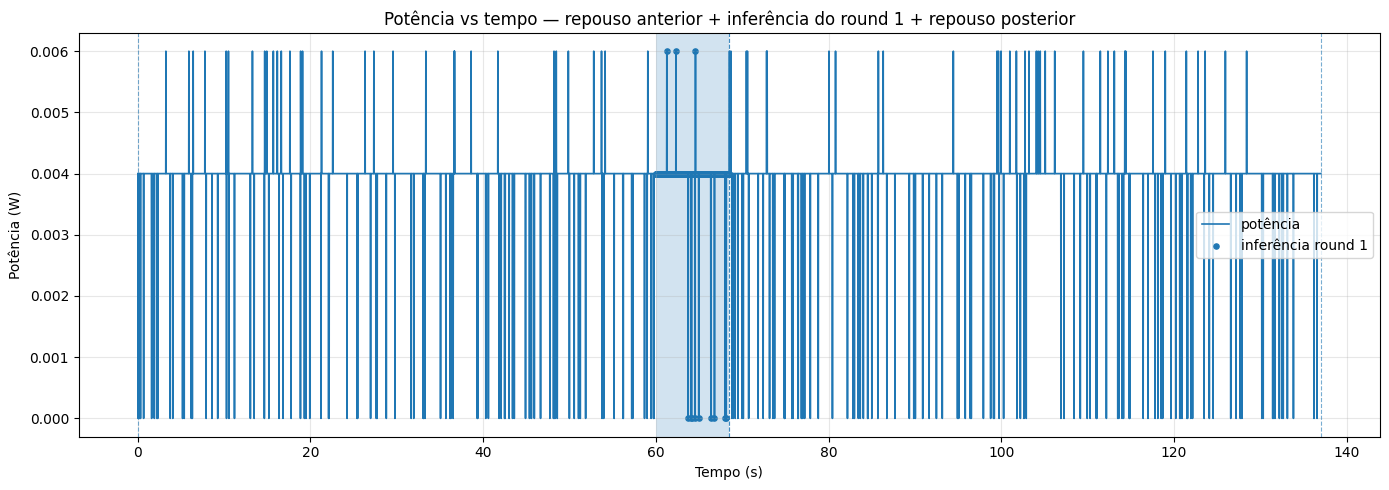

In [7]:
# -*- coding: utf-8 -*-
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILE_PATH = "/home/clariele/Arduino/tinyMLP/EnergiaINA/resultados_energia/tempo_inferencia_tinyMLP_quant.csv"

ROUND_TO_PLOT = 1   # <<< mude aqui: 1, 2, 3, ...


# =========================================================
# LER ARQUIVO
# =========================================================
with open(FILE_PATH, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

header_idx = None
for i, line in enumerate(lines):
    line_clean = line.strip().replace("\t", ",")
    if "tempo_s" in line_clean and "power_W" in line_clean:
        header_idx = i
        break

if header_idx is None:
    raise ValueError("Cabeçalho não encontrado.")

data_lines = ["tempo_s,power_W,inferindo,round,phase,bus_V,current_mA"]
summary_rows = []

for line in lines[header_idx + 1:]:
    line_clean = line.strip()

    if not line_clean:
        continue

    if line_clean.startswith("SUMMARY_HEADER"):
        continue

    if line_clean.startswith("SUMMARY"):
        line_clean = line_clean.replace("\t", ",")
        parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]
        if len(parts) >= 6 and parts[0] == "SUMMARY":
            summary_rows.append(parts[:6])
        continue

    line_clean = line_clean.replace("\t", ",")
    parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]

    if len(parts) >= 7:
        try:
            float(parts[0])      # tempo_s
            float(parts[1])      # power_W
            int(float(parts[2])) # inferindo
            data_lines.append(",".join(parts[:7]))
        except:
            pass

df = pd.read_csv(io.StringIO("\n".join(data_lines)))

for col in ["tempo_s", "power_W", "inferindo", "round", "bus_V", "current_mA"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["tempo_s", "power_W", "round"]).copy()
df["round"] = df["round"].astype(int)
df["inferindo"] = df["inferindo"].fillna(0).astype(int)
df = df.sort_values(["tempo_s"]).reset_index(drop=True)

# =========================================================
# SUMMARY
# =========================================================
if summary_rows:
    df_summary = pd.DataFrame(
        summary_rows,
        columns=["tag", "round", "phase", "reps", "total_us", "avg_us"]
    )
    for col in ["round", "reps", "total_us", "avg_us"]:
        df_summary[col] = pd.to_numeric(df_summary[col], errors="coerce")
    df_summary["duracao_s_summary"] = df_summary["total_us"] / 1e6
else:
    df_summary = pd.DataFrame(columns=["round", "phase", "reps", "total_us", "avg_us", "duracao_s_summary"])


# =========================================================
# DETECTAR INTERVALOS DE INFERÊNCIA GLOBAIS
# =========================================================
def detect_intervals(df_):
    infer = df_["inferindo"].values

    infer_prev = np.r_[0, infer[:-1]]
    infer_next = np.r_[infer[1:], 0]

    starts = np.where((infer == 1) & (infer_prev == 0))[0]
    ends   = np.where((infer == 1) & (infer_next == 0))[0]

    return list(zip(starts, ends))


intervals = detect_intervals(df)

# =========================================================
# TABELA COMPLETA DE TODOS OS ROUNDS
# =========================================================
rows = []

for idx, (i0, i1) in enumerate(intervals, start=1):
    df_seg = df.iloc[i0:i1+1].copy()

    round_vals = df_seg["round"].dropna().unique()
    round_id = int(round_vals[0]) if len(round_vals) > 0 else idx

    ts = df_seg["tempo_s"].values
    ps = df_seg["power_W"].values

    # baseline = média do repouso do mesmo round
    df_round = df[df["round"] == round_id].copy()
    rest_vals = df_round[df_round["inferindo"] == 0]["power_W"].values

    if len(rest_vals) == 0:
        baseline = np.nan
    else:
        baseline = np.mean(rest_vals)

    ps_excess = np.maximum(ps - baseline, 0) if np.isfinite(baseline) else ps
    energia_J = np.trapz(ps_excess, ts)

    # tempo da inferência: prioriza SUMMARY
    dur_summary = np.nan
    tmp = df_summary[df_summary["round"] == round_id]
    if not tmp.empty:
        dur_summary = tmp["duracao_s_summary"].iloc[0]

    dur_series = ts[-1] - ts[0] if len(ts) > 1 else 0.0
    duracao_s = dur_summary if np.isfinite(dur_summary) else dur_series

    rows.append({
        "round": round_id,
        "duracao_s": duracao_s,
        "baseline_W": baseline,
        "energia_J": energia_J,
        "energia_mWh": energia_J / 3600.0 * 1000.0
    })

df_results = pd.DataFrame(rows).sort_values("round").reset_index(drop=True)

print("\nTABELA COMPLETA - TODOS OS ROUNDS\n")
with pd.option_context("display.max_rows", None, "display.float_format", lambda x: f"{x:.6f}"):
    print(df_results.to_string(index=False))

print("\nMÉDIAS GERAIS\n")
print(f"Tempo médio de inferência (s): {df_results['duracao_s'].mean():.6f}")
print(f"Energia média de inferência (J): {df_results['energia_J'].mean():.6f}")
print(f"Energia média de inferência (mWh): {df_results['energia_mWh'].mean():.6f}")


# =========================================================
# GRÁFICO: REPOUSO ANTERIOR + INFERÊNCIA + REPOUSO POSTERIOR
# =========================================================
all_rounds = sorted(df["round"].dropna().unique())

if ROUND_TO_PLOT not in all_rounds:
    raise ValueError(f"Round {ROUND_TO_PLOT} não encontrado.")

prev_round = ROUND_TO_PLOT - 1 if (ROUND_TO_PLOT - 1) in all_rounds else None
next_round = ROUND_TO_PLOT + 1 if (ROUND_TO_PLOT + 1) in all_rounds else None

rounds_for_plot = []
if prev_round is not None:
    rounds_for_plot.append(prev_round)
rounds_for_plot.append(ROUND_TO_PLOT)
if next_round is not None:
    rounds_for_plot.append(next_round)

df_plot = df[df["round"].isin(rounds_for_plot)].copy().sort_values("tempo_s")

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_plot["tempo_s"], df_plot["power_W"], linewidth=1.2, label="potência")

# destacar somente a inferência do round escolhido
df_inf_target = df[(df["round"] == ROUND_TO_PLOT) & (df["inferindo"] == 1)].copy()

if not df_inf_target.empty:
    ax.scatter(
        df_inf_target["tempo_s"],
        df_inf_target["power_W"],
        s=14,
        label=f"inferência round {ROUND_TO_PLOT}"
    )

    t0 = df_inf_target["tempo_s"].min()
    t1 = df_inf_target["tempo_s"].max()
    ax.axvspan(t0, t1, alpha=0.20)

# linhas verticais para separar rounds
for r in rounds_for_plot:
    df_r = df[df["round"] == r]
    if not df_r.empty:
        ax.axvline(df_r["tempo_s"].min(), linestyle="--", linewidth=0.8, alpha=0.6)
        ax.axvline(df_r["tempo_s"].max(), linestyle="--", linewidth=0.8, alpha=0.6)

ax.set_title(
    f"Potência vs tempo — repouso anterior + inferência do round {ROUND_TO_PLOT} + repouso posterior"
)
ax.set_xlabel("Tempo (s)")
ax.set_ylabel("Potência (W)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## GRÁFICO MLP KD TEACHER


TABELA COMPLETA - TODOS OS ROUNDS

 round  duracao_s  baseline_W  energia_J  energia_mWh
     1  15.345125    0.003968   0.001358     0.000377
     2  15.369149    0.003957   0.001198     0.000333
     3  15.380261    0.003982   0.000790     0.000219
     4  15.338461    0.003954   0.001341     0.000373
     5  15.386804    0.003987   0.000878     0.000244
     6  15.403057    0.003979   0.000923     0.000256
     7  15.386297    0.003973   0.000886     0.000246
     8  15.366244    0.003948   0.001214     0.000337
     9  15.374758    0.003981   0.000680     0.000189
    10  15.390485    0.003967   0.001341     0.000373

MÉDIAS GERAIS

Tempo médio de inferência (s): 15.374064
Energia média de inferência (J): 0.001061
Energia média de inferência (mWh): 0.000295


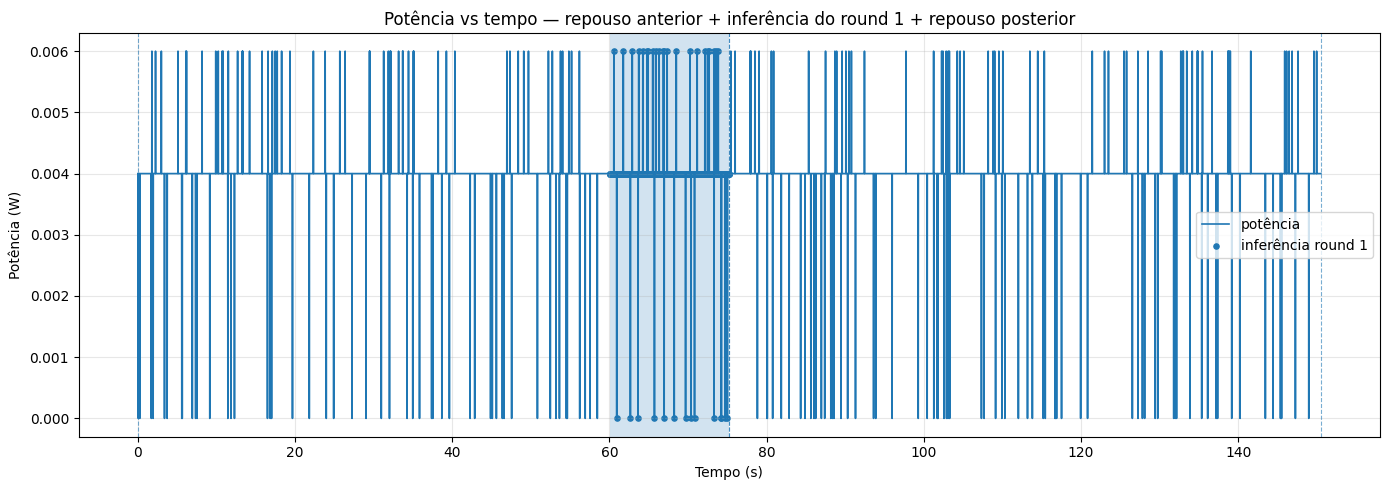

In [14]:
# -*- coding: utf-8 -*-
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILE_PATH = "/home/clariele/Arduino/tinyMLP/EnergiaINA/resultados_energia/tempo_inferencia_tinyMLP_kd_teacher_1.csv"

ROUND_TO_PLOT = 1   # <<< mude aqui: 1, 2, 3, ...


# =========================================================
# LER ARQUIVO
# =========================================================
with open(FILE_PATH, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

header_idx = None
for i, line in enumerate(lines):
    line_clean = line.strip().replace("\t", ",")
    if "tempo_s" in line_clean and "power_W" in line_clean:
        header_idx = i
        break

if header_idx is None:
    raise ValueError("Cabeçalho não encontrado.")

data_lines = ["tempo_s,power_W,inferindo,round,phase,bus_V,current_mA"]
summary_rows = []

for line in lines[header_idx + 1:]:
    line_clean = line.strip()

    if not line_clean:
        continue

    if line_clean.startswith("SUMMARY_HEADER"):
        continue

    if line_clean.startswith("SUMMARY"):
        line_clean = line_clean.replace("\t", ",")
        parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]
        if len(parts) >= 6 and parts[0] == "SUMMARY":
            summary_rows.append(parts[:6])
        continue

    line_clean = line_clean.replace("\t", ",")
    parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]

    if len(parts) >= 7:
        try:
            float(parts[0])      # tempo_s
            float(parts[1])      # power_W
            int(float(parts[2])) # inferindo
            data_lines.append(",".join(parts[:7]))
        except:
            pass

df = pd.read_csv(io.StringIO("\n".join(data_lines)))

for col in ["tempo_s", "power_W", "inferindo", "round", "bus_V", "current_mA"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["tempo_s", "power_W", "round"]).copy()
df["round"] = df["round"].astype(int)
df["inferindo"] = df["inferindo"].fillna(0).astype(int)
df = df.sort_values(["tempo_s"]).reset_index(drop=True)

# =========================================================
# SUMMARY
# =========================================================
if summary_rows:
    df_summary = pd.DataFrame(
        summary_rows,
        columns=["tag", "round", "phase", "reps", "total_us", "avg_us"]
    )
    for col in ["round", "reps", "total_us", "avg_us"]:
        df_summary[col] = pd.to_numeric(df_summary[col], errors="coerce")
    df_summary["duracao_s_summary"] = df_summary["total_us"] / 1e6
else:
    df_summary = pd.DataFrame(columns=["round", "phase", "reps", "total_us", "avg_us", "duracao_s_summary"])


# =========================================================
# DETECTAR INTERVALOS DE INFERÊNCIA GLOBAIS
# =========================================================
def detect_intervals(df_):
    infer = df_["inferindo"].values

    infer_prev = np.r_[0, infer[:-1]]
    infer_next = np.r_[infer[1:], 0]

    starts = np.where((infer == 1) & (infer_prev == 0))[0]
    ends   = np.where((infer == 1) & (infer_next == 0))[0]

    return list(zip(starts, ends))


intervals = detect_intervals(df)

# =========================================================
# TABELA COMPLETA DE TODOS OS ROUNDS
# =========================================================
rows = []

for idx, (i0, i1) in enumerate(intervals, start=1):
    df_seg = df.iloc[i0:i1+1].copy()

    round_vals = df_seg["round"].dropna().unique()
    round_id = int(round_vals[0]) if len(round_vals) > 0 else idx

    ts = df_seg["tempo_s"].values
    ps = df_seg["power_W"].values

    # baseline = média do repouso do mesmo round
    df_round = df[df["round"] == round_id].copy()
    rest_vals = df_round[df_round["inferindo"] == 0]["power_W"].values

    if len(rest_vals) == 0:
        baseline = np.nan
    else:
        baseline = np.mean(rest_vals)

    ps_excess = np.maximum(ps - baseline, 0) if np.isfinite(baseline) else ps
    energia_J = np.trapz(ps_excess, ts)

    # tempo da inferência: prioriza SUMMARY
    dur_summary = np.nan
    tmp = df_summary[df_summary["round"] == round_id]
    if not tmp.empty:
        dur_summary = tmp["duracao_s_summary"].iloc[0]

    dur_series = ts[-1] - ts[0] if len(ts) > 1 else 0.0
    duracao_s = dur_summary if np.isfinite(dur_summary) else dur_series

    rows.append({
        "round": round_id,
        "duracao_s": duracao_s,
        "baseline_W": baseline,
        "energia_J": energia_J,
        "energia_mWh": energia_J / 3600.0 * 1000.0
    })

df_results = pd.DataFrame(rows).sort_values("round").reset_index(drop=True)

print("\nTABELA COMPLETA - TODOS OS ROUNDS\n")
with pd.option_context("display.max_rows", None, "display.float_format", lambda x: f"{x:.6f}"):
    print(df_results.to_string(index=False))

print("\nMÉDIAS GERAIS\n")
print(f"Tempo médio de inferência (s): {df_results['duracao_s'].mean():.6f}")
print(f"Energia média de inferência (J): {df_results['energia_J'].mean():.6f}")
print(f"Energia média de inferência (mWh): {df_results['energia_mWh'].mean():.6f}")


# =========================================================
# GRÁFICO: REPOUSO ANTERIOR + INFERÊNCIA + REPOUSO POSTERIOR
# =========================================================
all_rounds = sorted(df["round"].dropna().unique())

if ROUND_TO_PLOT not in all_rounds:
    raise ValueError(f"Round {ROUND_TO_PLOT} não encontrado.")

prev_round = ROUND_TO_PLOT - 1 if (ROUND_TO_PLOT - 1) in all_rounds else None
next_round = ROUND_TO_PLOT + 1 if (ROUND_TO_PLOT + 1) in all_rounds else None

rounds_for_plot = []
if prev_round is not None:
    rounds_for_plot.append(prev_round)
rounds_for_plot.append(ROUND_TO_PLOT)
if next_round is not None:
    rounds_for_plot.append(next_round)

df_plot = df[df["round"].isin(rounds_for_plot)].copy().sort_values("tempo_s")

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_plot["tempo_s"], df_plot["power_W"], linewidth=1.2, label="potência")

# destacar somente a inferência do round escolhido
df_inf_target = df[(df["round"] == ROUND_TO_PLOT) & (df["inferindo"] == 1)].copy()

if not df_inf_target.empty:
    ax.scatter(
        df_inf_target["tempo_s"],
        df_inf_target["power_W"],
        s=14,
        label=f"inferência round {ROUND_TO_PLOT}"
    )

    t0 = df_inf_target["tempo_s"].min()
    t1 = df_inf_target["tempo_s"].max()
    ax.axvspan(t0, t1, alpha=0.20)

# linhas verticais para separar rounds
for r in rounds_for_plot:
    df_r = df[df["round"] == r]
    if not df_r.empty:
        ax.axvline(df_r["tempo_s"].min(), linestyle="--", linewidth=0.8, alpha=0.6)
        ax.axvline(df_r["tempo_s"].max(), linestyle="--", linewidth=0.8, alpha=0.6)

ax.set_title(
    f"Potência vs tempo — repouso anterior + inferência do round {ROUND_TO_PLOT} + repouso posterior"
)
ax.set_xlabel("Tempo (s)")
ax.set_ylabel("Potência (W)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## GRÁFICO MLP KD STUDENT


TABELA COMPLETA - TODOS OS ROUNDS

 round  duracao_s  baseline_W  energia_J  energia_mWh
     1  10.382358    0.003919   0.001104     0.000307
     2  10.404076    0.003917   0.001088     0.000302
     3  10.414931    0.003918   0.000976     0.000271
     4  10.424148    0.003917   0.001045     0.000290
     5  10.305584    0.003899   0.001336     0.000371
     6  10.418913    0.003920   0.000995     0.000276
     7  10.421724    0.003897   0.001320     0.000367
     8  10.431861    0.003901   0.001279     0.000355
     9  10.404208    0.003913   0.000950     0.000264
    10  10.425773    0.003923   0.001178     0.000327

MÉDIAS GERAIS

Tempo médio de inferência (s): 10.403358
Energia média de inferência (J): 0.001127
Energia média de inferência (mWh): 0.000313


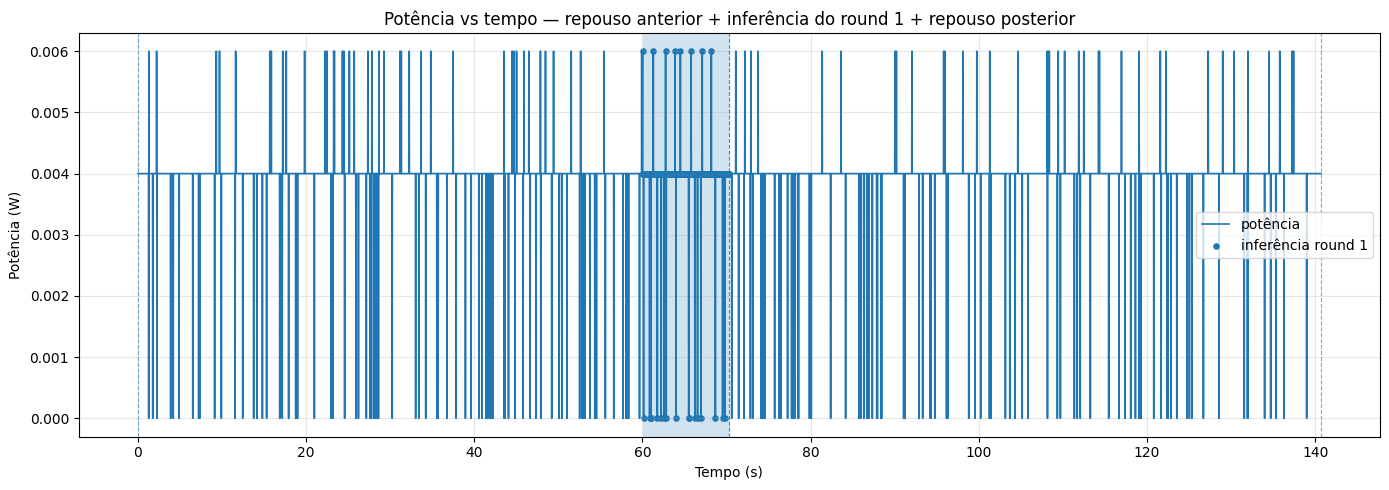

In [9]:
# -*- coding: utf-8 -*-
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILE_PATH = "/home/clariele/Arduino/tinyMLP/EnergiaINA/resultados_energia/tempo_inferencia_tinyMLP_kd_student.csv"

ROUND_TO_PLOT = 1   # <<< mude aqui: 1, 2, 3, ...


# =========================================================
# LER ARQUIVO
# =========================================================
with open(FILE_PATH, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

header_idx = None
for i, line in enumerate(lines):
    line_clean = line.strip().replace("\t", ",")
    if "tempo_s" in line_clean and "power_W" in line_clean:
        header_idx = i
        break

if header_idx is None:
    raise ValueError("Cabeçalho não encontrado.")

data_lines = ["tempo_s,power_W,inferindo,round,phase,bus_V,current_mA"]
summary_rows = []

for line in lines[header_idx + 1:]:
    line_clean = line.strip()

    if not line_clean:
        continue

    if line_clean.startswith("SUMMARY_HEADER"):
        continue

    if line_clean.startswith("SUMMARY"):
        line_clean = line_clean.replace("\t", ",")
        parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]
        if len(parts) >= 6 and parts[0] == "SUMMARY":
            summary_rows.append(parts[:6])
        continue

    line_clean = line_clean.replace("\t", ",")
    parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]

    if len(parts) >= 7:
        try:
            float(parts[0])      # tempo_s
            float(parts[1])      # power_W
            int(float(parts[2])) # inferindo
            data_lines.append(",".join(parts[:7]))
        except:
            pass

df = pd.read_csv(io.StringIO("\n".join(data_lines)))

for col in ["tempo_s", "power_W", "inferindo", "round", "bus_V", "current_mA"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["tempo_s", "power_W", "round"]).copy()
df["round"] = df["round"].astype(int)
df["inferindo"] = df["inferindo"].fillna(0).astype(int)
df = df.sort_values(["tempo_s"]).reset_index(drop=True)

# =========================================================
# SUMMARY
# =========================================================
if summary_rows:
    df_summary = pd.DataFrame(
        summary_rows,
        columns=["tag", "round", "phase", "reps", "total_us", "avg_us"]
    )
    for col in ["round", "reps", "total_us", "avg_us"]:
        df_summary[col] = pd.to_numeric(df_summary[col], errors="coerce")
    df_summary["duracao_s_summary"] = df_summary["total_us"] / 1e6
else:
    df_summary = pd.DataFrame(columns=["round", "phase", "reps", "total_us", "avg_us", "duracao_s_summary"])


# =========================================================
# DETECTAR INTERVALOS DE INFERÊNCIA GLOBAIS
# =========================================================
def detect_intervals(df_):
    infer = df_["inferindo"].values

    infer_prev = np.r_[0, infer[:-1]]
    infer_next = np.r_[infer[1:], 0]

    starts = np.where((infer == 1) & (infer_prev == 0))[0]
    ends   = np.where((infer == 1) & (infer_next == 0))[0]

    return list(zip(starts, ends))


intervals = detect_intervals(df)

# =========================================================
# TABELA COMPLETA DE TODOS OS ROUNDS
# =========================================================
rows = []

for idx, (i0, i1) in enumerate(intervals, start=1):
    df_seg = df.iloc[i0:i1+1].copy()

    round_vals = df_seg["round"].dropna().unique()
    round_id = int(round_vals[0]) if len(round_vals) > 0 else idx

    ts = df_seg["tempo_s"].values
    ps = df_seg["power_W"].values

    # baseline = média do repouso do mesmo round
    df_round = df[df["round"] == round_id].copy()
    rest_vals = df_round[df_round["inferindo"] == 0]["power_W"].values

    if len(rest_vals) == 0:
        baseline = np.nan
    else:
        baseline = np.mean(rest_vals)

    ps_excess = np.maximum(ps - baseline, 0) if np.isfinite(baseline) else ps
    energia_J = np.trapz(ps_excess, ts)

    # tempo da inferência: prioriza SUMMARY
    dur_summary = np.nan
    tmp = df_summary[df_summary["round"] == round_id]
    if not tmp.empty:
        dur_summary = tmp["duracao_s_summary"].iloc[0]

    dur_series = ts[-1] - ts[0] if len(ts) > 1 else 0.0
    duracao_s = dur_summary if np.isfinite(dur_summary) else dur_series

    rows.append({
        "round": round_id,
        "duracao_s": duracao_s,
        "baseline_W": baseline,
        "energia_J": energia_J,
        "energia_mWh": energia_J / 3600.0 * 1000.0
    })

df_results = pd.DataFrame(rows).sort_values("round").reset_index(drop=True)

print("\nTABELA COMPLETA - TODOS OS ROUNDS\n")
with pd.option_context("display.max_rows", None, "display.float_format", lambda x: f"{x:.6f}"):
    print(df_results.to_string(index=False))

print("\nMÉDIAS GERAIS\n")
print(f"Tempo médio de inferência (s): {df_results['duracao_s'].mean():.6f}")
print(f"Energia média de inferência (J): {df_results['energia_J'].mean():.6f}")
print(f"Energia média de inferência (mWh): {df_results['energia_mWh'].mean():.6f}")


# =========================================================
# GRÁFICO: REPOUSO ANTERIOR + INFERÊNCIA + REPOUSO POSTERIOR
# =========================================================
all_rounds = sorted(df["round"].dropna().unique())

if ROUND_TO_PLOT not in all_rounds:
    raise ValueError(f"Round {ROUND_TO_PLOT} não encontrado.")

prev_round = ROUND_TO_PLOT - 1 if (ROUND_TO_PLOT - 1) in all_rounds else None
next_round = ROUND_TO_PLOT + 1 if (ROUND_TO_PLOT + 1) in all_rounds else None

rounds_for_plot = []
if prev_round is not None:
    rounds_for_plot.append(prev_round)
rounds_for_plot.append(ROUND_TO_PLOT)
if next_round is not None:
    rounds_for_plot.append(next_round)

df_plot = df[df["round"].isin(rounds_for_plot)].copy().sort_values("tempo_s")

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_plot["tempo_s"], df_plot["power_W"], linewidth=1.2, label="potência")

# destacar somente a inferência do round escolhido
df_inf_target = df[(df["round"] == ROUND_TO_PLOT) & (df["inferindo"] == 1)].copy()

if not df_inf_target.empty:
    ax.scatter(
        df_inf_target["tempo_s"],
        df_inf_target["power_W"],
        s=14,
        label=f"inferência round {ROUND_TO_PLOT}"
    )

    t0 = df_inf_target["tempo_s"].min()
    t1 = df_inf_target["tempo_s"].max()
    ax.axvspan(t0, t1, alpha=0.20)

# linhas verticais para separar rounds
for r in rounds_for_plot:
    df_r = df[df["round"] == r]
    if not df_r.empty:
        ax.axvline(df_r["tempo_s"].min(), linestyle="--", linewidth=0.8, alpha=0.6)
        ax.axvline(df_r["tempo_s"].max(), linestyle="--", linewidth=0.8, alpha=0.6)

ax.set_title(
    f"Potência vs tempo — repouso anterior + inferência do round {ROUND_TO_PLOT} + repouso posterior"
)
ax.set_xlabel("Tempo (s)")
ax.set_ylabel("Potência (W)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## GRÁFICO MLP STUDENT QUANT


TABELA COMPLETA - TODOS OS ROUNDS

 round  duracao_s  baseline_W  energia_J  energia_mWh
     1   8.544726    0.003927   0.000685     0.000190
     2   8.526353    0.003904   0.000912     0.000253
     3   8.535837    0.003895   0.001070     0.000297
     4   8.517198    0.003897   0.001036     0.000288
     5   8.557153    0.003864   0.001443     0.000401
     6   8.551682    0.003897   0.001127     0.000313
     7   8.546456    0.003875   0.001212     0.000337
     8   8.526691    0.003863   0.001234     0.000343
     9   8.552421    0.003881   0.001280     0.000356
    10   8.553811    0.003892   0.001207     0.000335

MÉDIAS GERAIS

Tempo médio de inferência (s): 8.541233
Energia média de inferência (J): 0.001121
Energia média de inferência (mWh): 0.000311


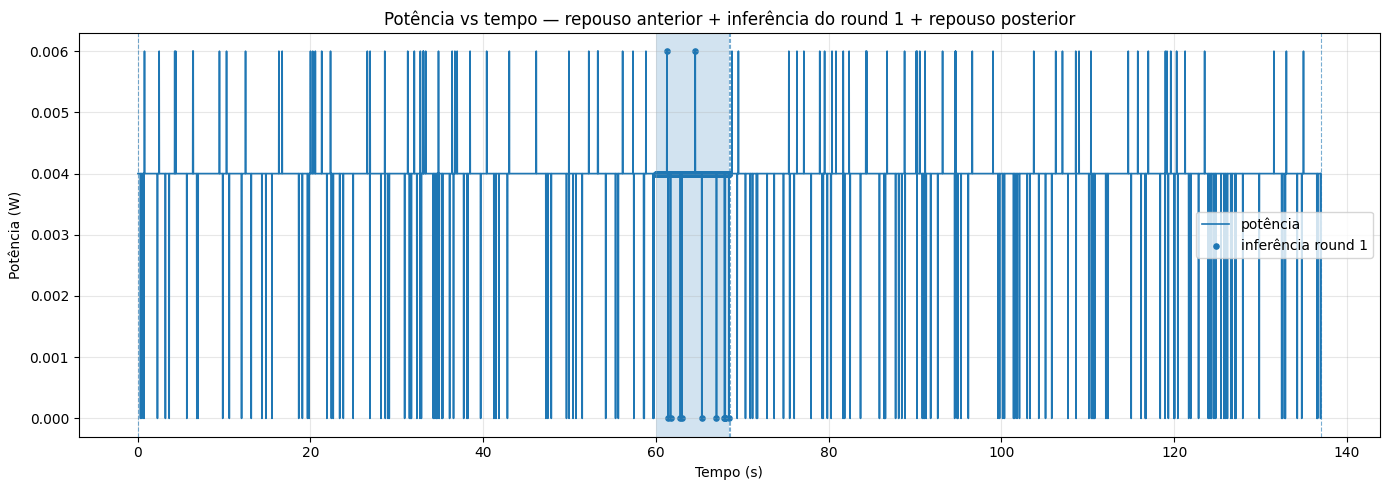

In [12]:
# -*- coding: utf-8 -*-
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILE_PATH = "/home/clariele/Arduino/tinyMLP/EnergiaINA/resultados_energia/tempo_inferencia_tinyMLP_kd_student_quant.csv"

ROUND_TO_PLOT = 1   # <<< mude aqui: 1, 2, 3, ...


# =========================================================
# LER ARQUIVO
# =========================================================
with open(FILE_PATH, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

header_idx = None
for i, line in enumerate(lines):
    line_clean = line.strip().replace("\t", ",")
    if "tempo_s" in line_clean and "power_W" in line_clean:
        header_idx = i
        break

if header_idx is None:
    raise ValueError("Cabeçalho não encontrado.")

data_lines = ["tempo_s,power_W,inferindo,round,phase,bus_V,current_mA"]
summary_rows = []

for line in lines[header_idx + 1:]:
    line_clean = line.strip()

    if not line_clean:
        continue

    if line_clean.startswith("SUMMARY_HEADER"):
        continue

    if line_clean.startswith("SUMMARY"):
        line_clean = line_clean.replace("\t", ",")
        parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]
        if len(parts) >= 6 and parts[0] == "SUMMARY":
            summary_rows.append(parts[:6])
        continue

    line_clean = line_clean.replace("\t", ",")
    parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]

    if len(parts) >= 7:
        try:
            float(parts[0])      # tempo_s
            float(parts[1])      # power_W
            int(float(parts[2])) # inferindo
            data_lines.append(",".join(parts[:7]))
        except:
            pass

df = pd.read_csv(io.StringIO("\n".join(data_lines)))

for col in ["tempo_s", "power_W", "inferindo", "round", "bus_V", "current_mA"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["tempo_s", "power_W", "round"]).copy()
df["round"] = df["round"].astype(int)
df["inferindo"] = df["inferindo"].fillna(0).astype(int)
df = df.sort_values(["tempo_s"]).reset_index(drop=True)

# =========================================================
# SUMMARY
# =========================================================
if summary_rows:
    df_summary = pd.DataFrame(
        summary_rows,
        columns=["tag", "round", "phase", "reps", "total_us", "avg_us"]
    )
    for col in ["round", "reps", "total_us", "avg_us"]:
        df_summary[col] = pd.to_numeric(df_summary[col], errors="coerce")
    df_summary["duracao_s_summary"] = df_summary["total_us"] / 1e6
else:
    df_summary = pd.DataFrame(columns=["round", "phase", "reps", "total_us", "avg_us", "duracao_s_summary"])


# =========================================================
# DETECTAR INTERVALOS DE INFERÊNCIA GLOBAIS
# =========================================================
def detect_intervals(df_):
    infer = df_["inferindo"].values

    infer_prev = np.r_[0, infer[:-1]]
    infer_next = np.r_[infer[1:], 0]

    starts = np.where((infer == 1) & (infer_prev == 0))[0]
    ends   = np.where((infer == 1) & (infer_next == 0))[0]

    return list(zip(starts, ends))


intervals = detect_intervals(df)

# =========================================================
# TABELA COMPLETA DE TODOS OS ROUNDS
# =========================================================
rows = []

for idx, (i0, i1) in enumerate(intervals, start=1):
    df_seg = df.iloc[i0:i1+1].copy()

    round_vals = df_seg["round"].dropna().unique()
    round_id = int(round_vals[0]) if len(round_vals) > 0 else idx

    ts = df_seg["tempo_s"].values
    ps = df_seg["power_W"].values

    # baseline = média do repouso do mesmo round
    df_round = df[df["round"] == round_id].copy()
    rest_vals = df_round[df_round["inferindo"] == 0]["power_W"].values

    if len(rest_vals) == 0:
        baseline = np.nan
    else:
        baseline = np.mean(rest_vals)

    ps_excess = np.maximum(ps - baseline, 0) if np.isfinite(baseline) else ps
    energia_J = np.trapz(ps_excess, ts)

    # tempo da inferência: prioriza SUMMARY
    dur_summary = np.nan
    tmp = df_summary[df_summary["round"] == round_id]
    if not tmp.empty:
        dur_summary = tmp["duracao_s_summary"].iloc[0]

    dur_series = ts[-1] - ts[0] if len(ts) > 1 else 0.0
    duracao_s = dur_summary if np.isfinite(dur_summary) else dur_series

    rows.append({
        "round": round_id,
        "duracao_s": duracao_s,
        "baseline_W": baseline,
        "energia_J": energia_J,
        "energia_mWh": energia_J / 3600.0 * 1000.0
    })

df_results = pd.DataFrame(rows).sort_values("round").reset_index(drop=True)

print("\nTABELA COMPLETA - TODOS OS ROUNDS\n")
with pd.option_context("display.max_rows", None, "display.float_format", lambda x: f"{x:.6f}"):
    print(df_results.to_string(index=False))

print("\nMÉDIAS GERAIS\n")
print(f"Tempo médio de inferência (s): {df_results['duracao_s'].mean():.6f}")
print(f"Energia média de inferência (J): {df_results['energia_J'].mean():.6f}")
print(f"Energia média de inferência (mWh): {df_results['energia_mWh'].mean():.6f}")


# =========================================================
# GRÁFICO: REPOUSO ANTERIOR + INFERÊNCIA + REPOUSO POSTERIOR
# =========================================================
all_rounds = sorted(df["round"].dropna().unique())

if ROUND_TO_PLOT not in all_rounds:
    raise ValueError(f"Round {ROUND_TO_PLOT} não encontrado.")

prev_round = ROUND_TO_PLOT - 1 if (ROUND_TO_PLOT - 1) in all_rounds else None
next_round = ROUND_TO_PLOT + 1 if (ROUND_TO_PLOT + 1) in all_rounds else None

rounds_for_plot = []
if prev_round is not None:
    rounds_for_plot.append(prev_round)
rounds_for_plot.append(ROUND_TO_PLOT)
if next_round is not None:
    rounds_for_plot.append(next_round)

df_plot = df[df["round"].isin(rounds_for_plot)].copy().sort_values("tempo_s")

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_plot["tempo_s"], df_plot["power_W"], linewidth=1.2, label="potência")

# destacar somente a inferência do round escolhido
df_inf_target = df[(df["round"] == ROUND_TO_PLOT) & (df["inferindo"] == 1)].copy()

if not df_inf_target.empty:
    ax.scatter(
        df_inf_target["tempo_s"],
        df_inf_target["power_W"],
        s=14,
        label=f"inferência round {ROUND_TO_PLOT}"
    )

    t0 = df_inf_target["tempo_s"].min()
    t1 = df_inf_target["tempo_s"].max()
    ax.axvspan(t0, t1, alpha=0.20)

# linhas verticais para separar rounds
for r in rounds_for_plot:
    df_r = df[df["round"] == r]
    if not df_r.empty:
        ax.axvline(df_r["tempo_s"].min(), linestyle="--", linewidth=0.8, alpha=0.6)
        ax.axvline(df_r["tempo_s"].max(), linestyle="--", linewidth=0.8, alpha=0.6)

ax.set_title(
    f"Potência vs tempo — repouso anterior + inferência do round {ROUND_TO_PLOT} + repouso posterior"
)
ax.set_xlabel("Tempo (s)")
ax.set_ylabel("Potência (W)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## GRÁFICO MLP PODA


TABELA COMPLETA - TODOS OS ROUNDS

 round  duracao_s  baseline_W  energia_J  energia_mWh
     1  10.420464    0.003911   0.000968     0.000269
     2  10.354628    0.003903   0.001298     0.000361
     3  10.382611    0.003915   0.001132     0.000314
     4  10.429819    0.003907   0.001206     0.000335
     5  10.432600    0.003907   0.001094     0.000304
     6  10.398817    0.003914   0.000940     0.000261
     7  10.380675    0.003929   0.000978     0.000272
     8  10.441671    0.003929   0.000871     0.000242
     9  10.437549    0.003906   0.001111     0.000309
    10  10.423291    0.003912   0.001083     0.000301

MÉDIAS GERAIS

Tempo médio de inferência (s): 10.410213
Energia média de inferência (J): 0.001068
Energia média de inferência (mWh): 0.000297


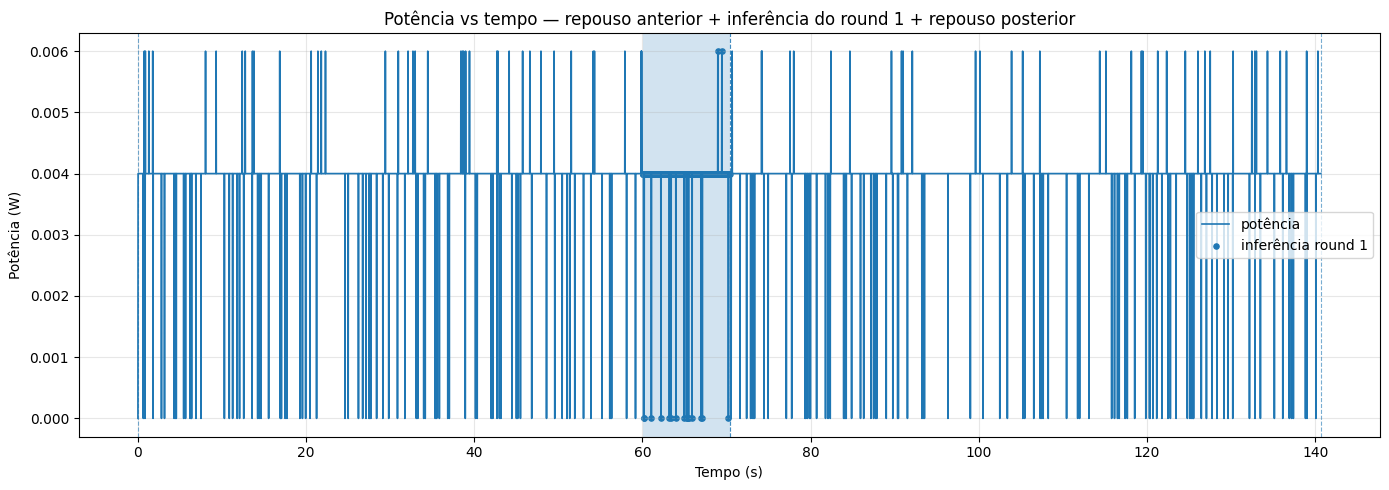

In [13]:
# -*- coding: utf-8 -*-
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILE_PATH = "/home/clariele/Arduino/tinyMLP/EnergiaINA/resultados_energia/tempo_inferencia_tinyMLP_poda.csv"

ROUND_TO_PLOT = 1   # <<< mude aqui: 1, 2, 3, ...


# =========================================================
# LER ARQUIVO
# =========================================================
with open(FILE_PATH, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

header_idx = None
for i, line in enumerate(lines):
    line_clean = line.strip().replace("\t", ",")
    if "tempo_s" in line_clean and "power_W" in line_clean:
        header_idx = i
        break

if header_idx is None:
    raise ValueError("Cabeçalho não encontrado.")

data_lines = ["tempo_s,power_W,inferindo,round,phase,bus_V,current_mA"]
summary_rows = []

for line in lines[header_idx + 1:]:
    line_clean = line.strip()

    if not line_clean:
        continue

    if line_clean.startswith("SUMMARY_HEADER"):
        continue

    if line_clean.startswith("SUMMARY"):
        line_clean = line_clean.replace("\t", ",")
        parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]
        if len(parts) >= 6 and parts[0] == "SUMMARY":
            summary_rows.append(parts[:6])
        continue

    line_clean = line_clean.replace("\t", ",")
    parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]

    if len(parts) >= 7:
        try:
            float(parts[0])      # tempo_s
            float(parts[1])      # power_W
            int(float(parts[2])) # inferindo
            data_lines.append(",".join(parts[:7]))
        except:
            pass

df = pd.read_csv(io.StringIO("\n".join(data_lines)))

for col in ["tempo_s", "power_W", "inferindo", "round", "bus_V", "current_mA"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["tempo_s", "power_W", "round"]).copy()
df["round"] = df["round"].astype(int)
df["inferindo"] = df["inferindo"].fillna(0).astype(int)
df = df.sort_values(["tempo_s"]).reset_index(drop=True)

# =========================================================
# SUMMARY
# =========================================================
if summary_rows:
    df_summary = pd.DataFrame(
        summary_rows,
        columns=["tag", "round", "phase", "reps", "total_us", "avg_us"]
    )
    for col in ["round", "reps", "total_us", "avg_us"]:
        df_summary[col] = pd.to_numeric(df_summary[col], errors="coerce")
    df_summary["duracao_s_summary"] = df_summary["total_us"] / 1e6
else:
    df_summary = pd.DataFrame(columns=["round", "phase", "reps", "total_us", "avg_us", "duracao_s_summary"])


# =========================================================
# DETECTAR INTERVALOS DE INFERÊNCIA GLOBAIS
# =========================================================
def detect_intervals(df_):
    infer = df_["inferindo"].values

    infer_prev = np.r_[0, infer[:-1]]
    infer_next = np.r_[infer[1:], 0]

    starts = np.where((infer == 1) & (infer_prev == 0))[0]
    ends   = np.where((infer == 1) & (infer_next == 0))[0]

    return list(zip(starts, ends))


intervals = detect_intervals(df)

# =========================================================
# TABELA COMPLETA DE TODOS OS ROUNDS
# =========================================================
rows = []

for idx, (i0, i1) in enumerate(intervals, start=1):
    df_seg = df.iloc[i0:i1+1].copy()

    round_vals = df_seg["round"].dropna().unique()
    round_id = int(round_vals[0]) if len(round_vals) > 0 else idx

    ts = df_seg["tempo_s"].values
    ps = df_seg["power_W"].values

    # baseline = média do repouso do mesmo round
    df_round = df[df["round"] == round_id].copy()
    rest_vals = df_round[df_round["inferindo"] == 0]["power_W"].values

    if len(rest_vals) == 0:
        baseline = np.nan
    else:
        baseline = np.mean(rest_vals)

    ps_excess = np.maximum(ps - baseline, 0) if np.isfinite(baseline) else ps
    energia_J = np.trapz(ps_excess, ts)

    # tempo da inferência: prioriza SUMMARY
    dur_summary = np.nan
    tmp = df_summary[df_summary["round"] == round_id]
    if not tmp.empty:
        dur_summary = tmp["duracao_s_summary"].iloc[0]

    dur_series = ts[-1] - ts[0] if len(ts) > 1 else 0.0
    duracao_s = dur_summary if np.isfinite(dur_summary) else dur_series

    rows.append({
        "round": round_id,
        "duracao_s": duracao_s,
        "baseline_W": baseline,
        "energia_J": energia_J,
        "energia_mWh": energia_J / 3600.0 * 1000.0
    })

df_results = pd.DataFrame(rows).sort_values("round").reset_index(drop=True)

print("\nTABELA COMPLETA - TODOS OS ROUNDS\n")
with pd.option_context("display.max_rows", None, "display.float_format", lambda x: f"{x:.6f}"):
    print(df_results.to_string(index=False))

print("\nMÉDIAS GERAIS\n")
print(f"Tempo médio de inferência (s): {df_results['duracao_s'].mean():.6f}")
print(f"Energia média de inferência (J): {df_results['energia_J'].mean():.6f}")
print(f"Energia média de inferência (mWh): {df_results['energia_mWh'].mean():.6f}")


# =========================================================
# GRÁFICO: REPOUSO ANTERIOR + INFERÊNCIA + REPOUSO POSTERIOR
# =========================================================
all_rounds = sorted(df["round"].dropna().unique())

if ROUND_TO_PLOT not in all_rounds:
    raise ValueError(f"Round {ROUND_TO_PLOT} não encontrado.")

prev_round = ROUND_TO_PLOT - 1 if (ROUND_TO_PLOT - 1) in all_rounds else None
next_round = ROUND_TO_PLOT + 1 if (ROUND_TO_PLOT + 1) in all_rounds else None

rounds_for_plot = []
if prev_round is not None:
    rounds_for_plot.append(prev_round)
rounds_for_plot.append(ROUND_TO_PLOT)
if next_round is not None:
    rounds_for_plot.append(next_round)

df_plot = df[df["round"].isin(rounds_for_plot)].copy().sort_values("tempo_s")

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_plot["tempo_s"], df_plot["power_W"], linewidth=1.2, label="potência")

# destacar somente a inferência do round escolhido
df_inf_target = df[(df["round"] == ROUND_TO_PLOT) & (df["inferindo"] == 1)].copy()

if not df_inf_target.empty:
    ax.scatter(
        df_inf_target["tempo_s"],
        df_inf_target["power_W"],
        s=14,
        label=f"inferência round {ROUND_TO_PLOT}"
    )

    t0 = df_inf_target["tempo_s"].min()
    t1 = df_inf_target["tempo_s"].max()
    ax.axvspan(t0, t1, alpha=0.20)

# linhas verticais para separar rounds
for r in rounds_for_plot:
    df_r = df[df["round"] == r]
    if not df_r.empty:
        ax.axvline(df_r["tempo_s"].min(), linestyle="--", linewidth=0.8, alpha=0.6)
        ax.axvline(df_r["tempo_s"].max(), linestyle="--", linewidth=0.8, alpha=0.6)

ax.set_title(
    f"Potência vs tempo — repouso anterior + inferência do round {ROUND_TO_PLOT} + repouso posterior"
)
ax.set_xlabel("Tempo (s)")
ax.set_ylabel("Potência (W)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## GRÁFICOS DO KD APÓS AJUSTE 


TABELA COMPLETA - TODOS OS ROUNDS

 round  duracao_s  baseline_W  energia_J  energia_mWh
     1  15.378964    0.003957   0.001168     0.000325
     2  15.389237    0.003961   0.001149     0.000319
     3  15.360610    0.003969   0.000980     0.000272
     4  15.353330    0.003947   0.001164     0.000323
     5  15.393190    0.003965   0.000850     0.000236
     6  15.373242    0.003970   0.000931     0.000259
     7  15.333929    0.003955   0.001064     0.000295
     8  15.371488    0.003979   0.000799     0.000222
     9  15.366061    0.003955   0.001189     0.000330
    10  15.364693    0.003968   0.001116     0.000310

MÉDIAS GERAIS

Tempo médio de inferência (s): 15.368474
Energia média de inferência (J): 0.001041
Energia média de inferência (mWh): 0.000289


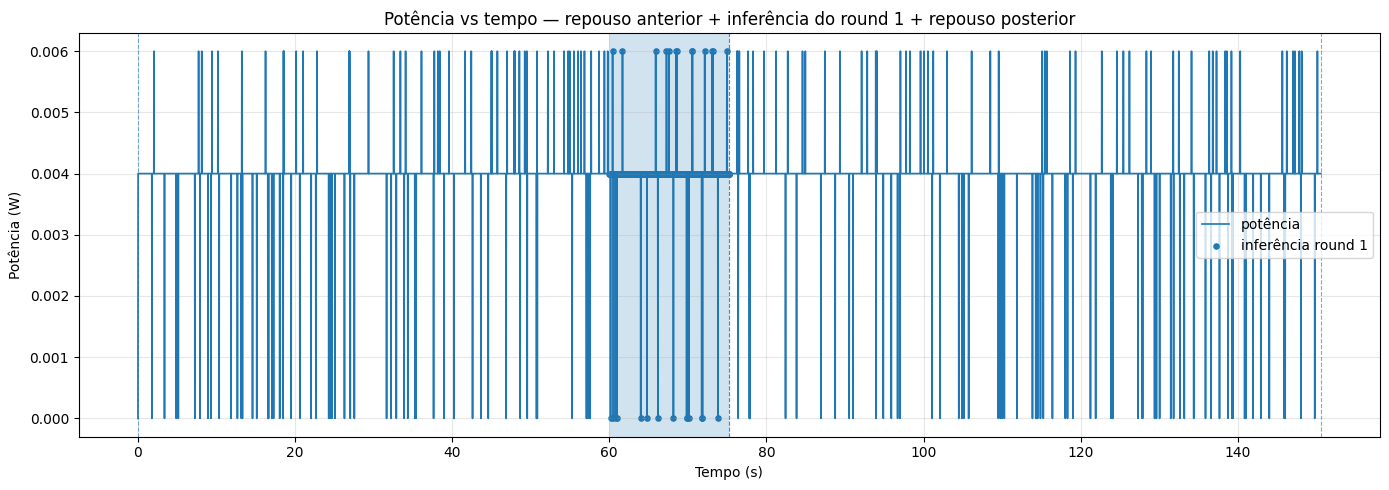

In [16]:
# -*- coding: utf-8 -*-
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILE_PATH = "/home/clariele/Arduino/tinyMLP/EnergiaINA/resultados_energia/kd_ajustado/tempo_inferencia_tinyMLP_kd_teacher_ajustado.csv"

ROUND_TO_PLOT = 1   # <<< mude aqui: 1, 2, 3, ...


# =========================================================
# LER ARQUIVO
# =========================================================
with open(FILE_PATH, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

header_idx = None
for i, line in enumerate(lines):
    line_clean = line.strip().replace("\t", ",")
    if "tempo_s" in line_clean and "power_W" in line_clean:
        header_idx = i
        break

if header_idx is None:
    raise ValueError("Cabeçalho não encontrado.")

data_lines = ["tempo_s,power_W,inferindo,round,phase,bus_V,current_mA"]
summary_rows = []

for line in lines[header_idx + 1:]:
    line_clean = line.strip()

    if not line_clean:
        continue

    if line_clean.startswith("SUMMARY_HEADER"):
        continue

    if line_clean.startswith("SUMMARY"):
        line_clean = line_clean.replace("\t", ",")
        parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]
        if len(parts) >= 6 and parts[0] == "SUMMARY":
            summary_rows.append(parts[:6])
        continue

    line_clean = line_clean.replace("\t", ",")
    parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]

    if len(parts) >= 7:
        try:
            float(parts[0])      # tempo_s
            float(parts[1])      # power_W
            int(float(parts[2])) # inferindo
            data_lines.append(",".join(parts[:7]))
        except:
            pass

df = pd.read_csv(io.StringIO("\n".join(data_lines)))

for col in ["tempo_s", "power_W", "inferindo", "round", "bus_V", "current_mA"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["tempo_s", "power_W", "round"]).copy()
df["round"] = df["round"].astype(int)
df["inferindo"] = df["inferindo"].fillna(0).astype(int)
df = df.sort_values(["tempo_s"]).reset_index(drop=True)

# =========================================================
# SUMMARY
# =========================================================
if summary_rows:
    df_summary = pd.DataFrame(
        summary_rows,
        columns=["tag", "round", "phase", "reps", "total_us", "avg_us"]
    )
    for col in ["round", "reps", "total_us", "avg_us"]:
        df_summary[col] = pd.to_numeric(df_summary[col], errors="coerce")
    df_summary["duracao_s_summary"] = df_summary["total_us"] / 1e6
else:
    df_summary = pd.DataFrame(columns=["round", "phase", "reps", "total_us", "avg_us", "duracao_s_summary"])


# =========================================================
# DETECTAR INTERVALOS DE INFERÊNCIA GLOBAIS
# =========================================================
def detect_intervals(df_):
    infer = df_["inferindo"].values

    infer_prev = np.r_[0, infer[:-1]]
    infer_next = np.r_[infer[1:], 0]

    starts = np.where((infer == 1) & (infer_prev == 0))[0]
    ends   = np.where((infer == 1) & (infer_next == 0))[0]

    return list(zip(starts, ends))


intervals = detect_intervals(df)

# =========================================================
# TABELA COMPLETA DE TODOS OS ROUNDS
# =========================================================
rows = []

for idx, (i0, i1) in enumerate(intervals, start=1):
    df_seg = df.iloc[i0:i1+1].copy()

    round_vals = df_seg["round"].dropna().unique()
    round_id = int(round_vals[0]) if len(round_vals) > 0 else idx

    ts = df_seg["tempo_s"].values
    ps = df_seg["power_W"].values

    # baseline = média do repouso do mesmo round
    df_round = df[df["round"] == round_id].copy()
    rest_vals = df_round[df_round["inferindo"] == 0]["power_W"].values

    if len(rest_vals) == 0:
        baseline = np.nan
    else:
        baseline = np.mean(rest_vals)

    ps_excess = np.maximum(ps - baseline, 0) if np.isfinite(baseline) else ps
    energia_J = np.trapz(ps_excess, ts)

    # tempo da inferência: prioriza SUMMARY
    dur_summary = np.nan
    tmp = df_summary[df_summary["round"] == round_id]
    if not tmp.empty:
        dur_summary = tmp["duracao_s_summary"].iloc[0]

    dur_series = ts[-1] - ts[0] if len(ts) > 1 else 0.0
    duracao_s = dur_summary if np.isfinite(dur_summary) else dur_series

    rows.append({
        "round": round_id,
        "duracao_s": duracao_s,
        "baseline_W": baseline,
        "energia_J": energia_J,
        "energia_mWh": energia_J / 3600.0 * 1000.0
    })

df_results = pd.DataFrame(rows).sort_values("round").reset_index(drop=True)

print("\nTABELA COMPLETA - TODOS OS ROUNDS\n")
with pd.option_context("display.max_rows", None, "display.float_format", lambda x: f"{x:.6f}"):
    print(df_results.to_string(index=False))

print("\nMÉDIAS GERAIS\n")
print(f"Tempo médio de inferência (s): {df_results['duracao_s'].mean():.6f}")
print(f"Energia média de inferência (J): {df_results['energia_J'].mean():.6f}")
print(f"Energia média de inferência (mWh): {df_results['energia_mWh'].mean():.6f}")


# =========================================================
# GRÁFICO: REPOUSO ANTERIOR + INFERÊNCIA + REPOUSO POSTERIOR
# =========================================================
all_rounds = sorted(df["round"].dropna().unique())

if ROUND_TO_PLOT not in all_rounds:
    raise ValueError(f"Round {ROUND_TO_PLOT} não encontrado.")

prev_round = ROUND_TO_PLOT - 1 if (ROUND_TO_PLOT - 1) in all_rounds else None
next_round = ROUND_TO_PLOT + 1 if (ROUND_TO_PLOT + 1) in all_rounds else None

rounds_for_plot = []
if prev_round is not None:
    rounds_for_plot.append(prev_round)
rounds_for_plot.append(ROUND_TO_PLOT)
if next_round is not None:
    rounds_for_plot.append(next_round)

df_plot = df[df["round"].isin(rounds_for_plot)].copy().sort_values("tempo_s")

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_plot["tempo_s"], df_plot["power_W"], linewidth=1.2, label="potência")

# destacar somente a inferência do round escolhido
df_inf_target = df[(df["round"] == ROUND_TO_PLOT) & (df["inferindo"] == 1)].copy()

if not df_inf_target.empty:
    ax.scatter(
        df_inf_target["tempo_s"],
        df_inf_target["power_W"],
        s=14,
        label=f"inferência round {ROUND_TO_PLOT}"
    )

    t0 = df_inf_target["tempo_s"].min()
    t1 = df_inf_target["tempo_s"].max()
    ax.axvspan(t0, t1, alpha=0.20)

# linhas verticais para separar rounds
for r in rounds_for_plot:
    df_r = df[df["round"] == r]
    if not df_r.empty:
        ax.axvline(df_r["tempo_s"].min(), linestyle="--", linewidth=0.8, alpha=0.6)
        ax.axvline(df_r["tempo_s"].max(), linestyle="--", linewidth=0.8, alpha=0.6)

ax.set_title(
    f"Potência vs tempo — repouso anterior + inferência do round {ROUND_TO_PLOT} + repouso posterior"
)
ax.set_xlabel("Tempo (s)")
ax.set_ylabel("Potência (W)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


TABELA COMPLETA - TODOS OS ROUNDS

 round  duracao_s  baseline_W  energia_J  energia_mWh
     1  10.394634    0.003619   0.004103     0.001140
     2  10.443462    0.003853   0.001535     0.000426
     3  10.413317    0.003866   0.001409     0.000391
     4  10.405852    0.003862   0.001528     0.000424
     5  10.443368    0.003869   0.001652     0.000459
     6  10.426985    0.003879   0.001492     0.000414
     7  10.406858    0.003901   0.001187     0.000330
     8  10.439147    0.003894   0.001152     0.000320
     9  10.409422    0.003890   0.001180     0.000328
    10  10.427797    0.003911   0.001171     0.000325

MÉDIAS GERAIS

Tempo médio de inferência (s): 10.421084
Energia média de inferência (J): 0.001641
Energia média de inferência (mWh): 0.000456


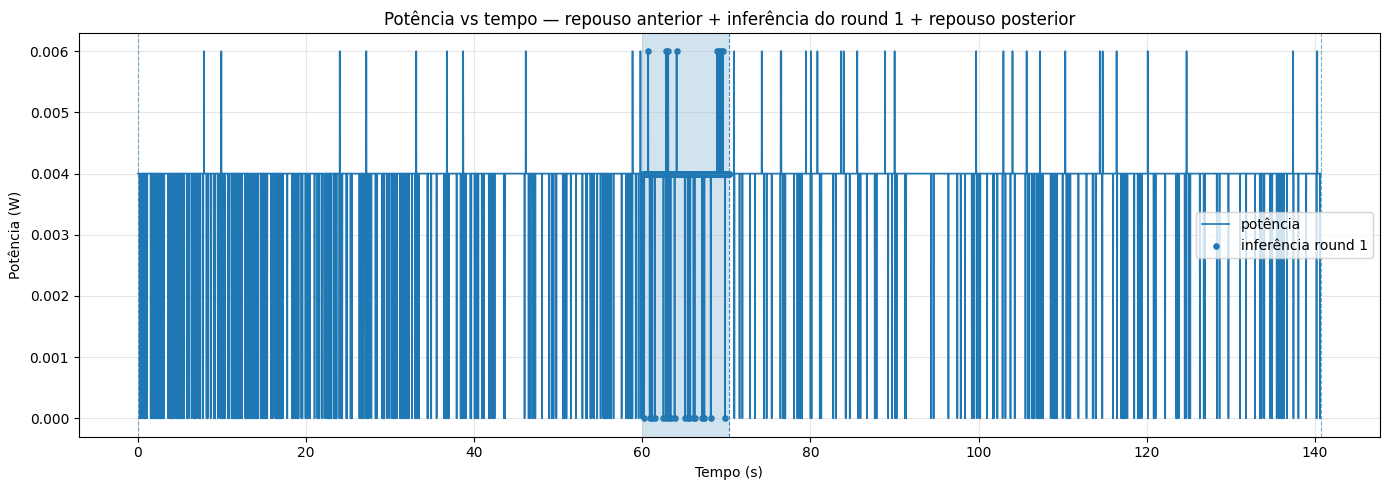

In [17]:
# -*- coding: utf-8 -*-
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILE_PATH = "/home/clariele/Arduino/tinyMLP/EnergiaINA/resultados_energia/kd_ajustado/tempo_inferencia_tinyMLP_kd_student_ajustado.csv"

ROUND_TO_PLOT = 1   # <<< mude aqui: 1, 2, 3, ...


# =========================================================
# LER ARQUIVO
# =========================================================
with open(FILE_PATH, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

header_idx = None
for i, line in enumerate(lines):
    line_clean = line.strip().replace("\t", ",")
    if "tempo_s" in line_clean and "power_W" in line_clean:
        header_idx = i
        break

if header_idx is None:
    raise ValueError("Cabeçalho não encontrado.")

data_lines = ["tempo_s,power_W,inferindo,round,phase,bus_V,current_mA"]
summary_rows = []

for line in lines[header_idx + 1:]:
    line_clean = line.strip()

    if not line_clean:
        continue

    if line_clean.startswith("SUMMARY_HEADER"):
        continue

    if line_clean.startswith("SUMMARY"):
        line_clean = line_clean.replace("\t", ",")
        parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]
        if len(parts) >= 6 and parts[0] == "SUMMARY":
            summary_rows.append(parts[:6])
        continue

    line_clean = line_clean.replace("\t", ",")
    parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]

    if len(parts) >= 7:
        try:
            float(parts[0])      # tempo_s
            float(parts[1])      # power_W
            int(float(parts[2])) # inferindo
            data_lines.append(",".join(parts[:7]))
        except:
            pass

df = pd.read_csv(io.StringIO("\n".join(data_lines)))

for col in ["tempo_s", "power_W", "inferindo", "round", "bus_V", "current_mA"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["tempo_s", "power_W", "round"]).copy()
df["round"] = df["round"].astype(int)
df["inferindo"] = df["inferindo"].fillna(0).astype(int)
df = df.sort_values(["tempo_s"]).reset_index(drop=True)

# =========================================================
# SUMMARY
# =========================================================
if summary_rows:
    df_summary = pd.DataFrame(
        summary_rows,
        columns=["tag", "round", "phase", "reps", "total_us", "avg_us"]
    )
    for col in ["round", "reps", "total_us", "avg_us"]:
        df_summary[col] = pd.to_numeric(df_summary[col], errors="coerce")
    df_summary["duracao_s_summary"] = df_summary["total_us"] / 1e6
else:
    df_summary = pd.DataFrame(columns=["round", "phase", "reps", "total_us", "avg_us", "duracao_s_summary"])


# =========================================================
# DETECTAR INTERVALOS DE INFERÊNCIA GLOBAIS
# =========================================================
def detect_intervals(df_):
    infer = df_["inferindo"].values

    infer_prev = np.r_[0, infer[:-1]]
    infer_next = np.r_[infer[1:], 0]

    starts = np.where((infer == 1) & (infer_prev == 0))[0]
    ends   = np.where((infer == 1) & (infer_next == 0))[0]

    return list(zip(starts, ends))


intervals = detect_intervals(df)

# =========================================================
# TABELA COMPLETA DE TODOS OS ROUNDS
# =========================================================
rows = []

for idx, (i0, i1) in enumerate(intervals, start=1):
    df_seg = df.iloc[i0:i1+1].copy()

    round_vals = df_seg["round"].dropna().unique()
    round_id = int(round_vals[0]) if len(round_vals) > 0 else idx

    ts = df_seg["tempo_s"].values
    ps = df_seg["power_W"].values

    # baseline = média do repouso do mesmo round
    df_round = df[df["round"] == round_id].copy()
    rest_vals = df_round[df_round["inferindo"] == 0]["power_W"].values

    if len(rest_vals) == 0:
        baseline = np.nan
    else:
        baseline = np.mean(rest_vals)

    ps_excess = np.maximum(ps - baseline, 0) if np.isfinite(baseline) else ps
    energia_J = np.trapz(ps_excess, ts)

    # tempo da inferência: prioriza SUMMARY
    dur_summary = np.nan
    tmp = df_summary[df_summary["round"] == round_id]
    if not tmp.empty:
        dur_summary = tmp["duracao_s_summary"].iloc[0]

    dur_series = ts[-1] - ts[0] if len(ts) > 1 else 0.0
    duracao_s = dur_summary if np.isfinite(dur_summary) else dur_series

    rows.append({
        "round": round_id,
        "duracao_s": duracao_s,
        "baseline_W": baseline,
        "energia_J": energia_J,
        "energia_mWh": energia_J / 3600.0 * 1000.0
    })

df_results = pd.DataFrame(rows).sort_values("round").reset_index(drop=True)

print("\nTABELA COMPLETA - TODOS OS ROUNDS\n")
with pd.option_context("display.max_rows", None, "display.float_format", lambda x: f"{x:.6f}"):
    print(df_results.to_string(index=False))

print("\nMÉDIAS GERAIS\n")
print(f"Tempo médio de inferência (s): {df_results['duracao_s'].mean():.6f}")
print(f"Energia média de inferência (J): {df_results['energia_J'].mean():.6f}")
print(f"Energia média de inferência (mWh): {df_results['energia_mWh'].mean():.6f}")


# =========================================================
# GRÁFICO: REPOUSO ANTERIOR + INFERÊNCIA + REPOUSO POSTERIOR
# =========================================================
all_rounds = sorted(df["round"].dropna().unique())

if ROUND_TO_PLOT not in all_rounds:
    raise ValueError(f"Round {ROUND_TO_PLOT} não encontrado.")

prev_round = ROUND_TO_PLOT - 1 if (ROUND_TO_PLOT - 1) in all_rounds else None
next_round = ROUND_TO_PLOT + 1 if (ROUND_TO_PLOT + 1) in all_rounds else None

rounds_for_plot = []
if prev_round is not None:
    rounds_for_plot.append(prev_round)
rounds_for_plot.append(ROUND_TO_PLOT)
if next_round is not None:
    rounds_for_plot.append(next_round)

df_plot = df[df["round"].isin(rounds_for_plot)].copy().sort_values("tempo_s")

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_plot["tempo_s"], df_plot["power_W"], linewidth=1.2, label="potência")

# destacar somente a inferência do round escolhido
df_inf_target = df[(df["round"] == ROUND_TO_PLOT) & (df["inferindo"] == 1)].copy()

if not df_inf_target.empty:
    ax.scatter(
        df_inf_target["tempo_s"],
        df_inf_target["power_W"],
        s=14,
        label=f"inferência round {ROUND_TO_PLOT}"
    )

    t0 = df_inf_target["tempo_s"].min()
    t1 = df_inf_target["tempo_s"].max()
    ax.axvspan(t0, t1, alpha=0.20)

# linhas verticais para separar rounds
for r in rounds_for_plot:
    df_r = df[df["round"] == r]
    if not df_r.empty:
        ax.axvline(df_r["tempo_s"].min(), linestyle="--", linewidth=0.8, alpha=0.6)
        ax.axvline(df_r["tempo_s"].max(), linestyle="--", linewidth=0.8, alpha=0.6)

ax.set_title(
    f"Potência vs tempo — repouso anterior + inferência do round {ROUND_TO_PLOT} + repouso posterior"
)
ax.set_xlabel("Tempo (s)")
ax.set_ylabel("Potência (W)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


TABELA COMPLETA - TODOS OS ROUNDS

 round  duracao_s  baseline_W  energia_J  energia_mWh
     1   8.536553    0.003928   0.000790     0.000220
     2   8.537168    0.003875   0.001347     0.000374
     3   8.505243    0.003913   0.000869     0.000241
     4   8.504304    0.003908   0.000911     0.000253
     5   8.514970    0.003921   0.000927     0.000257
     6   8.516487    0.003895   0.000988     0.000274
     7   8.520544    0.003928   0.000670     0.000186
     8   8.523496    0.003892   0.001329     0.000369
     9   8.496950    0.003908   0.000872     0.000242
    10   8.538896    0.003907   0.000928     0.000258

MÉDIAS GERAIS

Tempo médio de inferência (s): 8.519461
Energia média de inferência (J): 0.000963
Energia média de inferência (mWh): 0.000268


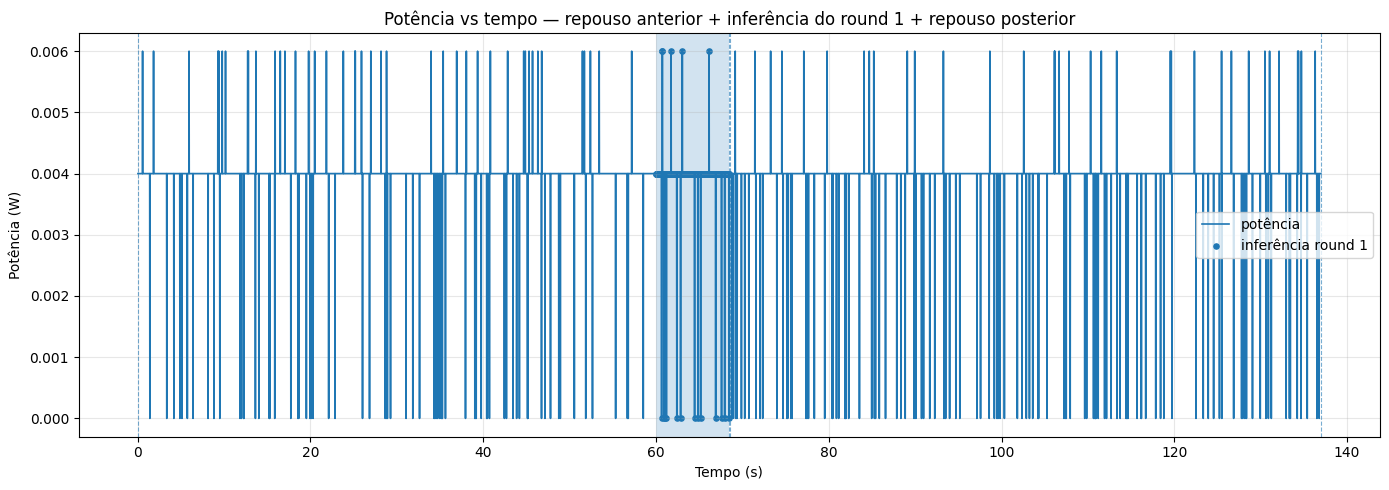

In [18]:
# -*- coding: utf-8 -*-
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILE_PATH = "/home/clariele/Arduino/tinyMLP/EnergiaINA/resultados_energia/kd_ajustado/tempo_inferencia_tinyMLP_kd_student_quant_ajustado.csv"

ROUND_TO_PLOT = 1   # <<< mude aqui: 1, 2, 3, ...


# =========================================================
# LER ARQUIVO
# =========================================================
with open(FILE_PATH, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

header_idx = None
for i, line in enumerate(lines):
    line_clean = line.strip().replace("\t", ",")
    if "tempo_s" in line_clean and "power_W" in line_clean:
        header_idx = i
        break

if header_idx is None:
    raise ValueError("Cabeçalho não encontrado.")

data_lines = ["tempo_s,power_W,inferindo,round,phase,bus_V,current_mA"]
summary_rows = []

for line in lines[header_idx + 1:]:
    line_clean = line.strip()

    if not line_clean:
        continue

    if line_clean.startswith("SUMMARY_HEADER"):
        continue

    if line_clean.startswith("SUMMARY"):
        line_clean = line_clean.replace("\t", ",")
        parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]
        if len(parts) >= 6 and parts[0] == "SUMMARY":
            summary_rows.append(parts[:6])
        continue

    line_clean = line_clean.replace("\t", ",")
    parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]

    if len(parts) >= 7:
        try:
            float(parts[0])      # tempo_s
            float(parts[1])      # power_W
            int(float(parts[2])) # inferindo
            data_lines.append(",".join(parts[:7]))
        except:
            pass

df = pd.read_csv(io.StringIO("\n".join(data_lines)))

for col in ["tempo_s", "power_W", "inferindo", "round", "bus_V", "current_mA"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["tempo_s", "power_W", "round"]).copy()
df["round"] = df["round"].astype(int)
df["inferindo"] = df["inferindo"].fillna(0).astype(int)
df = df.sort_values(["tempo_s"]).reset_index(drop=True)

# =========================================================
# SUMMARY
# =========================================================
if summary_rows:
    df_summary = pd.DataFrame(
        summary_rows,
        columns=["tag", "round", "phase", "reps", "total_us", "avg_us"]
    )
    for col in ["round", "reps", "total_us", "avg_us"]:
        df_summary[col] = pd.to_numeric(df_summary[col], errors="coerce")
    df_summary["duracao_s_summary"] = df_summary["total_us"] / 1e6
else:
    df_summary = pd.DataFrame(columns=["round", "phase", "reps", "total_us", "avg_us", "duracao_s_summary"])


# =========================================================
# DETECTAR INTERVALOS DE INFERÊNCIA GLOBAIS
# =========================================================
def detect_intervals(df_):
    infer = df_["inferindo"].values

    infer_prev = np.r_[0, infer[:-1]]
    infer_next = np.r_[infer[1:], 0]

    starts = np.where((infer == 1) & (infer_prev == 0))[0]
    ends   = np.where((infer == 1) & (infer_next == 0))[0]

    return list(zip(starts, ends))


intervals = detect_intervals(df)

# =========================================================
# TABELA COMPLETA DE TODOS OS ROUNDS
# =========================================================
rows = []

for idx, (i0, i1) in enumerate(intervals, start=1):
    df_seg = df.iloc[i0:i1+1].copy()

    round_vals = df_seg["round"].dropna().unique()
    round_id = int(round_vals[0]) if len(round_vals) > 0 else idx

    ts = df_seg["tempo_s"].values
    ps = df_seg["power_W"].values

    # baseline = média do repouso do mesmo round
    df_round = df[df["round"] == round_id].copy()
    rest_vals = df_round[df_round["inferindo"] == 0]["power_W"].values

    if len(rest_vals) == 0:
        baseline = np.nan
    else:
        baseline = np.mean(rest_vals)

    ps_excess = np.maximum(ps - baseline, 0) if np.isfinite(baseline) else ps
    energia_J = np.trapz(ps_excess, ts)

    # tempo da inferência: prioriza SUMMARY
    dur_summary = np.nan
    tmp = df_summary[df_summary["round"] == round_id]
    if not tmp.empty:
        dur_summary = tmp["duracao_s_summary"].iloc[0]

    dur_series = ts[-1] - ts[0] if len(ts) > 1 else 0.0
    duracao_s = dur_summary if np.isfinite(dur_summary) else dur_series

    rows.append({
        "round": round_id,
        "duracao_s": duracao_s,
        "baseline_W": baseline,
        "energia_J": energia_J,
        "energia_mWh": energia_J / 3600.0 * 1000.0
    })

df_results = pd.DataFrame(rows).sort_values("round").reset_index(drop=True)

print("\nTABELA COMPLETA - TODOS OS ROUNDS\n")
with pd.option_context("display.max_rows", None, "display.float_format", lambda x: f"{x:.6f}"):
    print(df_results.to_string(index=False))

print("\nMÉDIAS GERAIS\n")
print(f"Tempo médio de inferência (s): {df_results['duracao_s'].mean():.6f}")
print(f"Energia média de inferência (J): {df_results['energia_J'].mean():.6f}")
print(f"Energia média de inferência (mWh): {df_results['energia_mWh'].mean():.6f}")


# =========================================================
# GRÁFICO: REPOUSO ANTERIOR + INFERÊNCIA + REPOUSO POSTERIOR
# =========================================================
all_rounds = sorted(df["round"].dropna().unique())

if ROUND_TO_PLOT not in all_rounds:
    raise ValueError(f"Round {ROUND_TO_PLOT} não encontrado.")

prev_round = ROUND_TO_PLOT - 1 if (ROUND_TO_PLOT - 1) in all_rounds else None
next_round = ROUND_TO_PLOT + 1 if (ROUND_TO_PLOT + 1) in all_rounds else None

rounds_for_plot = []
if prev_round is not None:
    rounds_for_plot.append(prev_round)
rounds_for_plot.append(ROUND_TO_PLOT)
if next_round is not None:
    rounds_for_plot.append(next_round)

df_plot = df[df["round"].isin(rounds_for_plot)].copy().sort_values("tempo_s")

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_plot["tempo_s"], df_plot["power_W"], linewidth=1.2, label="potência")

# destacar somente a inferência do round escolhido
df_inf_target = df[(df["round"] == ROUND_TO_PLOT) & (df["inferindo"] == 1)].copy()

if not df_inf_target.empty:
    ax.scatter(
        df_inf_target["tempo_s"],
        df_inf_target["power_W"],
        s=14,
        label=f"inferência round {ROUND_TO_PLOT}"
    )

    t0 = df_inf_target["tempo_s"].min()
    t1 = df_inf_target["tempo_s"].max()
    ax.axvspan(t0, t1, alpha=0.20)

# linhas verticais para separar rounds
for r in rounds_for_plot:
    df_r = df[df["round"] == r]
    if not df_r.empty:
        ax.axvline(df_r["tempo_s"].min(), linestyle="--", linewidth=0.8, alpha=0.6)
        ax.axvline(df_r["tempo_s"].max(), linestyle="--", linewidth=0.8, alpha=0.6)

ax.set_title(
    f"Potência vs tempo — repouso anterior + inferência do round {ROUND_TO_PLOT} + repouso posterior"
)
ax.set_xlabel("Tempo (s)")
ax.set_ylabel("Potência (W)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## MEDIÇÃO 2

## PURO 2


TABELA COMPLETA - TODOS OS ROUNDS

 round  duracao_s  baseline_W  energia_J  energia_mWh
     1  21.765057    0.003558   0.006555     0.001821
     2  21.757998    0.003601   0.006229     0.001730
     3  21.757159    0.003604   0.005783     0.001606
     4  21.777064    0.003588   0.006298     0.001749
     5  21.840133    0.003614   0.006353     0.001765
     6  21.845961    0.003624   0.006061     0.001684
     7  21.808153    0.003621   0.005939     0.001650
     8  21.790696    0.003592   0.006240     0.001733
     9  21.756436    0.003610   0.006085     0.001690
    10  21.776249    0.003563   0.006434     0.001787

MÉDIAS GERAIS

Tempo médio de inferência (s): 21.787491
Energia média de inferência (J): 0.006198
Energia média de inferência (mWh): 0.001722


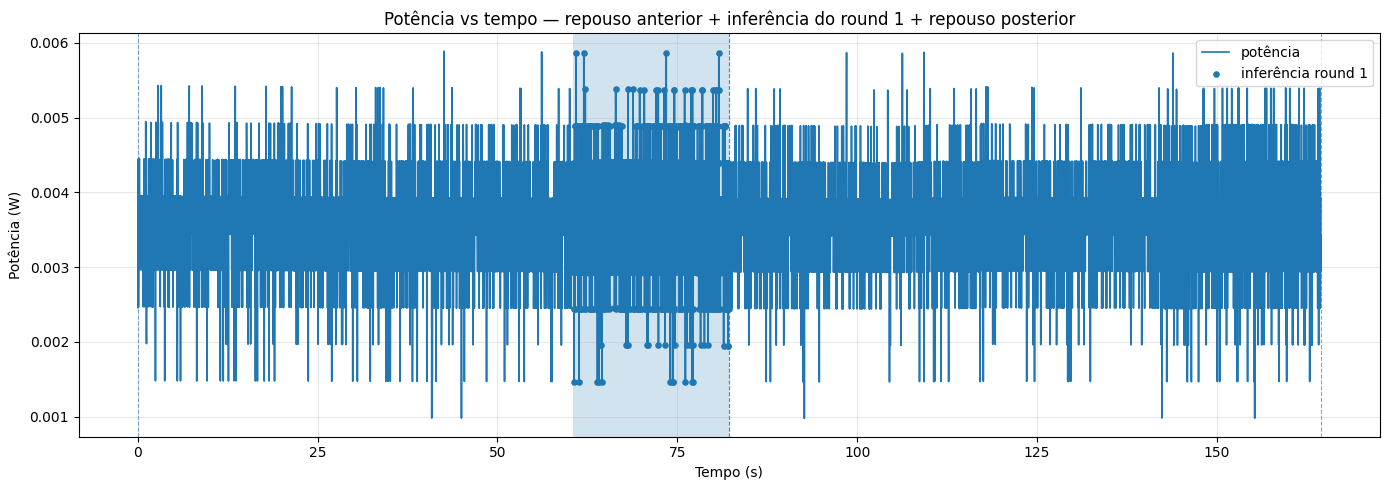

In [3]:
# -*- coding: utf-8 -*-
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILE_PATH = "/home/clariele/Arduino/tinyMLP/EnergiaINA/resuldados_energia_2/tempo_inferencia_tinyMLP_puro.csv"

ROUND_TO_PLOT = 1   # <<< mude aqui: 1, 2, 3, ...


# =========================================================
# LER ARQUIVO
# =========================================================
with open(FILE_PATH, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

header_idx = None
for i, line in enumerate(lines):
    line_clean = line.strip().replace("\t", ",")
    if "tempo_s" in line_clean and "power_W" in line_clean:
        header_idx = i
        break

if header_idx is None:
    raise ValueError("Cabeçalho não encontrado.")

data_lines = ["tempo_s,power_W,inferindo,round,phase,bus_V,current_mA"]
summary_rows = []

for line in lines[header_idx + 1:]:
    line_clean = line.strip()

    if not line_clean:
        continue

    if line_clean.startswith("SUMMARY_HEADER"):
        continue

    if line_clean.startswith("SUMMARY"):
        line_clean = line_clean.replace("\t", ",")
        parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]
        if len(parts) >= 6 and parts[0] == "SUMMARY":
            summary_rows.append(parts[:6])
        continue

    line_clean = line_clean.replace("\t", ",")
    parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]

    if len(parts) >= 7:
        try:
            float(parts[0])      # tempo_s
            float(parts[1])      # power_W
            int(float(parts[2])) # inferindo
            data_lines.append(",".join(parts[:7]))
        except:
            pass

df = pd.read_csv(io.StringIO("\n".join(data_lines)))

for col in ["tempo_s", "power_W", "inferindo", "round", "bus_V", "current_mA"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["tempo_s", "power_W", "round"]).copy()
df["round"] = df["round"].astype(int)
df["inferindo"] = df["inferindo"].fillna(0).astype(int)
df = df.sort_values(["tempo_s"]).reset_index(drop=True)

# =========================================================
# SUMMARY
# =========================================================
if summary_rows:
    df_summary = pd.DataFrame(
        summary_rows,
        columns=["tag", "round", "phase", "reps", "total_us", "avg_us"]
    )
    for col in ["round", "reps", "total_us", "avg_us"]:
        df_summary[col] = pd.to_numeric(df_summary[col], errors="coerce")
    df_summary["duracao_s_summary"] = df_summary["total_us"] / 1e6
else:
    df_summary = pd.DataFrame(columns=["round", "phase", "reps", "total_us", "avg_us", "duracao_s_summary"])


# =========================================================
# DETECTAR INTERVALOS DE INFERÊNCIA GLOBAIS
# =========================================================
def detect_intervals(df_):
    infer = df_["inferindo"].values

    infer_prev = np.r_[0, infer[:-1]]
    infer_next = np.r_[infer[1:], 0]

    starts = np.where((infer == 1) & (infer_prev == 0))[0]
    ends   = np.where((infer == 1) & (infer_next == 0))[0]

    return list(zip(starts, ends))


intervals = detect_intervals(df)

# =========================================================
# TABELA COMPLETA DE TODOS OS ROUNDS
# =========================================================
rows = []

for idx, (i0, i1) in enumerate(intervals, start=1):
    df_seg = df.iloc[i0:i1+1].copy()

    round_vals = df_seg["round"].dropna().unique()
    round_id = int(round_vals[0]) if len(round_vals) > 0 else idx

    ts = df_seg["tempo_s"].values
    ps = df_seg["power_W"].values

    # baseline = média do repouso do mesmo round
    df_round = df[df["round"] == round_id].copy()
    rest_vals = df_round[df_round["inferindo"] == 0]["power_W"].values

    if len(rest_vals) == 0:
        baseline = np.nan
    else:
        baseline = np.mean(rest_vals)

    ps_excess = np.maximum(ps - baseline, 0) if np.isfinite(baseline) else ps
    energia_J = np.trapz(ps_excess, ts)

    # tempo da inferência: prioriza SUMMARY
    dur_summary = np.nan
    tmp = df_summary[df_summary["round"] == round_id]
    if not tmp.empty:
        dur_summary = tmp["duracao_s_summary"].iloc[0]

    dur_series = ts[-1] - ts[0] if len(ts) > 1 else 0.0
    duracao_s = dur_summary if np.isfinite(dur_summary) else dur_series

    rows.append({
        "round": round_id,
        "duracao_s": duracao_s,
        "baseline_W": baseline,
        "energia_J": energia_J,
        "energia_mWh": energia_J / 3600.0 * 1000.0
    })

df_results = pd.DataFrame(rows).sort_values("round").reset_index(drop=True)

print("\nTABELA COMPLETA - TODOS OS ROUNDS\n")
with pd.option_context("display.max_rows", None, "display.float_format", lambda x: f"{x:.6f}"):
    print(df_results.to_string(index=False))

print("\nMÉDIAS GERAIS\n")
print(f"Tempo médio de inferência (s): {df_results['duracao_s'].mean():.6f}")
print(f"Energia média de inferência (J): {df_results['energia_J'].mean():.6f}")
print(f"Energia média de inferência (mWh): {df_results['energia_mWh'].mean():.6f}")


# =========================================================
# GRÁFICO: REPOUSO ANTERIOR + INFERÊNCIA + REPOUSO POSTERIOR
# =========================================================
all_rounds = sorted(df["round"].dropna().unique())

if ROUND_TO_PLOT not in all_rounds:
    raise ValueError(f"Round {ROUND_TO_PLOT} não encontrado.")

prev_round = ROUND_TO_PLOT - 1 if (ROUND_TO_PLOT - 1) in all_rounds else None
next_round = ROUND_TO_PLOT + 1 if (ROUND_TO_PLOT + 1) in all_rounds else None

rounds_for_plot = []
if prev_round is not None:
    rounds_for_plot.append(prev_round)
rounds_for_plot.append(ROUND_TO_PLOT)
if next_round is not None:
    rounds_for_plot.append(next_round)

df_plot = df[df["round"].isin(rounds_for_plot)].copy().sort_values("tempo_s")

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_plot["tempo_s"], df_plot["power_W"], linewidth=1.2, label="potência")

# destacar somente a inferência do round escolhido
df_inf_target = df[(df["round"] == ROUND_TO_PLOT) & (df["inferindo"] == 1)].copy()

if not df_inf_target.empty:
    ax.scatter(
        df_inf_target["tempo_s"],
        df_inf_target["power_W"],
        s=14,
        label=f"inferência round {ROUND_TO_PLOT}"
    )

    t0 = df_inf_target["tempo_s"].min()
    t1 = df_inf_target["tempo_s"].max()
    ax.axvspan(t0, t1, alpha=0.20)

# linhas verticais para separar rounds
for r in rounds_for_plot:
    df_r = df[df["round"] == r]
    if not df_r.empty:
        ax.axvline(df_r["tempo_s"].min(), linestyle="--", linewidth=0.8, alpha=0.6)
        ax.axvline(df_r["tempo_s"].max(), linestyle="--", linewidth=0.8, alpha=0.6)

ax.set_title(
    f"Potência vs tempo — repouso anterior + inferência do round {ROUND_TO_PLOT} + repouso posterior"
)
ax.set_xlabel("Tempo (s)")
ax.set_ylabel("Potência (W)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## QUANT 2


TABELA COMPLETA - TODOS OS ROUNDS

 round  duracao_s  baseline_W  energia_J  energia_mWh
     1   8.544601    0.003959   0.000616     0.000171
     2   8.564090    0.003966   0.000723     0.000201
     3   8.528828    0.003955   0.000772     0.000214
     4   8.499029    0.003979   0.000290     0.000081
     5   8.527131    0.003967   0.000435     0.000121
     6   8.529417    0.003957   0.000634     0.000176
     7   8.540286    0.003955   0.000728     0.000202
     8   8.531604    0.003948   0.000627     0.000174
     9   8.526721    0.003957   0.000475     0.000132
    10   8.536418    0.003952   0.000683     0.000190

MÉDIAS GERAIS

Tempo médio de inferência (s): 8.532813
Energia média de inferência (J): 0.000598
Energia média de inferência (mWh): 0.000166


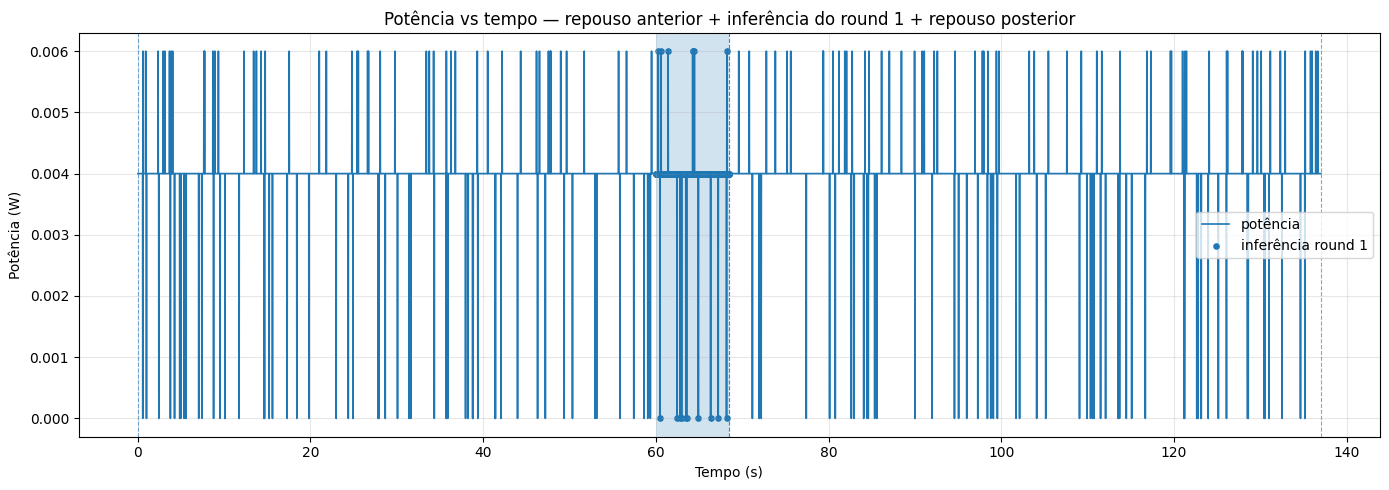

In [2]:
# -*- coding: utf-8 -*-
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILE_PATH = "/home/clariele/Arduino/tinyMLP/EnergiaINA/resuldados_energia_2/tempo_inferencia_tinyMLP_quant.csv"

ROUND_TO_PLOT = 1   # <<< mude aqui: 1, 2, 3, ...


# =========================================================
# LER ARQUIVO
# =========================================================
with open(FILE_PATH, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

header_idx = None
for i, line in enumerate(lines):
    line_clean = line.strip().replace("\t", ",")
    if "tempo_s" in line_clean and "power_W" in line_clean:
        header_idx = i
        break

if header_idx is None:
    raise ValueError("Cabeçalho não encontrado.")

data_lines = ["tempo_s,power_W,inferindo,round,phase,bus_V,current_mA"]
summary_rows = []

for line in lines[header_idx + 1:]:
    line_clean = line.strip()

    if not line_clean:
        continue

    if line_clean.startswith("SUMMARY_HEADER"):
        continue

    if line_clean.startswith("SUMMARY"):
        line_clean = line_clean.replace("\t", ",")
        parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]
        if len(parts) >= 6 and parts[0] == "SUMMARY":
            summary_rows.append(parts[:6])
        continue

    line_clean = line_clean.replace("\t", ",")
    parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]

    if len(parts) >= 7:
        try:
            float(parts[0])      # tempo_s
            float(parts[1])      # power_W
            int(float(parts[2])) # inferindo
            data_lines.append(",".join(parts[:7]))
        except:
            pass

df = pd.read_csv(io.StringIO("\n".join(data_lines)))

for col in ["tempo_s", "power_W", "inferindo", "round", "bus_V", "current_mA"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["tempo_s", "power_W", "round"]).copy()
df["round"] = df["round"].astype(int)
df["inferindo"] = df["inferindo"].fillna(0).astype(int)
df = df.sort_values(["tempo_s"]).reset_index(drop=True)

# =========================================================
# SUMMARY
# =========================================================
if summary_rows:
    df_summary = pd.DataFrame(
        summary_rows,
        columns=["tag", "round", "phase", "reps", "total_us", "avg_us"]
    )
    for col in ["round", "reps", "total_us", "avg_us"]:
        df_summary[col] = pd.to_numeric(df_summary[col], errors="coerce")
    df_summary["duracao_s_summary"] = df_summary["total_us"] / 1e6
else:
    df_summary = pd.DataFrame(columns=["round", "phase", "reps", "total_us", "avg_us", "duracao_s_summary"])


# =========================================================
# DETECTAR INTERVALOS DE INFERÊNCIA GLOBAIS
# =========================================================
def detect_intervals(df_):
    infer = df_["inferindo"].values

    infer_prev = np.r_[0, infer[:-1]]
    infer_next = np.r_[infer[1:], 0]

    starts = np.where((infer == 1) & (infer_prev == 0))[0]
    ends   = np.where((infer == 1) & (infer_next == 0))[0]

    return list(zip(starts, ends))


intervals = detect_intervals(df)

# =========================================================
# TABELA COMPLETA DE TODOS OS ROUNDS
# =========================================================
rows = []

for idx, (i0, i1) in enumerate(intervals, start=1):
    df_seg = df.iloc[i0:i1+1].copy()

    round_vals = df_seg["round"].dropna().unique()
    round_id = int(round_vals[0]) if len(round_vals) > 0 else idx

    ts = df_seg["tempo_s"].values
    ps = df_seg["power_W"].values

    # baseline = média do repouso do mesmo round
    df_round = df[df["round"] == round_id].copy()
    rest_vals = df_round[df_round["inferindo"] == 0]["power_W"].values

    if len(rest_vals) == 0:
        baseline = np.nan
    else:
        baseline = np.mean(rest_vals)

    ps_excess = np.maximum(ps - baseline, 0) if np.isfinite(baseline) else ps
    energia_J = np.trapz(ps_excess, ts)

    # tempo da inferência: prioriza SUMMARY
    dur_summary = np.nan
    tmp = df_summary[df_summary["round"] == round_id]
    if not tmp.empty:
        dur_summary = tmp["duracao_s_summary"].iloc[0]

    dur_series = ts[-1] - ts[0] if len(ts) > 1 else 0.0
    duracao_s = dur_summary if np.isfinite(dur_summary) else dur_series

    rows.append({
        "round": round_id,
        "duracao_s": duracao_s,
        "baseline_W": baseline,
        "energia_J": energia_J,
        "energia_mWh": energia_J / 3600.0 * 1000.0
    })

df_results = pd.DataFrame(rows).sort_values("round").reset_index(drop=True)

print("\nTABELA COMPLETA - TODOS OS ROUNDS\n")
with pd.option_context("display.max_rows", None, "display.float_format", lambda x: f"{x:.6f}"):
    print(df_results.to_string(index=False))

print("\nMÉDIAS GERAIS\n")
print(f"Tempo médio de inferência (s): {df_results['duracao_s'].mean():.6f}")
print(f"Energia média de inferência (J): {df_results['energia_J'].mean():.6f}")
print(f"Energia média de inferência (mWh): {df_results['energia_mWh'].mean():.6f}")


# =========================================================
# GRÁFICO: REPOUSO ANTERIOR + INFERÊNCIA + REPOUSO POSTERIOR
# =========================================================
all_rounds = sorted(df["round"].dropna().unique())

if ROUND_TO_PLOT not in all_rounds:
    raise ValueError(f"Round {ROUND_TO_PLOT} não encontrado.")

prev_round = ROUND_TO_PLOT - 1 if (ROUND_TO_PLOT - 1) in all_rounds else None
next_round = ROUND_TO_PLOT + 1 if (ROUND_TO_PLOT + 1) in all_rounds else None

rounds_for_plot = []
if prev_round is not None:
    rounds_for_plot.append(prev_round)
rounds_for_plot.append(ROUND_TO_PLOT)
if next_round is not None:
    rounds_for_plot.append(next_round)

df_plot = df[df["round"].isin(rounds_for_plot)].copy().sort_values("tempo_s")

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_plot["tempo_s"], df_plot["power_W"], linewidth=1.2, label="potência")

# destacar somente a inferência do round escolhido
df_inf_target = df[(df["round"] == ROUND_TO_PLOT) & (df["inferindo"] == 1)].copy()

if not df_inf_target.empty:
    ax.scatter(
        df_inf_target["tempo_s"],
        df_inf_target["power_W"],
        s=14,
        label=f"inferência round {ROUND_TO_PLOT}"
    )

    t0 = df_inf_target["tempo_s"].min()
    t1 = df_inf_target["tempo_s"].max()
    ax.axvspan(t0, t1, alpha=0.20)

# linhas verticais para separar rounds
for r in rounds_for_plot:
    df_r = df[df["round"] == r]
    if not df_r.empty:
        ax.axvline(df_r["tempo_s"].min(), linestyle="--", linewidth=0.8, alpha=0.6)
        ax.axvline(df_r["tempo_s"].max(), linestyle="--", linewidth=0.8, alpha=0.6)

ax.set_title(
    f"Potência vs tempo — repouso anterior + inferência do round {ROUND_TO_PLOT} + repouso posterior"
)
ax.set_xlabel("Tempo (s)")
ax.set_ylabel("Potência (W)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## PODA 2


TABELA COMPLETA - TODOS OS ROUNDS

 round  duracao_s  baseline_W  energia_J  energia_mWh
     1  21.752675    0.003585   0.005928     0.001647
     2  21.696925    0.003561   0.005994     0.001665
     3  21.804384    0.003562   0.005487     0.001524
     4  21.776962    0.003541   0.006017     0.001671
     5  21.788876    0.003522   0.005798     0.001611
     6  21.789791    0.003533   0.005896     0.001638
     7  21.738012    0.003538   0.005427     0.001508
     8  21.734392    0.003542   0.005612     0.001559
     9  21.744862    0.003554   0.005700     0.001583
    10  21.747541    0.003547   0.005498     0.001527

MÉDIAS GERAIS

Tempo médio de inferência (s): 21.757442
Energia média de inferência (J): 0.005736
Energia média de inferência (mWh): 0.001593


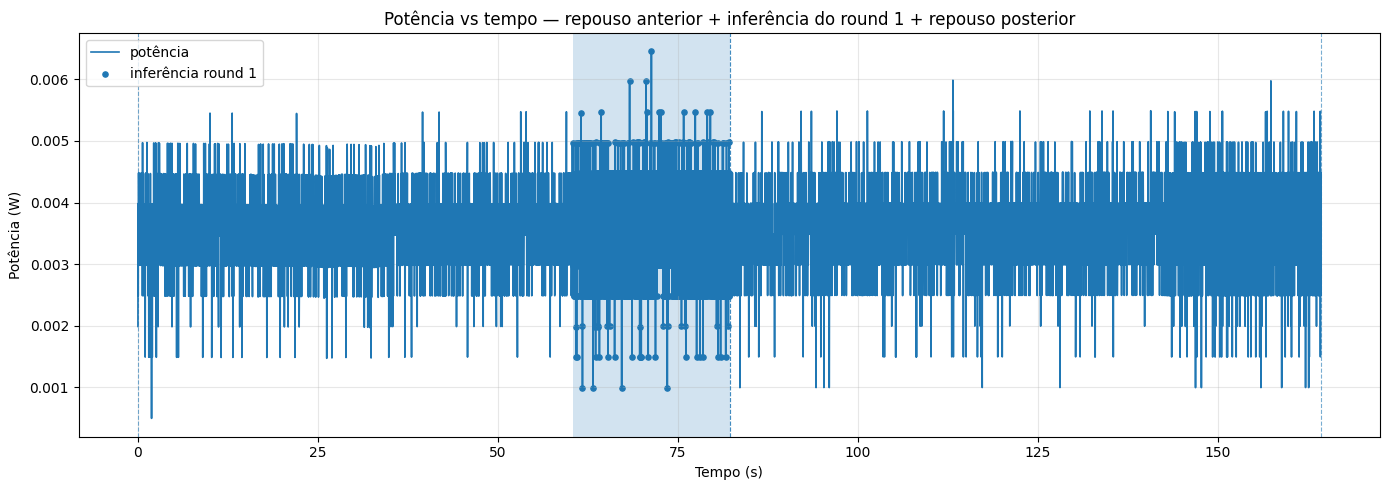

In [4]:
# -*- coding: utf-8 -*-
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILE_PATH = "/home/clariele/Arduino/tinyMLP/EnergiaINA/resuldados_energia_2/tempo_inferencia_tinyMLP_poda.csv"

ROUND_TO_PLOT = 1   # <<< mude aqui: 1, 2, 3, ...


# =========================================================
# LER ARQUIVO
# =========================================================
with open(FILE_PATH, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

header_idx = None
for i, line in enumerate(lines):
    line_clean = line.strip().replace("\t", ",")
    if "tempo_s" in line_clean and "power_W" in line_clean:
        header_idx = i
        break

if header_idx is None:
    raise ValueError("Cabeçalho não encontrado.")

data_lines = ["tempo_s,power_W,inferindo,round,phase,bus_V,current_mA"]
summary_rows = []

for line in lines[header_idx + 1:]:
    line_clean = line.strip()

    if not line_clean:
        continue

    if line_clean.startswith("SUMMARY_HEADER"):
        continue

    if line_clean.startswith("SUMMARY"):
        line_clean = line_clean.replace("\t", ",")
        parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]
        if len(parts) >= 6 and parts[0] == "SUMMARY":
            summary_rows.append(parts[:6])
        continue

    line_clean = line_clean.replace("\t", ",")
    parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]

    if len(parts) >= 7:
        try:
            float(parts[0])      # tempo_s
            float(parts[1])      # power_W
            int(float(parts[2])) # inferindo
            data_lines.append(",".join(parts[:7]))
        except:
            pass

df = pd.read_csv(io.StringIO("\n".join(data_lines)))

for col in ["tempo_s", "power_W", "inferindo", "round", "bus_V", "current_mA"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["tempo_s", "power_W", "round"]).copy()
df["round"] = df["round"].astype(int)
df["inferindo"] = df["inferindo"].fillna(0).astype(int)
df = df.sort_values(["tempo_s"]).reset_index(drop=True)

# =========================================================
# SUMMARY
# =========================================================
if summary_rows:
    df_summary = pd.DataFrame(
        summary_rows,
        columns=["tag", "round", "phase", "reps", "total_us", "avg_us"]
    )
    for col in ["round", "reps", "total_us", "avg_us"]:
        df_summary[col] = pd.to_numeric(df_summary[col], errors="coerce")
    df_summary["duracao_s_summary"] = df_summary["total_us"] / 1e6
else:
    df_summary = pd.DataFrame(columns=["round", "phase", "reps", "total_us", "avg_us", "duracao_s_summary"])


# =========================================================
# DETECTAR INTERVALOS DE INFERÊNCIA GLOBAIS
# =========================================================
def detect_intervals(df_):
    infer = df_["inferindo"].values

    infer_prev = np.r_[0, infer[:-1]]
    infer_next = np.r_[infer[1:], 0]

    starts = np.where((infer == 1) & (infer_prev == 0))[0]
    ends   = np.where((infer == 1) & (infer_next == 0))[0]

    return list(zip(starts, ends))


intervals = detect_intervals(df)

# =========================================================
# TABELA COMPLETA DE TODOS OS ROUNDS
# =========================================================
rows = []

for idx, (i0, i1) in enumerate(intervals, start=1):
    df_seg = df.iloc[i0:i1+1].copy()

    round_vals = df_seg["round"].dropna().unique()
    round_id = int(round_vals[0]) if len(round_vals) > 0 else idx

    ts = df_seg["tempo_s"].values
    ps = df_seg["power_W"].values

    # baseline = média do repouso do mesmo round
    df_round = df[df["round"] == round_id].copy()
    rest_vals = df_round[df_round["inferindo"] == 0]["power_W"].values

    if len(rest_vals) == 0:
        baseline = np.nan
    else:
        baseline = np.mean(rest_vals)

    ps_excess = np.maximum(ps - baseline, 0) if np.isfinite(baseline) else ps
    energia_J = np.trapz(ps_excess, ts)

    # tempo da inferência: prioriza SUMMARY
    dur_summary = np.nan
    tmp = df_summary[df_summary["round"] == round_id]
    if not tmp.empty:
        dur_summary = tmp["duracao_s_summary"].iloc[0]

    dur_series = ts[-1] - ts[0] if len(ts) > 1 else 0.0
    duracao_s = dur_summary if np.isfinite(dur_summary) else dur_series

    rows.append({
        "round": round_id,
        "duracao_s": duracao_s,
        "baseline_W": baseline,
        "energia_J": energia_J,
        "energia_mWh": energia_J / 3600.0 * 1000.0
    })

df_results = pd.DataFrame(rows).sort_values("round").reset_index(drop=True)

print("\nTABELA COMPLETA - TODOS OS ROUNDS\n")
with pd.option_context("display.max_rows", None, "display.float_format", lambda x: f"{x:.6f}"):
    print(df_results.to_string(index=False))

print("\nMÉDIAS GERAIS\n")
print(f"Tempo médio de inferência (s): {df_results['duracao_s'].mean():.6f}")
print(f"Energia média de inferência (J): {df_results['energia_J'].mean():.6f}")
print(f"Energia média de inferência (mWh): {df_results['energia_mWh'].mean():.6f}")


# =========================================================
# GRÁFICO: REPOUSO ANTERIOR + INFERÊNCIA + REPOUSO POSTERIOR
# =========================================================
all_rounds = sorted(df["round"].dropna().unique())

if ROUND_TO_PLOT not in all_rounds:
    raise ValueError(f"Round {ROUND_TO_PLOT} não encontrado.")

prev_round = ROUND_TO_PLOT - 1 if (ROUND_TO_PLOT - 1) in all_rounds else None
next_round = ROUND_TO_PLOT + 1 if (ROUND_TO_PLOT + 1) in all_rounds else None

rounds_for_plot = []
if prev_round is not None:
    rounds_for_plot.append(prev_round)
rounds_for_plot.append(ROUND_TO_PLOT)
if next_round is not None:
    rounds_for_plot.append(next_round)

df_plot = df[df["round"].isin(rounds_for_plot)].copy().sort_values("tempo_s")

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_plot["tempo_s"], df_plot["power_W"], linewidth=1.2, label="potência")

# destacar somente a inferência do round escolhido
df_inf_target = df[(df["round"] == ROUND_TO_PLOT) & (df["inferindo"] == 1)].copy()

if not df_inf_target.empty:
    ax.scatter(
        df_inf_target["tempo_s"],
        df_inf_target["power_W"],
        s=14,
        label=f"inferência round {ROUND_TO_PLOT}"
    )

    t0 = df_inf_target["tempo_s"].min()
    t1 = df_inf_target["tempo_s"].max()
    ax.axvspan(t0, t1, alpha=0.20)

# linhas verticais para separar rounds
for r in rounds_for_plot:
    df_r = df[df["round"] == r]
    if not df_r.empty:
        ax.axvline(df_r["tempo_s"].min(), linestyle="--", linewidth=0.8, alpha=0.6)
        ax.axvline(df_r["tempo_s"].max(), linestyle="--", linewidth=0.8, alpha=0.6)

ax.set_title(
    f"Potência vs tempo — repouso anterior + inferência do round {ROUND_TO_PLOT} + repouso posterior"
)
ax.set_xlabel("Tempo (s)")
ax.set_ylabel("Potência (W)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## KD STUDENT 2


TABELA COMPLETA - TODOS OS ROUNDS

 round  duracao_s  baseline_W  energia_J  energia_mWh
     1  21.719537    0.003533   0.005590     0.001553
     2  21.721595    0.003542   0.005858     0.001627
     3  21.751329    0.003536   0.005339     0.001483
     4  21.749169    0.003531   0.005794     0.001609
     5  21.726445    0.003550   0.005716     0.001588
     6  21.733899    0.003522   0.005577     0.001549
     7  21.736490    0.003541   0.005323     0.001479
     8  21.709976    0.003510   0.005941     0.001650
     9  21.696749    0.003526   0.005764     0.001601
    10  21.690680    0.003526   0.005442     0.001512

MÉDIAS GERAIS

Tempo médio de inferência (s): 21.723587
Energia média de inferência (J): 0.005635
Energia média de inferência (mWh): 0.001565


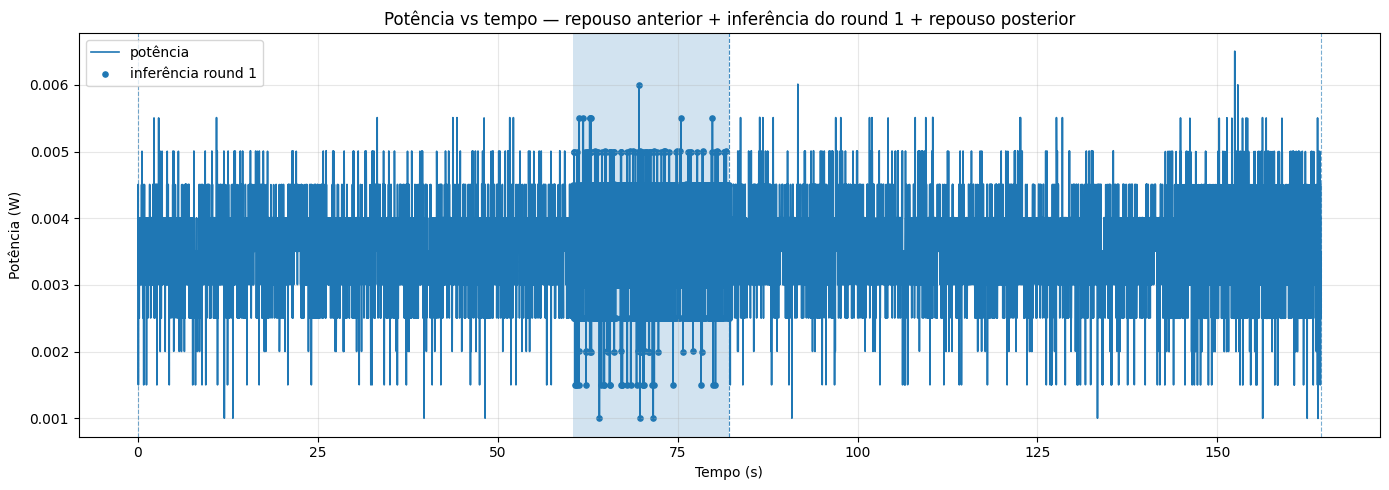

In [8]:
# -*- coding: utf-8 -*-
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILE_PATH = "/home/clariele/Arduino/tinyMLP/EnergiaINA/resuldados_energia_2/tempo_inferencia_tinyMLP_kd_student.csv"

ROUND_TO_PLOT = 1   # <<< mude aqui: 1, 2, 3, ...


# =========================================================
# LER ARQUIVO
# =========================================================
with open(FILE_PATH, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

header_idx = None
for i, line in enumerate(lines):
    line_clean = line.strip().replace("\t", ",")
    if "tempo_s" in line_clean and "power_W" in line_clean:
        header_idx = i
        break

if header_idx is None:
    raise ValueError("Cabeçalho não encontrado.")

data_lines = ["tempo_s,power_W,inferindo,round,phase,bus_V,current_mA"]
summary_rows = []

for line in lines[header_idx + 1:]:
    line_clean = line.strip()

    if not line_clean:
        continue

    if line_clean.startswith("SUMMARY_HEADER"):
        continue

    if line_clean.startswith("SUMMARY"):
        line_clean = line_clean.replace("\t", ",")
        parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]
        if len(parts) >= 6 and parts[0] == "SUMMARY":
            summary_rows.append(parts[:6])
        continue

    line_clean = line_clean.replace("\t", ",")
    parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]

    if len(parts) >= 7:
        try:
            float(parts[0])      # tempo_s
            float(parts[1])      # power_W
            int(float(parts[2])) # inferindo
            data_lines.append(",".join(parts[:7]))
        except:
            pass

df = pd.read_csv(io.StringIO("\n".join(data_lines)))

for col in ["tempo_s", "power_W", "inferindo", "round", "bus_V", "current_mA"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["tempo_s", "power_W", "round"]).copy()
df["round"] = df["round"].astype(int)
df["inferindo"] = df["inferindo"].fillna(0).astype(int)
df = df.sort_values(["tempo_s"]).reset_index(drop=True)

# =========================================================
# SUMMARY
# =========================================================
if summary_rows:
    df_summary = pd.DataFrame(
        summary_rows,
        columns=["tag", "round", "phase", "reps", "total_us", "avg_us"]
    )
    for col in ["round", "reps", "total_us", "avg_us"]:
        df_summary[col] = pd.to_numeric(df_summary[col], errors="coerce")
    df_summary["duracao_s_summary"] = df_summary["total_us"] / 1e6
else:
    df_summary = pd.DataFrame(columns=["round", "phase", "reps", "total_us", "avg_us", "duracao_s_summary"])


# =========================================================
# DETECTAR INTERVALOS DE INFERÊNCIA GLOBAIS
# =========================================================
def detect_intervals(df_):
    infer = df_["inferindo"].values

    infer_prev = np.r_[0, infer[:-1]]
    infer_next = np.r_[infer[1:], 0]

    starts = np.where((infer == 1) & (infer_prev == 0))[0]
    ends   = np.where((infer == 1) & (infer_next == 0))[0]

    return list(zip(starts, ends))


intervals = detect_intervals(df)

# =========================================================
# TABELA COMPLETA DE TODOS OS ROUNDS
# =========================================================
rows = []

for idx, (i0, i1) in enumerate(intervals, start=1):
    df_seg = df.iloc[i0:i1+1].copy()

    round_vals = df_seg["round"].dropna().unique()
    round_id = int(round_vals[0]) if len(round_vals) > 0 else idx

    ts = df_seg["tempo_s"].values
    ps = df_seg["power_W"].values

    # baseline = média do repouso do mesmo round
    df_round = df[df["round"] == round_id].copy()
    rest_vals = df_round[df_round["inferindo"] == 0]["power_W"].values

    if len(rest_vals) == 0:
        baseline = np.nan
    else:
        baseline = np.mean(rest_vals)

    ps_excess = np.maximum(ps - baseline, 0) if np.isfinite(baseline) else ps
    energia_J = np.trapz(ps_excess, ts)

    # tempo da inferência: prioriza SUMMARY
    dur_summary = np.nan
    tmp = df_summary[df_summary["round"] == round_id]
    if not tmp.empty:
        dur_summary = tmp["duracao_s_summary"].iloc[0]

    dur_series = ts[-1] - ts[0] if len(ts) > 1 else 0.0
    duracao_s = dur_summary if np.isfinite(dur_summary) else dur_series

    rows.append({
        "round": round_id,
        "duracao_s": duracao_s,
        "baseline_W": baseline,
        "energia_J": energia_J,
        "energia_mWh": energia_J / 3600.0 * 1000.0
    })

df_results = pd.DataFrame(rows).sort_values("round").reset_index(drop=True)

print("\nTABELA COMPLETA - TODOS OS ROUNDS\n")
with pd.option_context("display.max_rows", None, "display.float_format", lambda x: f"{x:.6f}"):
    print(df_results.to_string(index=False))

print("\nMÉDIAS GERAIS\n")
print(f"Tempo médio de inferência (s): {df_results['duracao_s'].mean():.6f}")
print(f"Energia média de inferência (J): {df_results['energia_J'].mean():.6f}")
print(f"Energia média de inferência (mWh): {df_results['energia_mWh'].mean():.6f}")


# =========================================================
# GRÁFICO: REPOUSO ANTERIOR + INFERÊNCIA + REPOUSO POSTERIOR
# =========================================================
all_rounds = sorted(df["round"].dropna().unique())

if ROUND_TO_PLOT not in all_rounds:
    raise ValueError(f"Round {ROUND_TO_PLOT} não encontrado.")

prev_round = ROUND_TO_PLOT - 1 if (ROUND_TO_PLOT - 1) in all_rounds else None
next_round = ROUND_TO_PLOT + 1 if (ROUND_TO_PLOT + 1) in all_rounds else None

rounds_for_plot = []
if prev_round is not None:
    rounds_for_plot.append(prev_round)
rounds_for_plot.append(ROUND_TO_PLOT)
if next_round is not None:
    rounds_for_plot.append(next_round)

df_plot = df[df["round"].isin(rounds_for_plot)].copy().sort_values("tempo_s")

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_plot["tempo_s"], df_plot["power_W"], linewidth=1.2, label="potência")

# destacar somente a inferência do round escolhido
df_inf_target = df[(df["round"] == ROUND_TO_PLOT) & (df["inferindo"] == 1)].copy()

if not df_inf_target.empty:
    ax.scatter(
        df_inf_target["tempo_s"],
        df_inf_target["power_W"],
        s=14,
        label=f"inferência round {ROUND_TO_PLOT}"
    )

    t0 = df_inf_target["tempo_s"].min()
    t1 = df_inf_target["tempo_s"].max()
    ax.axvspan(t0, t1, alpha=0.20)

# linhas verticais para separar rounds
for r in rounds_for_plot:
    df_r = df[df["round"] == r]
    if not df_r.empty:
        ax.axvline(df_r["tempo_s"].min(), linestyle="--", linewidth=0.8, alpha=0.6)
        ax.axvline(df_r["tempo_s"].max(), linestyle="--", linewidth=0.8, alpha=0.6)

ax.set_title(
    f"Potência vs tempo — repouso anterior + inferência do round {ROUND_TO_PLOT} + repouso posterior"
)
ax.set_xlabel("Tempo (s)")
ax.set_ylabel("Potência (W)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## KD TEACHER 2


TABELA COMPLETA - TODOS OS ROUNDS

 round  duracao_s  baseline_W  energia_J  energia_mWh
     1  24.994011    0.003542   0.006813     0.001892
     2  25.027754    0.003544   0.005985     0.001662
     3  25.007686    0.003526   0.006496     0.001804
     4  25.021782    0.003512   0.006246     0.001735
     5  25.008424    0.003498   0.006956     0.001932
     6  25.036265    0.003511   0.006876     0.001910
     7  25.060366    0.003518   0.006447     0.001791
     8  25.074746    0.003532   0.007100     0.001972
     9  25.052748    0.003550   0.006652     0.001848
    10  25.058608    0.003518   0.006449     0.001791

MÉDIAS GERAIS

Tempo médio de inferência (s): 25.034239
Energia média de inferência (J): 0.006602
Energia média de inferência (mWh): 0.001834


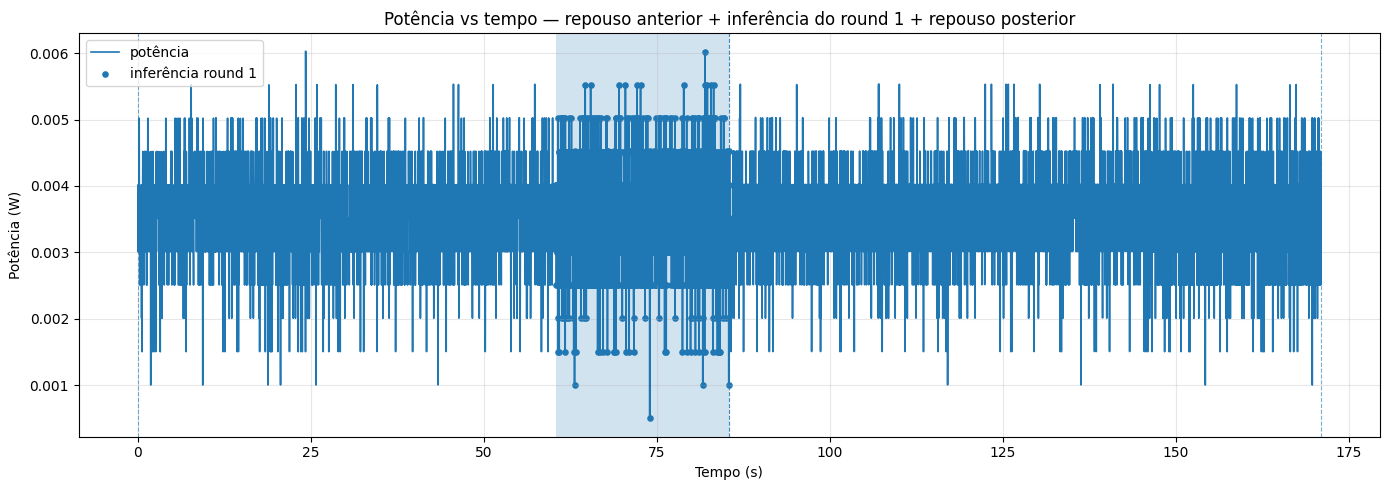

In [9]:
# -*- coding: utf-8 -*-
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILE_PATH = "/home/clariele/Arduino/tinyMLP/EnergiaINA/resuldados_energia_2/tempo_inferencia_tinyMLP_kd_teacher.csv"

ROUND_TO_PLOT = 1   # <<< mude aqui: 1, 2, 3, ...


# =========================================================
# LER ARQUIVO
# =========================================================
with open(FILE_PATH, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

header_idx = None
for i, line in enumerate(lines):
    line_clean = line.strip().replace("\t", ",")
    if "tempo_s" in line_clean and "power_W" in line_clean:
        header_idx = i
        break

if header_idx is None:
    raise ValueError("Cabeçalho não encontrado.")

data_lines = ["tempo_s,power_W,inferindo,round,phase,bus_V,current_mA"]
summary_rows = []

for line in lines[header_idx + 1:]:
    line_clean = line.strip()

    if not line_clean:
        continue

    if line_clean.startswith("SUMMARY_HEADER"):
        continue

    if line_clean.startswith("SUMMARY"):
        line_clean = line_clean.replace("\t", ",")
        parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]
        if len(parts) >= 6 and parts[0] == "SUMMARY":
            summary_rows.append(parts[:6])
        continue

    line_clean = line_clean.replace("\t", ",")
    parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]

    if len(parts) >= 7:
        try:
            float(parts[0])      # tempo_s
            float(parts[1])      # power_W
            int(float(parts[2])) # inferindo
            data_lines.append(",".join(parts[:7]))
        except:
            pass

df = pd.read_csv(io.StringIO("\n".join(data_lines)))

for col in ["tempo_s", "power_W", "inferindo", "round", "bus_V", "current_mA"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["tempo_s", "power_W", "round"]).copy()
df["round"] = df["round"].astype(int)
df["inferindo"] = df["inferindo"].fillna(0).astype(int)
df = df.sort_values(["tempo_s"]).reset_index(drop=True)

# =========================================================
# SUMMARY
# =========================================================
if summary_rows:
    df_summary = pd.DataFrame(
        summary_rows,
        columns=["tag", "round", "phase", "reps", "total_us", "avg_us"]
    )
    for col in ["round", "reps", "total_us", "avg_us"]:
        df_summary[col] = pd.to_numeric(df_summary[col], errors="coerce")
    df_summary["duracao_s_summary"] = df_summary["total_us"] / 1e6
else:
    df_summary = pd.DataFrame(columns=["round", "phase", "reps", "total_us", "avg_us", "duracao_s_summary"])


# =========================================================
# DETECTAR INTERVALOS DE INFERÊNCIA GLOBAIS
# =========================================================
def detect_intervals(df_):
    infer = df_["inferindo"].values

    infer_prev = np.r_[0, infer[:-1]]
    infer_next = np.r_[infer[1:], 0]

    starts = np.where((infer == 1) & (infer_prev == 0))[0]
    ends   = np.where((infer == 1) & (infer_next == 0))[0]

    return list(zip(starts, ends))


intervals = detect_intervals(df)

# =========================================================
# TABELA COMPLETA DE TODOS OS ROUNDS
# =========================================================
rows = []

for idx, (i0, i1) in enumerate(intervals, start=1):
    df_seg = df.iloc[i0:i1+1].copy()

    round_vals = df_seg["round"].dropna().unique()
    round_id = int(round_vals[0]) if len(round_vals) > 0 else idx

    ts = df_seg["tempo_s"].values
    ps = df_seg["power_W"].values

    # baseline = média do repouso do mesmo round
    df_round = df[df["round"] == round_id].copy()
    rest_vals = df_round[df_round["inferindo"] == 0]["power_W"].values

    if len(rest_vals) == 0:
        baseline = np.nan
    else:
        baseline = np.mean(rest_vals)

    ps_excess = np.maximum(ps - baseline, 0) if np.isfinite(baseline) else ps
    energia_J = np.trapz(ps_excess, ts)

    # tempo da inferência: prioriza SUMMARY
    dur_summary = np.nan
    tmp = df_summary[df_summary["round"] == round_id]
    if not tmp.empty:
        dur_summary = tmp["duracao_s_summary"].iloc[0]

    dur_series = ts[-1] - ts[0] if len(ts) > 1 else 0.0
    duracao_s = dur_summary if np.isfinite(dur_summary) else dur_series

    rows.append({
        "round": round_id,
        "duracao_s": duracao_s,
        "baseline_W": baseline,
        "energia_J": energia_J,
        "energia_mWh": energia_J / 3600.0 * 1000.0
    })

df_results = pd.DataFrame(rows).sort_values("round").reset_index(drop=True)

print("\nTABELA COMPLETA - TODOS OS ROUNDS\n")
with pd.option_context("display.max_rows", None, "display.float_format", lambda x: f"{x:.6f}"):
    print(df_results.to_string(index=False))

print("\nMÉDIAS GERAIS\n")
print(f"Tempo médio de inferência (s): {df_results['duracao_s'].mean():.6f}")
print(f"Energia média de inferência (J): {df_results['energia_J'].mean():.6f}")
print(f"Energia média de inferência (mWh): {df_results['energia_mWh'].mean():.6f}")


# =========================================================
# GRÁFICO: REPOUSO ANTERIOR + INFERÊNCIA + REPOUSO POSTERIOR
# =========================================================
all_rounds = sorted(df["round"].dropna().unique())

if ROUND_TO_PLOT not in all_rounds:
    raise ValueError(f"Round {ROUND_TO_PLOT} não encontrado.")

prev_round = ROUND_TO_PLOT - 1 if (ROUND_TO_PLOT - 1) in all_rounds else None
next_round = ROUND_TO_PLOT + 1 if (ROUND_TO_PLOT + 1) in all_rounds else None

rounds_for_plot = []
if prev_round is not None:
    rounds_for_plot.append(prev_round)
rounds_for_plot.append(ROUND_TO_PLOT)
if next_round is not None:
    rounds_for_plot.append(next_round)

df_plot = df[df["round"].isin(rounds_for_plot)].copy().sort_values("tempo_s")

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_plot["tempo_s"], df_plot["power_W"], linewidth=1.2, label="potência")

# destacar somente a inferência do round escolhido
df_inf_target = df[(df["round"] == ROUND_TO_PLOT) & (df["inferindo"] == 1)].copy()

if not df_inf_target.empty:
    ax.scatter(
        df_inf_target["tempo_s"],
        df_inf_target["power_W"],
        s=14,
        label=f"inferência round {ROUND_TO_PLOT}"
    )

    t0 = df_inf_target["tempo_s"].min()
    t1 = df_inf_target["tempo_s"].max()
    ax.axvspan(t0, t1, alpha=0.20)

# linhas verticais para separar rounds
for r in rounds_for_plot:
    df_r = df[df["round"] == r]
    if not df_r.empty:
        ax.axvline(df_r["tempo_s"].min(), linestyle="--", linewidth=0.8, alpha=0.6)
        ax.axvline(df_r["tempo_s"].max(), linestyle="--", linewidth=0.8, alpha=0.6)

ax.set_title(
    f"Potência vs tempo — repouso anterior + inferência do round {ROUND_TO_PLOT} + repouso posterior"
)
ax.set_xlabel("Tempo (s)")
ax.set_ylabel("Potência (W)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## KD STUDENT QUANT 2


TABELA COMPLETA - TODOS OS ROUNDS

 round  duracao_s  baseline_W  energia_J  energia_mWh
     1  20.433469    0.003597   0.005693     0.001582
     2  20.452327    0.003604   0.005021     0.001395
     3  20.438255    0.003614   0.005190     0.001442
     4  20.427466    0.003623   0.005055     0.001404
     5  20.380207    0.003592   0.005927     0.001646
     6  20.417642    0.003598   0.004971     0.001381
     7  20.433599    0.003614   0.005609     0.001558
     8  20.476354    0.003587   0.005295     0.001471
     9  20.492614    0.003577   0.005330     0.001481
    10  20.482226    0.003589   0.005009     0.001391

MÉDIAS GERAIS

Tempo médio de inferência (s): 20.443416
Energia média de inferência (J): 0.005310
Energia média de inferência (mWh): 0.001475


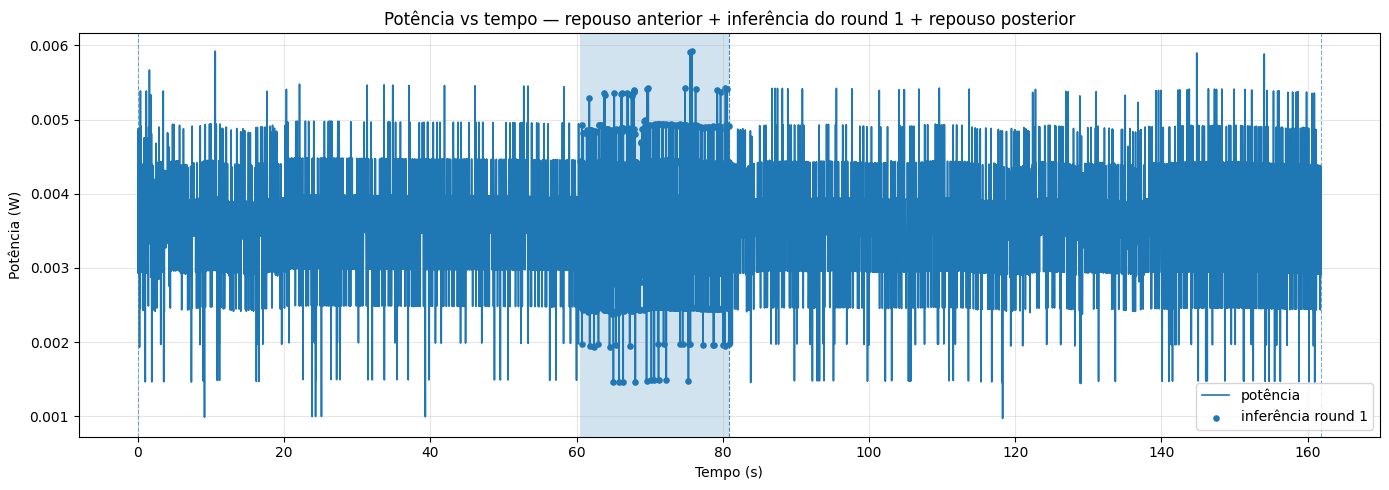

In [10]:
# -*- coding: utf-8 -*-
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILE_PATH = "/home/clariele/Arduino/tinyMLP/EnergiaINA/resuldados_energia_2/tempo_inferencia_tinyMLP_kd_student_quant.csv"

ROUND_TO_PLOT = 1   # <<< mude aqui: 1, 2, 3, ...


# =========================================================
# LER ARQUIVO
# =========================================================
with open(FILE_PATH, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

header_idx = None
for i, line in enumerate(lines):
    line_clean = line.strip().replace("\t", ",")
    if "tempo_s" in line_clean and "power_W" in line_clean:
        header_idx = i
        break

if header_idx is None:
    raise ValueError("Cabeçalho não encontrado.")

data_lines = ["tempo_s,power_W,inferindo,round,phase,bus_V,current_mA"]
summary_rows = []

for line in lines[header_idx + 1:]:
    line_clean = line.strip()

    if not line_clean:
        continue

    if line_clean.startswith("SUMMARY_HEADER"):
        continue

    if line_clean.startswith("SUMMARY"):
        line_clean = line_clean.replace("\t", ",")
        parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]
        if len(parts) >= 6 and parts[0] == "SUMMARY":
            summary_rows.append(parts[:6])
        continue

    line_clean = line_clean.replace("\t", ",")
    parts = [p.strip() for p in line_clean.split(",") if p.strip() != ""]

    if len(parts) >= 7:
        try:
            float(parts[0])      # tempo_s
            float(parts[1])      # power_W
            int(float(parts[2])) # inferindo
            data_lines.append(",".join(parts[:7]))
        except:
            pass

df = pd.read_csv(io.StringIO("\n".join(data_lines)))

for col in ["tempo_s", "power_W", "inferindo", "round", "bus_V", "current_mA"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["tempo_s", "power_W", "round"]).copy()
df["round"] = df["round"].astype(int)
df["inferindo"] = df["inferindo"].fillna(0).astype(int)
df = df.sort_values(["tempo_s"]).reset_index(drop=True)

# =========================================================
# SUMMARY
# =========================================================
if summary_rows:
    df_summary = pd.DataFrame(
        summary_rows,
        columns=["tag", "round", "phase", "reps", "total_us", "avg_us"]
    )
    for col in ["round", "reps", "total_us", "avg_us"]:
        df_summary[col] = pd.to_numeric(df_summary[col], errors="coerce")
    df_summary["duracao_s_summary"] = df_summary["total_us"] / 1e6
else:
    df_summary = pd.DataFrame(columns=["round", "phase", "reps", "total_us", "avg_us", "duracao_s_summary"])


# =========================================================
# DETECTAR INTERVALOS DE INFERÊNCIA GLOBAIS
# =========================================================
def detect_intervals(df_):
    infer = df_["inferindo"].values

    infer_prev = np.r_[0, infer[:-1]]
    infer_next = np.r_[infer[1:], 0]

    starts = np.where((infer == 1) & (infer_prev == 0))[0]
    ends   = np.where((infer == 1) & (infer_next == 0))[0]

    return list(zip(starts, ends))


intervals = detect_intervals(df)

# =========================================================
# TABELA COMPLETA DE TODOS OS ROUNDS
# =========================================================
rows = []

for idx, (i0, i1) in enumerate(intervals, start=1):
    df_seg = df.iloc[i0:i1+1].copy()

    round_vals = df_seg["round"].dropna().unique()
    round_id = int(round_vals[0]) if len(round_vals) > 0 else idx

    ts = df_seg["tempo_s"].values
    ps = df_seg["power_W"].values

    # baseline = média do repouso do mesmo round
    df_round = df[df["round"] == round_id].copy()
    rest_vals = df_round[df_round["inferindo"] == 0]["power_W"].values

    if len(rest_vals) == 0:
        baseline = np.nan
    else:
        baseline = np.mean(rest_vals)

    ps_excess = np.maximum(ps - baseline, 0) if np.isfinite(baseline) else ps
    energia_J = np.trapz(ps_excess, ts)

    # tempo da inferência: prioriza SUMMARY
    dur_summary = np.nan
    tmp = df_summary[df_summary["round"] == round_id]
    if not tmp.empty:
        dur_summary = tmp["duracao_s_summary"].iloc[0]

    dur_series = ts[-1] - ts[0] if len(ts) > 1 else 0.0
    duracao_s = dur_summary if np.isfinite(dur_summary) else dur_series

    rows.append({
        "round": round_id,
        "duracao_s": duracao_s,
        "baseline_W": baseline,
        "energia_J": energia_J,
        "energia_mWh": energia_J / 3600.0 * 1000.0
    })

df_results = pd.DataFrame(rows).sort_values("round").reset_index(drop=True)

print("\nTABELA COMPLETA - TODOS OS ROUNDS\n")
with pd.option_context("display.max_rows", None, "display.float_format", lambda x: f"{x:.6f}"):
    print(df_results.to_string(index=False))

print("\nMÉDIAS GERAIS\n")
print(f"Tempo médio de inferência (s): {df_results['duracao_s'].mean():.6f}")
print(f"Energia média de inferência (J): {df_results['energia_J'].mean():.6f}")
print(f"Energia média de inferência (mWh): {df_results['energia_mWh'].mean():.6f}")


# =========================================================
# GRÁFICO: REPOUSO ANTERIOR + INFERÊNCIA + REPOUSO POSTERIOR
# =========================================================
all_rounds = sorted(df["round"].dropna().unique())

if ROUND_TO_PLOT not in all_rounds:
    raise ValueError(f"Round {ROUND_TO_PLOT} não encontrado.")

prev_round = ROUND_TO_PLOT - 1 if (ROUND_TO_PLOT - 1) in all_rounds else None
next_round = ROUND_TO_PLOT + 1 if (ROUND_TO_PLOT + 1) in all_rounds else None

rounds_for_plot = []
if prev_round is not None:
    rounds_for_plot.append(prev_round)
rounds_for_plot.append(ROUND_TO_PLOT)
if next_round is not None:
    rounds_for_plot.append(next_round)

df_plot = df[df["round"].isin(rounds_for_plot)].copy().sort_values("tempo_s")

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_plot["tempo_s"], df_plot["power_W"], linewidth=1.2, label="potência")

# destacar somente a inferência do round escolhido
df_inf_target = df[(df["round"] == ROUND_TO_PLOT) & (df["inferindo"] == 1)].copy()

if not df_inf_target.empty:
    ax.scatter(
        df_inf_target["tempo_s"],
        df_inf_target["power_W"],
        s=14,
        label=f"inferência round {ROUND_TO_PLOT}"
    )

    t0 = df_inf_target["tempo_s"].min()
    t1 = df_inf_target["tempo_s"].max()
    ax.axvspan(t0, t1, alpha=0.20)

# linhas verticais para separar rounds
for r in rounds_for_plot:
    df_r = df[df["round"] == r]
    if not df_r.empty:
        ax.axvline(df_r["tempo_s"].min(), linestyle="--", linewidth=0.8, alpha=0.6)
        ax.axvline(df_r["tempo_s"].max(), linestyle="--", linewidth=0.8, alpha=0.6)

ax.set_title(
    f"Potência vs tempo — repouso anterior + inferência do round {ROUND_TO_PLOT} + repouso posterior"
)
ax.set_xlabel("Tempo (s)")
ax.set_ylabel("Potência (W)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()